In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

## Mass Difference Regime

In [9]:
# Visualization Styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# --- FILE PATHS (UPDATE THESE) ---
# 1. The Ground Truth Data
TRAIN_PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train.feather" # Update if filename differs
TEST_PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
VAL_PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_val.feather"
VAL_OUTPUT_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/irm/stratified_binary_07_dataset_val_irm.feather"
TEST_OUTPUT_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/irm/stratified_binary_07_dataset_test_irm.feather"

# 2. The Lookup Table (Metadata)
SPEC_META_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
MOL_META_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"

# 3. Your Model Predictions
TEST_RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/vicreg/prev/results_stratified_binary_07_dataset_test.csv"

In [10]:
def load_and_enrich_data(pairs_path, spec_meta_df):
    """
    Loads pairs, merges with metadata to get precursor masses, 
    and calculates mass difference.
    """
    print(f"Loading pairs from: {pairs_path}")
    df_pairs = pd.read_feather(pairs_path)
    
    # Merge to get Precursor Mass for Molecule A (name_main)
    # We only bring in 'spec_id' and 'prec_mz' to keep it fast
    print("Merging metadata for Molecule A...")
    df_enriched = df_pairs.merge(
        spec_meta_df[['spec_id', 'prec_mz']], 
        left_on='name_main', 
        right_on='spec_id', 
        how='left'
    ).rename(columns={'prec_mz': 'prec_mz_main'}).drop(columns=['spec_id'])
    
    # Merge to get Precursor Mass for Molecule B (name_sub)
    print("Merging metadata for Molecule B...")
    df_enriched = df_enriched.merge(
        spec_meta_df[['spec_id', 'prec_mz']], 
        left_on='name_sub', 
        right_on='spec_id', 
        how='left'
    ).rename(columns={'prec_mz': 'prec_mz_sub'}).drop(columns=['spec_id'])
    
    # Calculate Absolute Mass Difference
    df_enriched['mass_difference'] = (df_enriched['prec_mz_main'] - df_enriched['prec_mz_sub']).abs()
    
    # Safety Check for missing masses
    missing = df_enriched['mass_difference'].isna().sum()
    if missing > 0:
        print(f"WARNING: {missing} records are missing precursor mass info.")
        
    return df_enriched

In [11]:
# --- EXECUTION ---
# 1. Load the big Spec Metadata ONCE
print("Loading Spec Metadata (this might take a few seconds)...")
df_spec_meta = pd.read_pickle(SPEC_META_PATH)

# 2. Enrich Training Data (For Ground Truth Distribution)
df_train_enriched = load_and_enrich_data(TRAIN_PAIRS_PATH, df_spec_meta)

# 3. Enrich Test Data (For Model Evaluation)
df_test_enriched = load_and_enrich_data(TEST_PAIRS_PATH, df_spec_meta)

# 4. Enrich Val Data
df_val_enriched = load_and_enrich_data(VAL_PAIRS_PATH, df_spec_meta)

# 4. Load Predictions and merge with Test Data
print("Loading Model Predictions...")
df_preds = pd.read_csv(TEST_RESULTS_PATH)

Loading Spec Metadata (this might take a few seconds)...
Loading pairs from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train.feather
Merging metadata for Molecule A...
Merging metadata for Molecule B...
Loading pairs from: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather
Merging metadata for Molecule A...
Merging metadata for Molecule B...


ValueError: Columns must be same length as key

In [6]:
df_train_enriched.to_feather("/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train_enriched.feather")

In [7]:
df_test_enriched.to_feather("/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather")

In [108]:
df_val_enriched.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,prec_mz_main,prec_mz_sub,mass_difference
0,MassSpecGymID0215812,MassSpecGymID0216866,0.216216,0.000000,0.0,385.175800,331.144100,54.031700
1,MassSpecGymID0128595,MassSpecGymID0176777,0.545455,0.870965,1.0,228.097687,324.059041,95.961354
2,MassSpecGymID0038198,MassSpecGymID0118858,0.077778,0.000000,0.0,308.152400,595.165747,287.013347
3,MassSpecGymID0216002,MassSpecGymID0216178,0.813559,0.951801,1.0,449.119940,433.125020,15.994920
4,MassSpecGymID0218985,MassSpecGymID0228457,0.378378,0.972732,1.0,268.092800,508.338110,240.245310


In [109]:
df_val_enriched.to_feather(VAL_OUTPUT_PATH)
df_test_enriched.to_feather(TEST_OUTPUT_PATH)

In [110]:
# If your results file has IDs, merge on them. 
# If not, assume index alignment (riskier but standard if no shuffle used)
if 'name_main' in df_preds.columns:
    df_test_final = df_test_enriched.merge(
        df_preds[['name_main', 'name_sub', 'predicted_label', 'prob_similarity']], 
        on=['name_main', 'name_sub'], 
        how='left'
    )
else:
    # Fallback: Index alignment
    print("Merging predictions by index...")
    df_test_final = df_test_enriched.copy()
    df_test_final['predicted_label'] = df_preds['predicted_label']
    df_test_final['prob_similarity'] = df_preds['prob_similarity']

print("\nData Prep Complete!")


Data Prep Complete!


In [111]:
df_test_final.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,prec_mz_main,prec_mz_sub,mass_difference,predicted_label,prob_similarity
0,MassSpecGymID0003031,MassSpecGymID0049401,0.432432,0.706041,1.0,495.26590,411.17200,84.09390,1.0,0.668716
1,MassSpecGymID0223776,MassSpecGymID0237961,0.175676,0.648690,0.0,534.08809,280.14444,253.94365,0.0,0.315766
2,MassSpecGymID0224062,MassSpecGymID0234208,0.089109,0.122628,0.0,412.21185,483.20134,70.98949,0.0,0.246522
3,MassSpecGymID0003081,MassSpecGymID0060725,0.439024,0.773729,1.0,363.17200,293.09370,70.07830,1.0,0.808651
4,MassSpecGymID0148794,MassSpecGymID0159098,0.403846,0.449861,0.0,245.11720,259.09650,13.97930,1.0,0.697726


In [112]:
def get_mass_regime(diff):
    if pd.isna(diff): return "Unknown"
    if diff < 0.01:
        return "0. Exact Isomers (0 Da)"
    elif diff < 1.0:
        return "1. Isobaric (< 1 Da)"
    elif diff < 10.0:
        return "2. Tiny (1-10 Da)"
    elif diff < 50.0:
        return "3. Medium (10-50 Da)"
    elif diff < 100.0:
        return "4. Large (50-100 Da)"
    elif diff > 100.0:
        return "5. Huge (>100 Da)"

In [113]:
# Apply Binning
df_train_enriched['Mass_Regime'] = df_train_enriched['mass_difference'].apply(get_mass_regime)
df_test_final['Mass_Regime'] = df_test_final['mass_difference'].apply(get_mass_regime)

In [114]:
df_train_enriched.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,mass_difference,Mass_Regime,Regime_Norm,prec_mz_main,prec_mz_sub
0,MassSpecGymID0044900,MassSpecGymID0045779,0.600000,1.000000,1,0.00000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),285.02080,285.02080
1,MassSpecGymID0211156,MassSpecGymID0227499,0.144737,0.617272,0,99.13311,4. Large (50-100 Da),4. Large (50-100 Da),330.08416,429.21727
2,MassSpecGymID0054792,MassSpecGymID0213492,0.103896,0.124546,0,156.97780,5. Huge (>100 Da),5. Huge (>100 Da),268.16959,425.14739
3,MassSpecGymID0047622,MassSpecGymID0051408,0.022727,0.591389,0,86.90360,4. Large (50-100 Da),4. Large (50-100 Da),229.06260,142.15900
4,MassSpecGymID0191021,MassSpecGymID0229058,0.078431,0.201028,0,17.02924,3. Medium (10-50 Da),3. Medium (10-50 Da),418.25880,401.22956


In [115]:
len(df_train_enriched[(df_train_enriched["Mass_Regime"] == "5. Huge (>100 Da)") & (df_train_enriched["cosine_similarity"] > 0.7 )])

30486

In [116]:
df_test_final.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,prec_mz_main,prec_mz_sub,mass_difference,predicted_label,prob_similarity,Mass_Regime
0,MassSpecGymID0003031,MassSpecGymID0049401,0.432432,0.706041,1.0,495.26590,411.17200,84.09390,1.0,0.668716,4. Large (50-100 Da)
1,MassSpecGymID0223776,MassSpecGymID0237961,0.175676,0.648690,0.0,534.08809,280.14444,253.94365,0.0,0.315766,5. Huge (>100 Da)
2,MassSpecGymID0224062,MassSpecGymID0234208,0.089109,0.122628,0.0,412.21185,483.20134,70.98949,0.0,0.246522,4. Large (50-100 Da)
3,MassSpecGymID0003081,MassSpecGymID0060725,0.439024,0.773729,1.0,363.17200,293.09370,70.07830,1.0,0.808651,4. Large (50-100 Da)
4,MassSpecGymID0148794,MassSpecGymID0159098,0.403846,0.449861,0.0,245.11720,259.09650,13.97930,1.0,0.697726,3. Medium (10-50 Da)


In [117]:
# Define order for charts
regime_order = [
    "0. Exact Isomers (0 Da)", 
    "1. Isobaric (< 1 Da)", 
    "2. Tiny (1-10 Da)",
    "3. Medium (10-50 Da)",
    "4. Large (50-100 Da)",
    "5. Huge (>100 Da)"
]

/tmp/ipykernel_2722976/3391339128.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_counts, x='Mass_Regime', y='Count', palette="Greens_d", ax=axes[0])
/tmp/ipykernel_2722976/3391339128.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_counts, x='Mass_Regime', y='Count', palette="Blues_d", ax=axes[1])


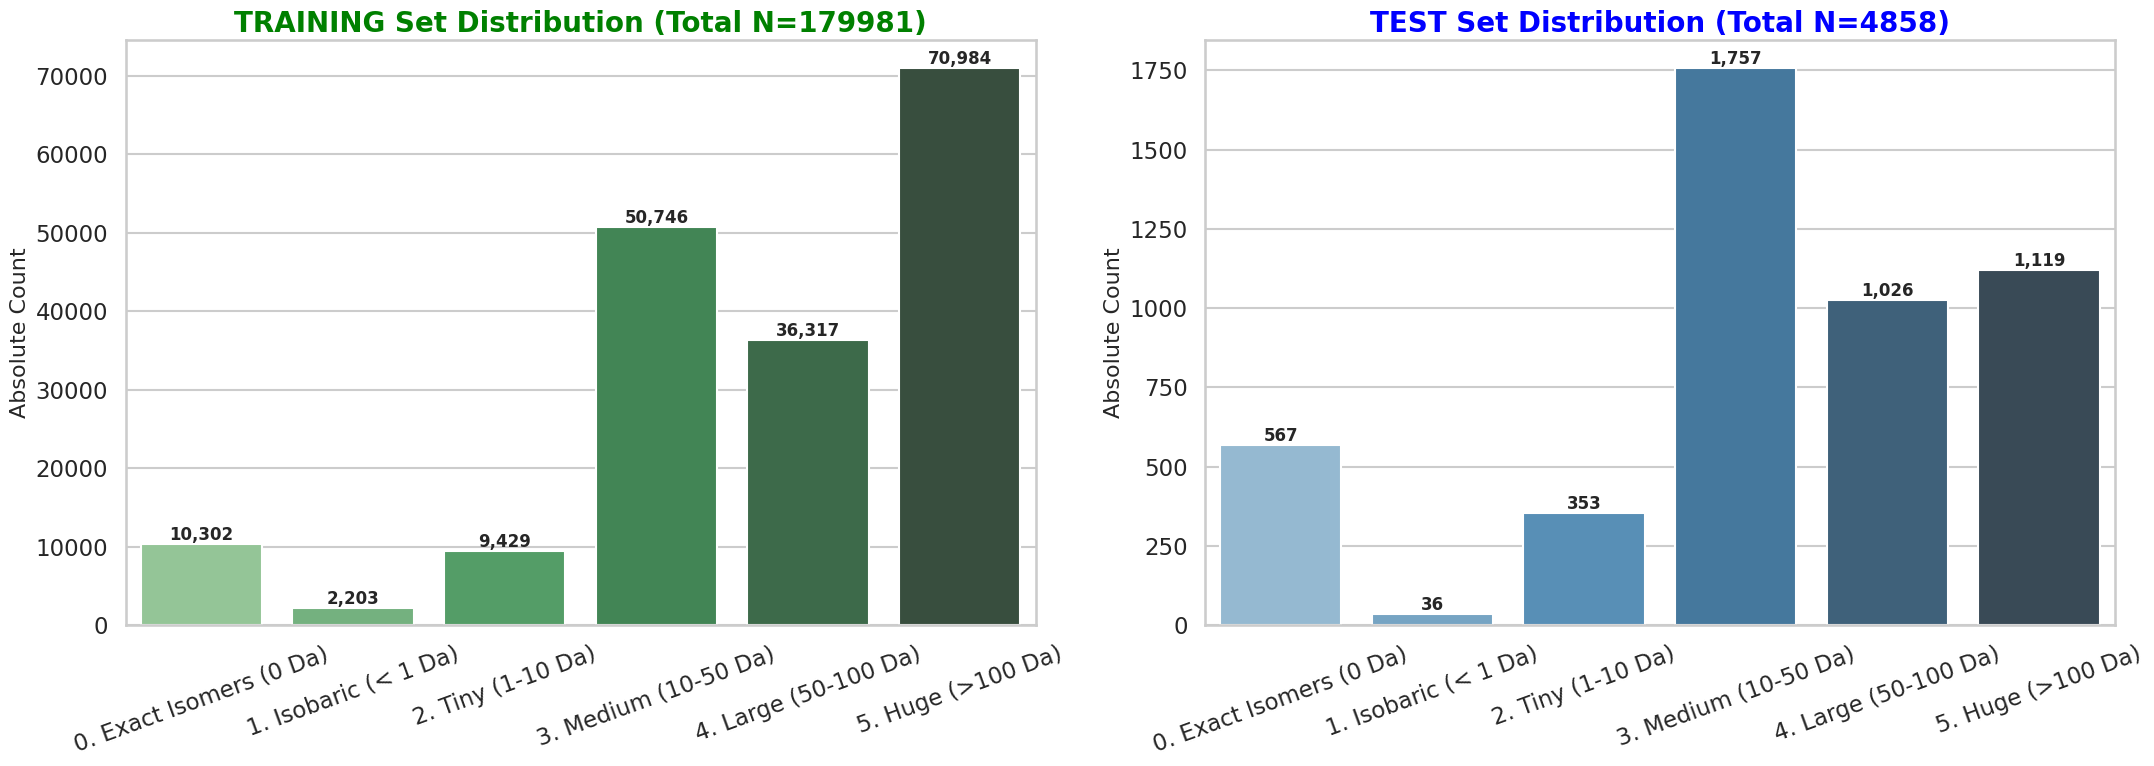


=== RAW COUNTS: TRAINING SET ===


,Mass_Regime,Count
0,0. Exact Isomers (0 Da),10302
1,1. Isobaric (< 1 Da),2203
2,2. Tiny (1-10 Da),9429
3,3. Medium (10-50 Da),50746
4,4. Large (50-100 Da),36317
5,5. Huge (>100 Da),70984



=== RAW COUNTS: TEST SET ===


,Mass_Regime,Count
0,0. Exact Isomers (0 Da),567
1,1. Isobaric (< 1 Da),36
2,2. Tiny (1-10 Da),353
3,3. Medium (10-50 Da),1757
4,4. Large (50-100 Da),1026
5,5. Huge (>100 Da),1119


In [118]:
# --- 4. PREPARE COUNTS ---
# Calculate Train Counts
train_counts = df_train_enriched['Mass_Regime'].value_counts().reindex(regime_order).reset_index()
train_counts.columns = ['Mass_Regime', 'Count']

# Calculate Test Counts
test_counts = df_test_final['Mass_Regime'].value_counts().reindex(regime_order).reset_index()
test_counts.columns = ['Mass_Regime', 'Count']

# --- 5. PLOTTING SEPARATELY ---
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# PLOT 1: TRAINING DATA
sns.barplot(data=train_counts, x='Mass_Regime', y='Count', palette="Greens_d", ax=axes[0])
axes[0].set_title(f"TRAINING Set Distribution (Total N={len(df_train_enriched)})", fontsize=20, fontweight='bold', color='green')
axes[0].set_xlabel("")
axes[0].set_ylabel("Absolute Count", fontsize=16)
axes[0].tick_params(axis='x', rotation=20)
# Add count labels
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# PLOT 2: TEST DATA
sns.barplot(data=test_counts, x='Mass_Regime', y='Count', palette="Blues_d", ax=axes[1])
axes[1].set_title(f"TEST Set Distribution (Total N={len(df_test_final)})", fontsize=20, fontweight='bold', color='blue')
axes[1].set_xlabel("")
axes[1].set_ylabel("Absolute Count", fontsize=16)
axes[1].tick_params(axis='x', rotation=20)
# Add count labels
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- 6. PRINT RAW TABLES ---
print("\n=== RAW COUNTS: TRAINING SET ===")
display(train_counts)

print("\n=== RAW COUNTS: TEST SET ===")
display(test_counts)

/tmp/ipykernel_2722976/518808418.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


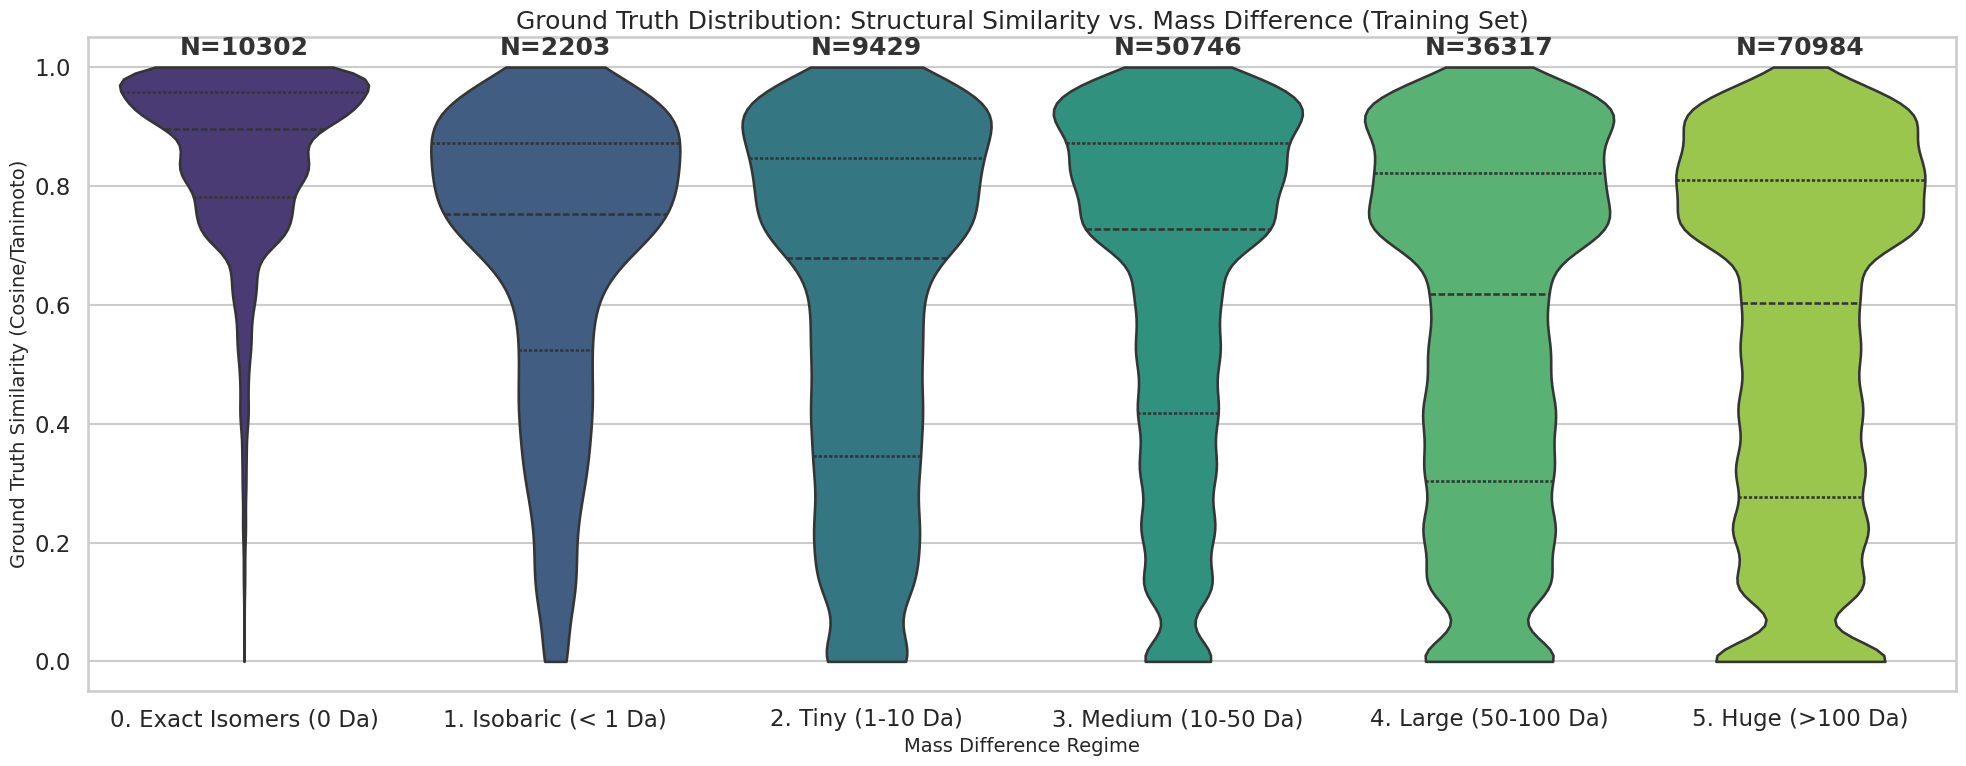

In [119]:
plt.figure(figsize=(20, 8))

# Violin Plot showing density of similarity scores per regime
sns.violinplot(
    data=df_train_enriched,
    x='Mass_Regime',
    y='cosine_similarity',  # Ground Truth
    order=regime_order,
    palette="viridis",
    cut=0, # Stop plot at min/max data points
    inner='quartile'
)

plt.title("Ground Truth Distribution: Structural Similarity vs. Mass Difference (Training Set)", fontsize=18)
plt.xlabel("Mass Difference Regime", fontsize=14)
plt.ylabel("Ground Truth Similarity (Cosine/Tanimoto)", fontsize=14)

# Add N counts
ax = plt.gca()
for i, regime in enumerate(regime_order):
    count = len(df_train_enriched[df_train_enriched['Mass_Regime'] == regime])
    ax.text(i, 1.02, f"N={count}", ha='center', fontweight='bold', color='#333')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2722976/3632766312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


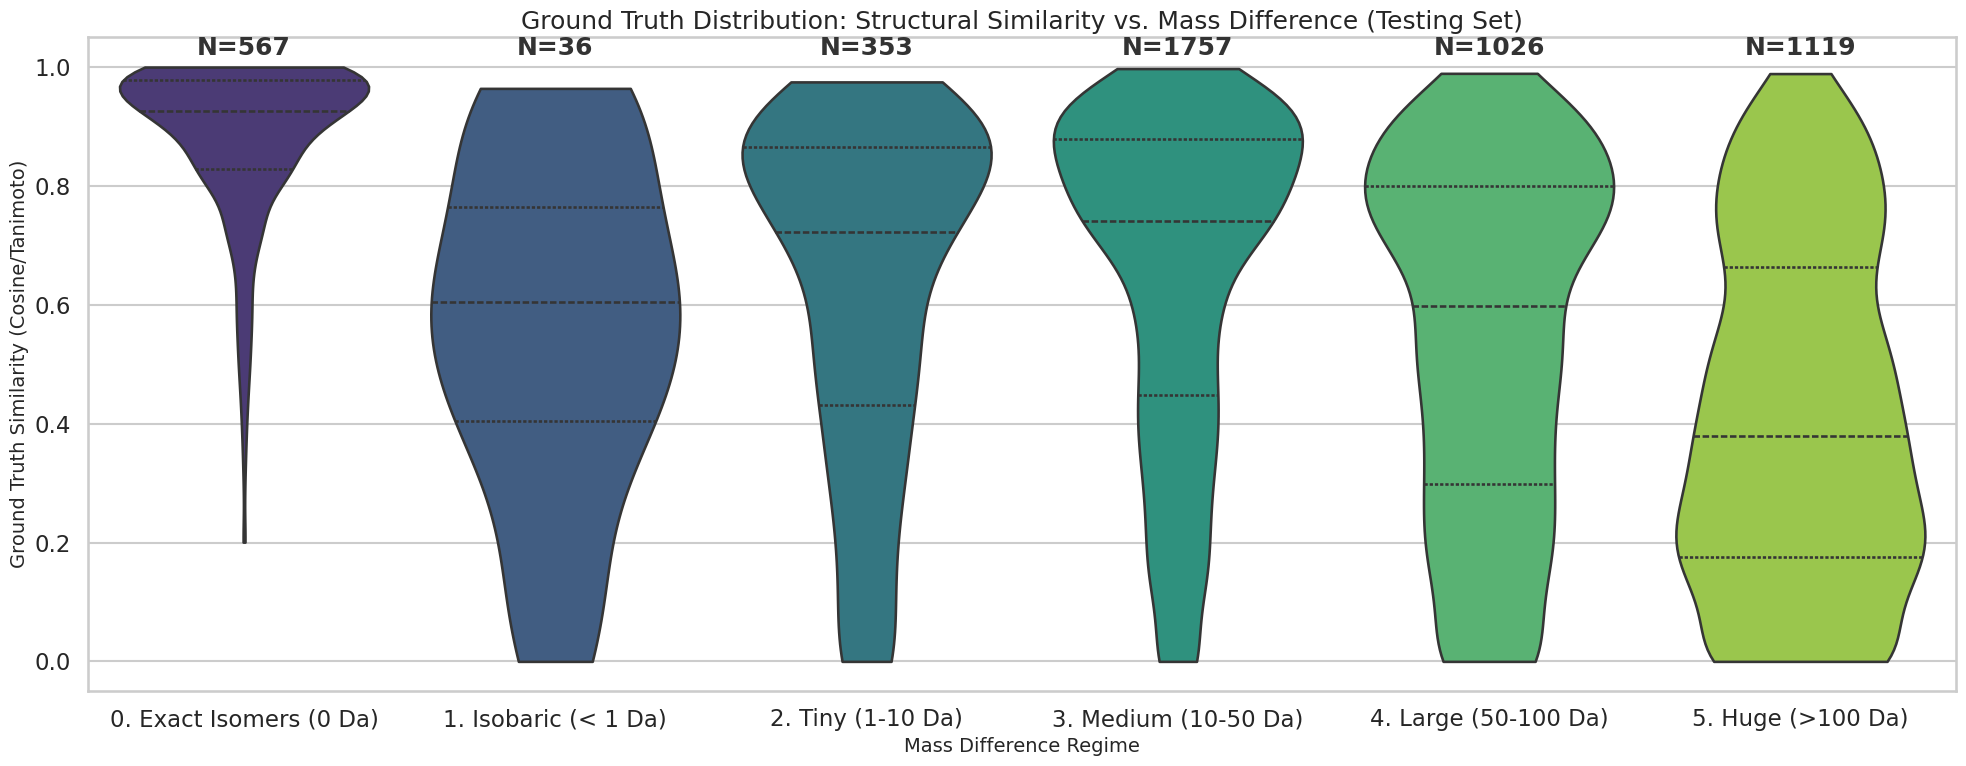

In [120]:
plt.figure(figsize=(20, 8))

# Violin Plot showing density of similarity scores per regime
sns.violinplot(
    data=df_test_final,
    x='Mass_Regime',
    y='cosine_similarity',  # Ground Truth
    order=regime_order,
    palette="viridis",
    cut=0, # Stop plot at min/max data points
    inner='quartile'
)

plt.title("Ground Truth Distribution: Structural Similarity vs. Mass Difference (Testing Set)", fontsize=18)
plt.xlabel("Mass Difference Regime", fontsize=14)
plt.ylabel("Ground Truth Similarity (Cosine/Tanimoto)", fontsize=14)

# Add N counts
ax = plt.gca()
for i, regime in enumerate(regime_order):
    count = len(df_test_enriched[df_test_final['Mass_Regime'] == regime])
    ax.text(i, 1.02, f"N={count}", ha='center', fontweight='bold', color='#333')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2722976/1590105895.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


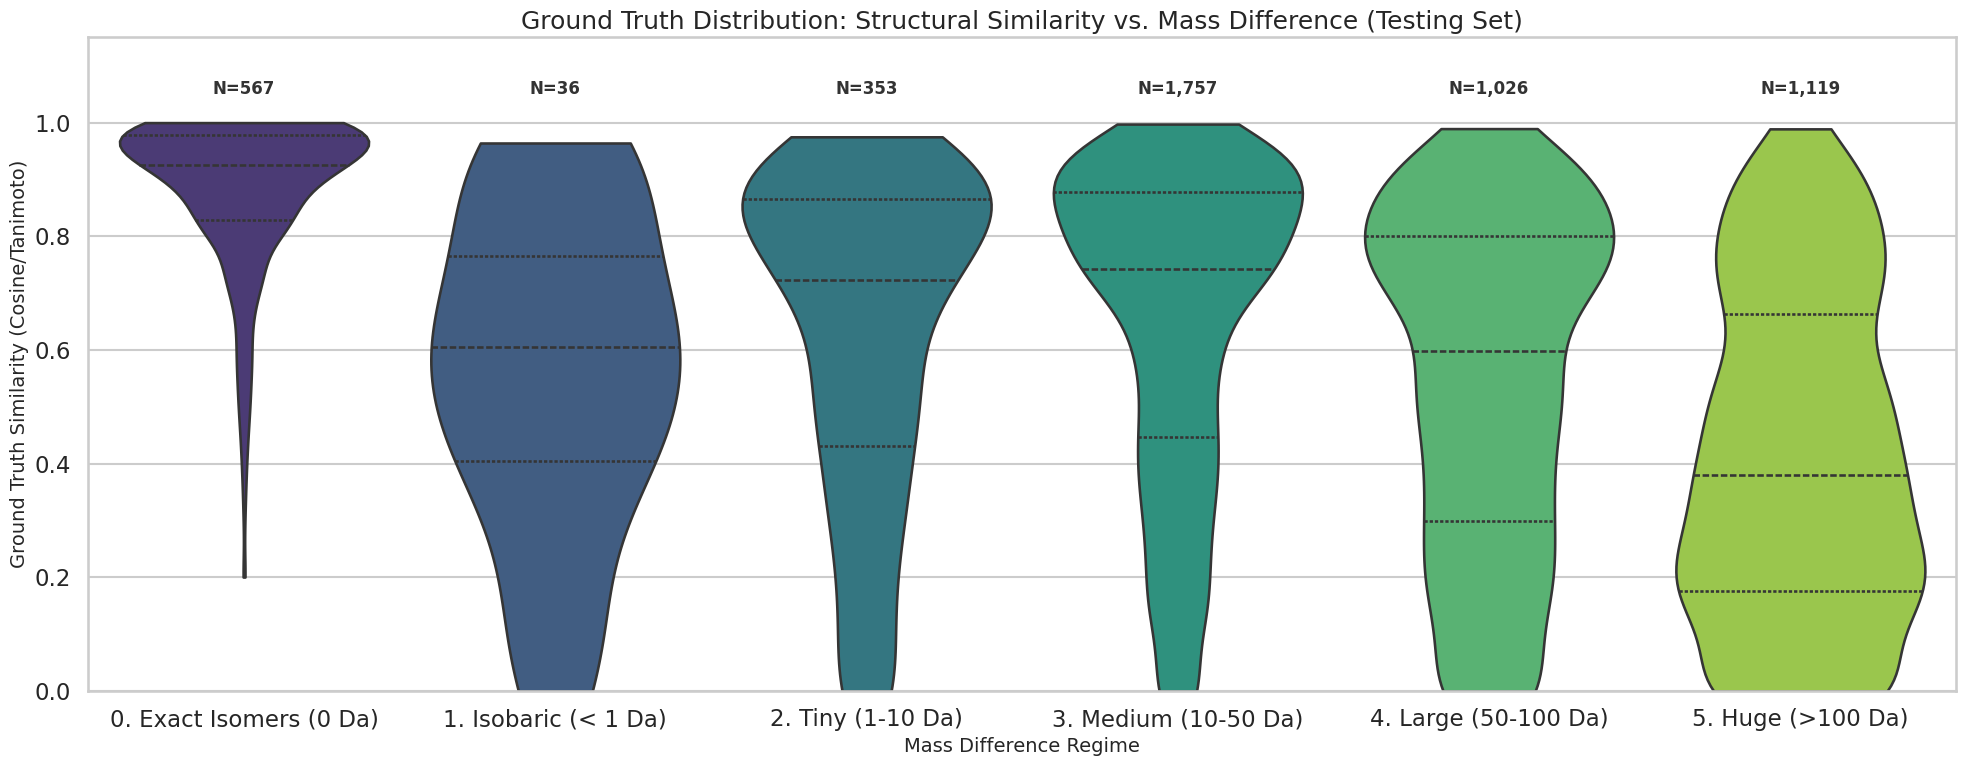


=== TEST SET DISTRIBUTION ===
Mass_Regime
0. Exact Isomers (0 Da)     567
1. Isobaric (< 1 Da)         36
2. Tiny (1-10 Da)           353
3. Medium (10-50 Da)       1757
4. Large (50-100 Da)       1026
5. Huge (>100 Da)          1119
Name: count, dtype: int64


In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure figure size is sufficient
plt.figure(figsize=(20, 8))

# Define the order if not already defined (Example)
# regime_order = ["0. Exact Isomers", "1. Isobaric", "2. Tiny", "3. Medium", "4. Large", "5. Huge"]

# Violin Plot showing density of similarity scores per regime
sns.violinplot(
    data=df_test_final,
    x='Mass_Regime',
    y='cosine_similarity',  # Ground Truth
    order=regime_order,
    palette="viridis",
    cut=0, # Stop plot at min/max data points
    inner='quartile'
)

plt.title("Ground Truth Distribution: Structural Similarity vs. Mass Difference (Testing Set)", fontsize=18)
plt.xlabel("Mass Difference Regime", fontsize=14)
plt.ylabel("Ground Truth Similarity (Cosine/Tanimoto)", fontsize=14)

# --- UPDATE: Add N counts dynamically ---
ax = plt.gca()

# Calculate max y-value to position text safely above the plot
y_max = df_test_final['cosine_similarity'].max()
text_y_pos = y_max + (y_max * 0.05) # Add 5% padding

for i, regime in enumerate(regime_order):
    # Filter the SAME dataframe used in the plot
    subset = df_test_final[df_test_final['Mass_Regime'] == regime]
    count = len(subset)
    
    # Place text at the top of each violin
    ax.text(
        i, 
        text_y_pos, 
        f"N={count:,}",  # Adds comma separator for thousands (e.g., 1,024)
        ha='center', 
        fontweight='bold', 
        color='#333',
        fontsize=12
    )

plt.ylim(0, text_y_pos + 0.1) # Adjust y-limits to make room for text
plt.tight_layout()
plt.show()

# --- OPTIONAL: PRINT TABLE ---
print("\n=== TEST SET DISTRIBUTION ===")
print(df_test_final['Mass_Regime'].value_counts().loc[regime_order])

/tmp/ipykernel_2722976/1688844716.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x="Mass_Regime", y="F1_Score", palette="magma")


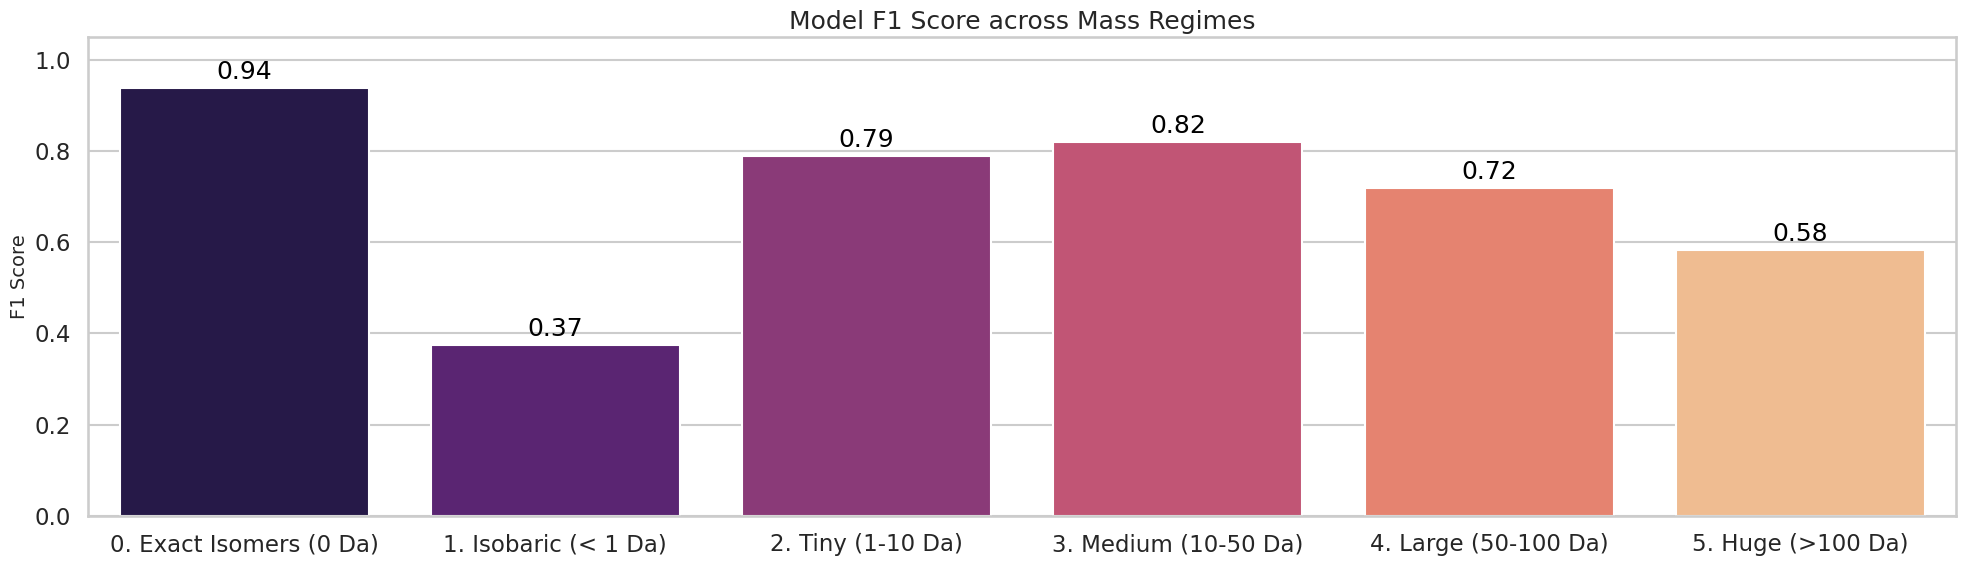

,Mass_Regime,Count,F1_Score,Accuracy,Precision,Recall
0,0. Exact Isomers (0 Da),567,0.938505,0.885362,0.916821,0.961240
1,1. Isobaric (< 1 Da),36,0.375000,0.444444,0.300000,0.500000
2,2. Tiny (1-10 Da),353,0.789238,0.733711,0.690196,0.921466
3,3. Medium (10-50 Da),1757,0.820080,0.769493,0.753469,0.899610
4,4. Large (50-100 Da),1026,0.718954,0.748538,0.669371,0.776471
5,5. Huge (>100 Da),1119,0.583333,0.803396,0.572491,0.594595


In [122]:
# Calculate Metrics per Regime
regime_metrics = []

for regime in regime_order:
    subset = df_test_final[df_test_final['Mass_Regime'] == regime]
    
    if len(subset) > 0:
        # Ground Truth Label vs Prediction
        y_true = subset['label']
        y_pred = subset['predicted_label']
        
        regime_metrics.append({
            "Mass_Regime": regime,
            "Count": len(subset),
            "F1_Score": f1_score(y_true, y_pred),
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0)
        })

df_metrics = pd.DataFrame(regime_metrics)

# Plotting F1 Score
plt.figure(figsize=(20, 6))
sns.barplot(data=df_metrics, x="Mass_Regime", y="F1_Score", palette="magma")

plt.title("Model F1 Score across Mass Regimes", fontsize=18)
plt.ylim(0, 1.05)
plt.ylabel("F1 Score", fontsize=14)
plt.xlabel("")

# Add value labels on bars
for index, row in df_metrics.iterrows():
    plt.text(index, row.F1_Score + 0.02, f"{row.F1_Score:.2f}", color='black', ha="center")

plt.tight_layout()
plt.show()

# Show the raw numbers
display(df_metrics)

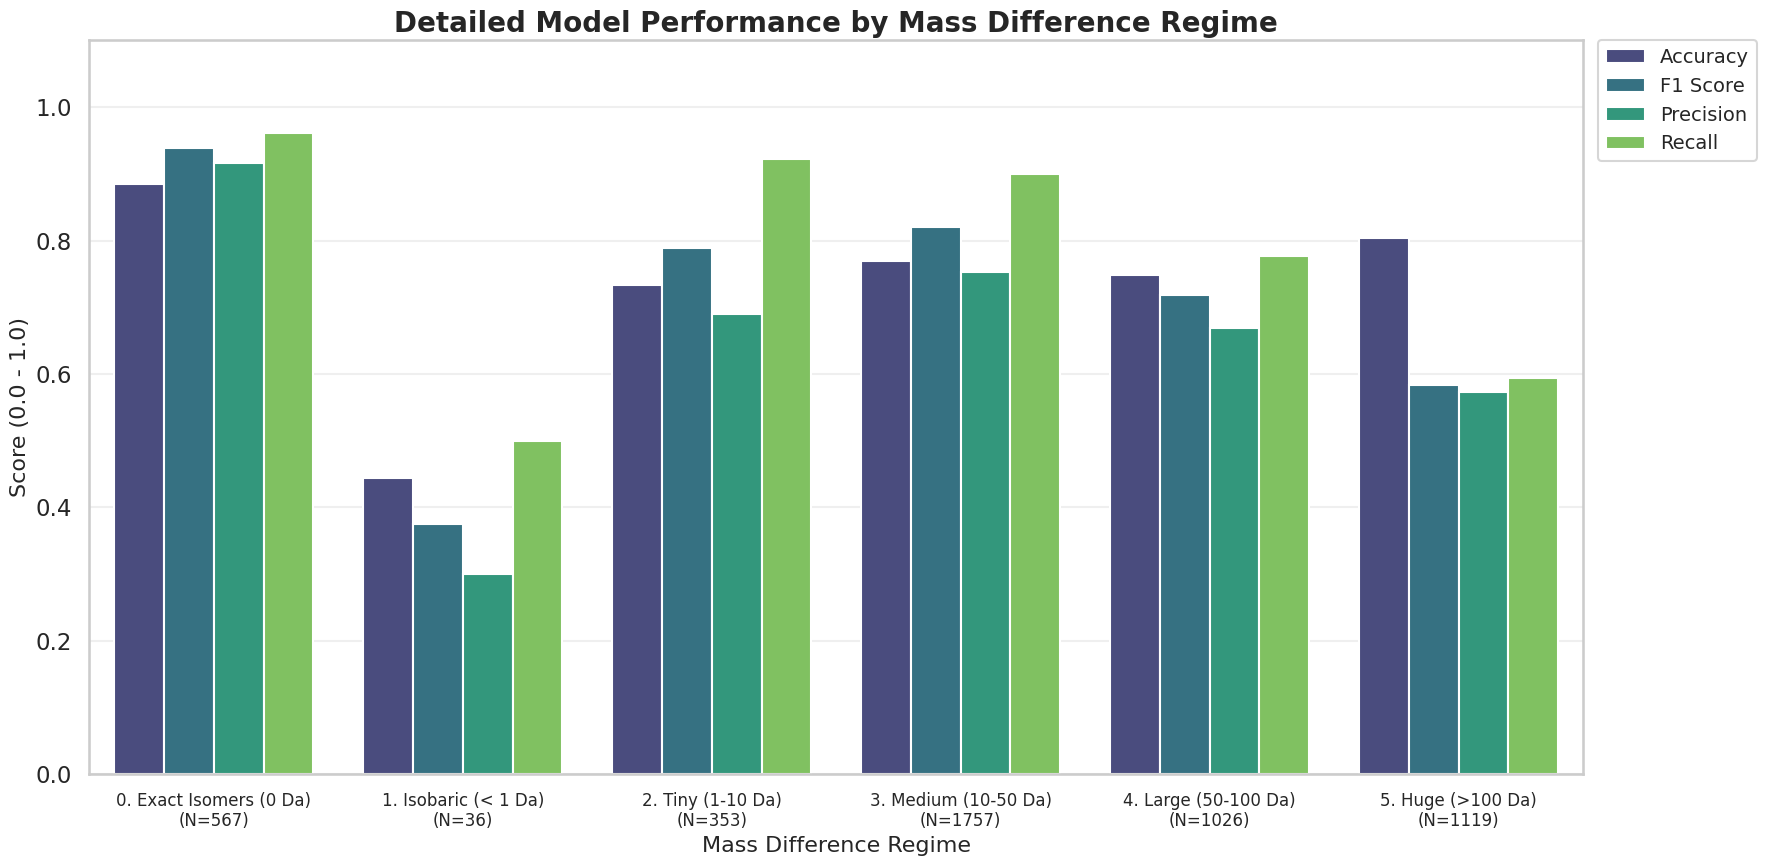


=== DETAILED PERFORMANCE METRICS TABLE ===


,Mass_Regime,Count,Accuracy,F1 Score,Precision,Recall
0,0. Exact Isomers (0 Da),567,0.8854,0.9385,0.9168,0.9612
1,1. Isobaric (< 1 Da),36,0.4444,0.3750,0.3000,0.5000
2,2. Tiny (1-10 Da),353,0.7337,0.7892,0.6902,0.9215
3,3. Medium (10-50 Da),1757,0.7695,0.8201,0.7535,0.8996
4,4. Large (50-100 Da),1026,0.7485,0.7190,0.6694,0.7765
5,5. Huge (>100 Da),1119,0.8034,0.5833,0.5725,0.5946


In [123]:
metrics_list = []

for regime in regime_order:
    # Filter data for this specific bin
    subset = df_test_final[df_test_final['Mass_Regime'] == regime]
    
    if len(subset) > 0:
        y_true = subset['label'] # Or 'true_label' depending on your column name
        y_pred = subset['predicted_label']
        
        metrics_list.append({
            "Mass_Regime": regime,
            "Count": len(subset),
            "Accuracy": accuracy_score(y_true, y_pred),
            "F1 Score": f1_score(y_true, y_pred, zero_division=0),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0)
        })

df_metrics = pd.DataFrame(metrics_list)

# --- 3. PREPARE FOR PLOTTING (Melt Data) ---
# We "melt" the dataframe to make it suitable for a grouped bar chart
df_melted = df_metrics.melt(
    id_vars=["Mass_Regime", "Count"], 
    value_vars=["Accuracy", "F1 Score", "Precision", "Recall"],
    var_name="Metric", 
    value_name="Score"
)

# --- 4. VISUALIZATION ---
plt.figure(figsize=(18, 9))

# Create Grouped Bar Plot
sns.barplot(
    data=df_melted, 
    x="Mass_Regime", 
    y="Score", 
    hue="Metric", 
    palette="viridis"
)

plt.title("Detailed Model Performance by Mass Difference Regime", fontsize=20, fontweight='bold')
plt.ylabel("Score (0.0 - 1.0)", fontsize=16)
plt.xlabel("Mass Difference Regime", fontsize=16)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Add sample counts below the x-axis labels
locs, labels = plt.xticks()
new_labels = [f"{label.get_text()}\n(N={df_metrics.loc[i, 'Count']})" for i, label in enumerate(labels)]
plt.xticks(locs, new_labels, fontsize=12)

plt.tight_layout()
plt.show()

# --- 5. DISPLAY TABLE ---
# Formatting for cleaner display
print("\n=== DETAILED PERFORMANCE METRICS TABLE ===")
format_dict = {'Accuracy': '{:.4f}', 'F1 Score': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}'}
display(df_metrics.style.format(format_dict).background_gradient(cmap='Blues', subset=['F1 Score', 'Accuracy']))

Calculating ROC curves per regime...


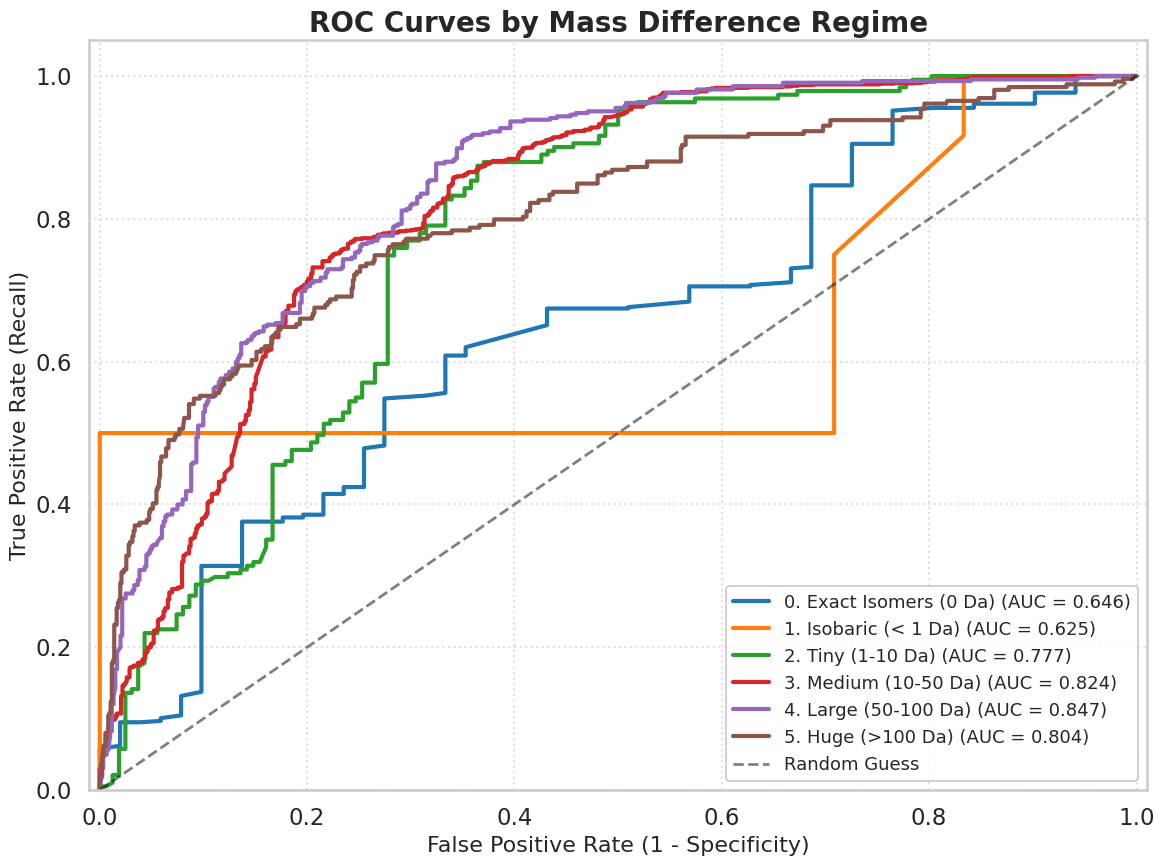


=== METRICS WITH ROC-AUC ===


,Mass_Regime,Count,Accuracy,F1 Score,Precision,Recall,ROC_AUC
0,0. Exact Isomers (0 Da),567,0.8854,0.9385,0.9168,0.9612,0.6456
1,1. Isobaric (< 1 Da),36,0.4444,0.3750,0.3000,0.5000,0.6250
2,2. Tiny (1-10 Da),353,0.7337,0.7892,0.6902,0.9215,0.7774
3,3. Medium (10-50 Da),1757,0.7695,0.8201,0.7535,0.8996,0.8242
4,4. Large (50-100 Da),1026,0.7485,0.7190,0.6694,0.7765,0.8469
5,5. Huge (>100 Da),1119,0.8034,0.5833,0.5725,0.5946,0.8041


In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

# --- 1. SETUP STORAGE ---
metrics_list = []
roc_data = {} # To store curve data for plotting

# --- 2. CALCULATE METRICS & ROC LOOP ---
print("Calculating ROC curves per regime...")

for regime in regime_order:
    subset = df_test_final[df_test_final['Mass_Regime'] == regime]
    
    # We need at least one positive and one negative sample to calc ROC
    if len(subset) > 0 and subset['label'].nunique() > 1:
        y_true = subset['label']
        y_pred = subset['predicted_label']
        y_prob = subset['prob_similarity'] # We need raw probabilities for ROC
        
        # 1. Standard Metrics
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        
        # 2. ROC Metrics
        roc_auc = roc_auc_score(y_true, y_prob)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        
        # Store for Table
        metrics_list.append({
            "Mass_Regime": regime,
            "Count": len(subset),
            "Accuracy": acc,
            "F1 Score": f1,
            "Precision": prec,
            "Recall": rec,
            "ROC_AUC": roc_auc
        })
        
        # Store for Plotting
        roc_data[regime] = (fpr, tpr, roc_auc)
        
    elif len(subset) > 0:
        print(f"Skipping ROC for {regime}: Only 1 class present (All Pos or All Neg).")

df_metrics = pd.DataFrame(metrics_list)

# --- 3. PLOT ROC CURVES ---
plt.figure(figsize=(12, 9)) # Slightly larger for clarity

# --- CHANGED: Use a High-Contrast Categorical Palette ---
# 'tab10' is standard for <10 distinct categories. 
# If you have >10, use 'tab20'.
colors = sns.color_palette("tab10", len(roc_data)) 

# You can also manually force specific colors if preferred:
# colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

for i, (regime, (fpr, tpr, roc_val)) in enumerate(roc_data.items()):
    plt.plot(
        fpr, tpr, 
        color=colors[i], 
        lw=3, # Thicker lines for visibility
        label=f'{regime} (AUC = {roc_val:.3f})'
    )

# Plot Diagonal (Random Guess)
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', alpha=0.5, label='Random Guess')

plt.xlim([-0.01, 1.01]) # Slight padding
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=16)
plt.ylabel('True Positive Rate (Recall)', fontsize=16)
plt.title('ROC Curves by Mass Difference Regime', fontsize=20, fontweight='bold')

# Legend moved outside if there are many lines, or lower right if fits
plt.legend(loc="lower right", fontsize=13, frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- 4. DISPLAY UPDATED TABLE ---
print("\n=== METRICS WITH ROC-AUC ===")
format_dict = {'Accuracy': '{:.4f}', 'F1 Score': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'ROC_AUC': '{:.4f}'}
display(df_metrics.style.format(format_dict).background_gradient(cmap='Blues', subset=['ROC_AUC', 'F1 Score']))

## Chemical Ontology Regime

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [20]:
# Visualization Styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [20]:
# --- 1. DEFINE CLASSIFIER LOGIC ---
def get_chemical_class(mol):
    """
    Classifies a molecule into a primary chemical behavior category 
    using RDKit structural descriptors.
    """
    if not mol: return "Unknown"
    
    # Calculate descriptors
    num_rings = rdMolDescriptors.CalcNumRings(mol)
    num_arom = rdMolDescriptors.CalcNumAromaticRings(mol)
    num_rotatable = rdMolDescriptors.CalcNumRotatableBonds(mol)
    has_halogen = any(atom.GetAtomicNum() in [9, 17, 35, 53] for atom in mol.GetAtoms())
    num_heteroatoms = rdMolDescriptors.CalcNumHeteroatoms(mol)
    mw = rdMolDescriptors.CalcExactMolWt(mol)
    
    # --- CLASSIFICATION HIERARCHY ---
    
    # 1. Lipid-like (Long chains, low aromaticity, high rotatable bonds)
    # Typical fatty acids, glycerolipids, etc. fragment heavily along chains
    if num_rotatable > 12 and num_arom <= 1:
        return "1. Lipid-like / Aliphatic"
    
    # 2. Halogenated (Contains F, Cl, Br, I)
    # Distinct isotopic patterns, often drugs or pesticides
    elif has_halogen:
        return "2. Halogenated (Drugs/Pesticides)"
    
    # 3. Highly Aromatic (Polyphenols, Flavonoids, PAHs)
    # Rigid structures, distinct stable fragment ions
    elif num_arom >= 3:
        return "3. Highly Aromatic / Polycyclic"
    
    # 4. Heterocyclic / Alkaloid-like (Rings with N/O/S, moderate aromaticity)
    # Common drugs and metabolites
    elif num_rings >= 2 and num_heteroatoms >= 2:
        return "4. Heterocyclic / Alkaloid-like"
    
    # 5. Small Polar / Simple (Low MW, minimal complexity)
    # Amino acids, small organic acids, sugars
    elif mw < 250:
        return "5. Small Polar / Simple"
    
    else:
        return "6. Diverse / Complex"

In [32]:
    # --- 2. LOAD DATA ---
# Paths (Update as needed)
MOL_DF_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
TEST_RESULTS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/results/predictions/binary_classifier/mass_gate/results_stratified_binary_07_dataset_test.csv"
TRAIN_PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train.feather"

In [22]:
print("Loading Molecule Database...")
df_mols = pd.read_pickle(MOL_DF_PATH)

Loading Molecule Database...


In [23]:
df_mols.head()

,smiles,mol_id,mol,inchikey_s,scaffold,formula,inchi,mw,exact_mw
0,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,0,<rdkit.Chem.rdchem.Mol object at 0x71cfbdcd1d60>,PHNUZKMIPFFYSO,c1ccccc1,C12H11Cl2NO,"InChI=1S/C12H11Cl2NO/c1-4-12(2,3)15-11(16)8-5-...",256.132,255.021769
1,C#CC(C)(CC)NC(=O)c1ccc(OC)c(OC)c1,1,<rdkit.Chem.rdchem.Mol object at 0x71cec439ed60>,AXVWGMWNLRUAEQ,c1ccccc1,C15H19NO3,"InChI=1S/C15H19NO3/c1-6-15(3,7-2)16-14(17)11-8...",261.321,261.136493
2,C#CC(C)N(C)C(=O)Nc1ccc(Cl)cc1,2,<rdkit.Chem.rdchem.Mol object at 0x71cec439edb0>,BYYMILHAKOURNM,c1ccccc1,C12H13ClN2O,InChI=1S/C12H13ClN2O/c1-4-9(2)15(3)12(16)14-11...,236.702,236.071641
3,C#CC(F)(F)C1(O)CCC2C3=C(C4=C(CC3)CC(=O)CC4)C(c...,3,<rdkit.Chem.rdchem.Mol object at 0x71cec439ee00>,JQXWLRWDYILWKH,O=C1CCC2=C(CCC3=C2C(c2ccc(-c4ccccc4)cc2)CC2CCC...,C36H38F2O2,"InChI=1S/C36H38F2O2/c1-6-36(37,38)35(40)16-15-...",540.694,540.283987
4,C#CC1(CO)OC(n2cnc3c(N)nc(F)nc32)CC1O,4,<rdkit.Chem.rdchem.Mol object at 0x71cec439ee50>,IKKXOSBHLYMWAE,c1ncc2ncn(C3CCCO3)c2n1,C12H12FN5O3,InChI=1S/C12H12FN5O3/c1-2-12(4-19)6(20)3-7(21-...,293.258,293.092417


In [24]:
# Apply Classification
print("Classifying Molecules (this may take a minute)...")
# Note: 'mol' column contains RDKit objects
df_mols['Chemical_Class'] = df_mols['mol'].apply(get_chemical_class)

print("Classification Distribution:")
print(df_mols['Chemical_Class'].value_counts())

Classifying Molecules (this may take a minute)...
Classification Distribution:
Chemical_Class
4. Heterocyclic / Alkaloid-like      10431
3. Highly Aromatic / Polycyclic       6909
2. Halogenated (Drugs/Pesticides)     5048
1. Lipid-like / Aliphatic             2560
5. Small Polar / Simple               1983
6. Diverse / Complex                  1038
Name: count, dtype: int64


In [26]:
# --- 1. LOAD SPEC METADATA (The Bridge) ---
# We need this bridge file to link Spec IDs (name_main) to Mol IDs
SPEC_META_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"
print("Loading Spec Metadata for ID mapping...")
df_spec_bridge = pd.read_pickle(SPEC_META_PATH)

Loading Spec Metadata for ID mapping...


In [27]:
df_spec_bridge.head()

,spec_id,mol_id,prec_type,inst_type,frag_mode,ion_mode,dset,res,ace,nce,prec_mz,peaks,ri,temp_charge,nce_updated
0,MassSpecGymID0036521,20679,[M+H]+,QTOF,CID,P,custom_dataset,4,20.0,31.933772,313.148100,"[(213.0501, 0.01461951), (230.0755, 0.02100750...",NaN,1.0,31.933772
1,MassSpecGymID0196017,7789,[M+H]+,Other,CID,P,custom_dataset,6,NaN,64.688543,706.401000,"[(75.044678, 0.00057482), (75.062744, 0.000790...",NaN,1.0,NaN
2,MassSpecGymID0236624,5990,[M+H]+,FT,CID,P,custom_dataset,6,60.0,47.983670,625.212700,"[(135.044479, 0.1624), (145.028961, 0.16978000...",NaN,1.0,47.983670
3,MassSpecGymID0081645,79,[M+H]+,QTOF,CID,P,custom_dataset,6,20.0,44.818334,223.122975,"[(77.038577, 0.12112112112112113), (94.065126,...",NaN,1.0,44.818334
4,MassSpecGymID0218985,5,[M+H]+,FT,CID,P,custom_dataset,6,20.0,37.300517,268.092800,"[(62.018265, 0.00619), (95.023788, 0.002250000...",NaN,1.0,37.300517


In [28]:
# --- 2. DEFINE ROBUST MERGE FUNCTION ---
def merge_class_info(pairs_df, mol_df, spec_bridge_df):
    """
    Links pairs to chemical classes using the path:
    Pairs(name_main) -> Spec_DF(spec_id) -> Spec_DF(mol_id) -> Mol_DF(mol_id) -> Class
    """
    # Step 1: Link Pairs to Mol IDs using the Spec Bridge
    # We join 'name_main' (which is a SpecID) with 'spec_id' in the bridge
    merged_step1 = pairs_df.merge(
        spec_bridge_df[['spec_id', 'mol_id']], 
        left_on='name_main', 
        right_on='spec_id', 
        how='left'
    )
    
    # Check for missing links
    missing_mols = merged_step1['mol_id'].isna().sum()
    if missing_mols > 0:
        print(f"Warning: {missing_mols} records could not be mapped to a Mol ID.")

    # Step 2: Link the retrieved Mol IDs to the Chemical Class
    final_merged = merged_step1.merge(
        mol_df[['mol_id', 'Chemical_Class']],
        on='mol_id',
        how='left'
    )
    
    # Clean up duplicate columns if any
    if 'spec_id' in final_merged.columns:
        final_merged = final_merged.drop(columns=['spec_id'])
        
    return final_merged

In [29]:
# --- 3. EXECUTE MERGE ---

# A. Process Training Pairs
print("Processing Training Pairs...")
df_train_pairs = pd.read_feather(TRAIN_PAIRS_PATH)
df_train_classed = merge_class_info(df_train_pairs, df_mols, df_spec_bridge)

Processing Training Pairs...


In [30]:
df_train_classed.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,mol_id,Chemical_Class
0,MassSpecGymID0078974,MassSpecGymID0214701,0.188679,0.702941,1.0,4338.0,5. Small Polar / Simple
1,MassSpecGymID0074719,MassSpecGymID0218883,0.148148,0.621023,0.0,11413.0,6. Diverse / Complex
2,MassSpecGymID0007593,MassSpecGymID0224784,0.538462,0.951866,1.0,24043.0,4. Heterocyclic / Alkaloid-like
3,MassSpecGymID0064493,MassSpecGymID0065607,0.416667,0.510570,0.0,4192.0,4. Heterocyclic / Alkaloid-like
4,MassSpecGymID0034253,MassSpecGymID0039027,0.200000,0.357671,0.0,6610.0,4. Heterocyclic / Alkaloid-like


In [33]:
# B. Process Test Predictions
print("Processing Test Predictions...")
df_test_preds = pd.read_csv(TEST_RESULTS_PATH)

Processing Test Predictions...


In [34]:
df_test_preds.head()

,name_main,name_sub,cosine_similarity,true_label,prob_similarity,predicted_label
0,MassSpecGymID0003031,MassSpecGymID0049401,0.706041,1.0,0.887815,1.0
1,MassSpecGymID0223776,MassSpecGymID0237961,0.648690,0.0,0.038258,0.0
2,MassSpecGymID0224062,MassSpecGymID0234208,0.122628,0.0,0.002725,0.0
3,MassSpecGymID0003081,MassSpecGymID0060725,0.773729,1.0,0.983004,1.0
4,MassSpecGymID0148794,MassSpecGymID0159098,0.449861,0.0,0.748159,1.0


In [35]:
# Re-attach 'name_main' if missing (required for the link)
if 'name_main' not in df_test_preds.columns:
    print("  > Re-attaching IDs to test predictions...")
    TEST_PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
    df_test_pairs = pd.read_feather(TEST_PAIRS_PATH)
    
    # concat is safer than merge if we are sure rows align (no shuffle)
    # If uncertain, ensure both have an index or ID to merge on
    df_test_preds = pd.concat([
        df_test_pairs[['name_main', 'name_sub']], 
        df_test_preds[['predicted_label', 'prob_similarity']]
    ], axis=1)

In [36]:
df_test_classed = merge_class_info(df_test_preds, df_mols, df_spec_bridge)

# --- 4. VERIFY RESULTS ---
print("\nTraining Set Class Distribution:")
print(df_train_classed['Chemical_Class'].value_counts())

print("\nTest Set Class Distribution:")
print(df_test_classed['Chemical_Class'].value_counts())

# Define Order for Plots (excluding Unknowns/NaNs)
class_order = sorted([c for c in df_test_classed['Chemical_Class'].dropna().unique() if "Unknown" not in c])


Training Set Class Distribution:
Chemical_Class
4. Heterocyclic / Alkaloid-like      66588
3. Highly Aromatic / Polycyclic      39143
5. Small Polar / Simple              35588
2. Halogenated (Drugs/Pesticides)    26079
6. Diverse / Complex                  8789
1. Lipid-like / Aliphatic             3802
Name: count, dtype: int64

Test Set Class Distribution:
Chemical_Class
4. Heterocyclic / Alkaloid-like      2539
2. Halogenated (Drugs/Pesticides)    1163
3. Highly Aromatic / Polycyclic       865
6. Diverse / Complex                  205
5. Small Polar / Simple                52
1. Lipid-like / Aliphatic              34
Name: count, dtype: int64


/tmp/ipykernel_115497/2606621258.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


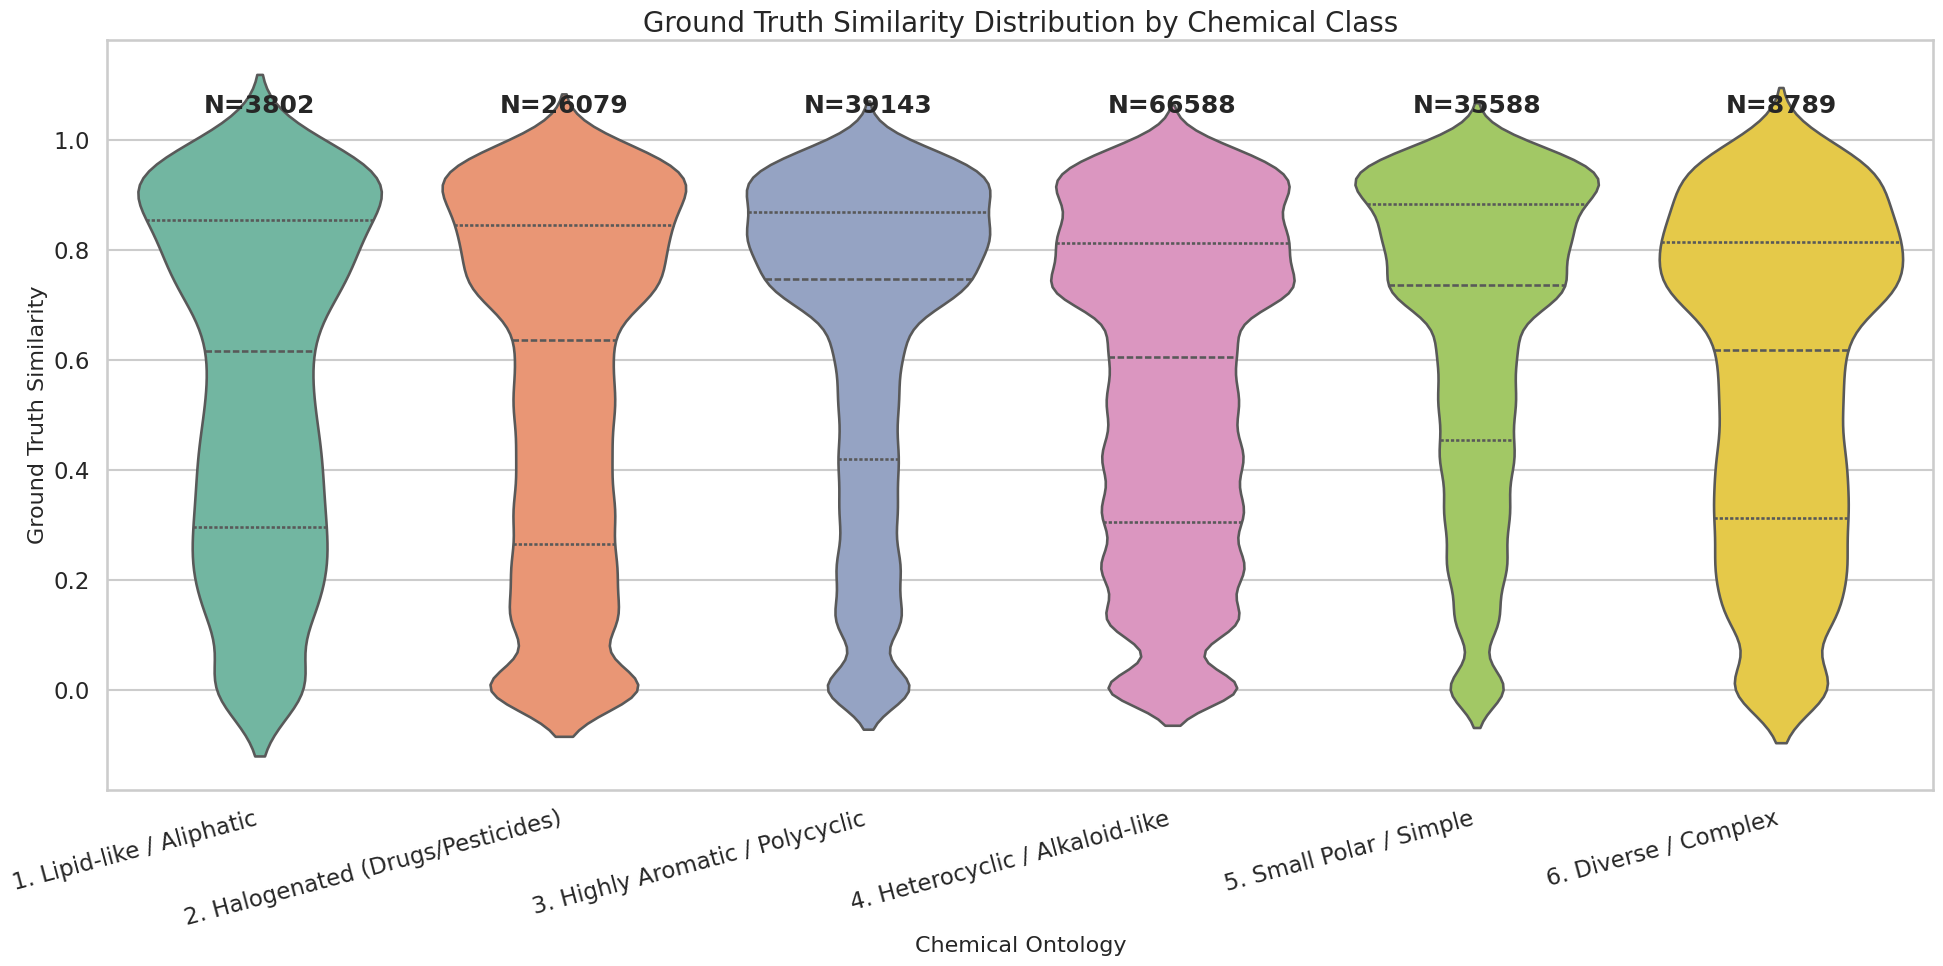

In [41]:
plt.figure(figsize=(20, 10))

sns.violinplot(
    data=df_train_classed,
    x='Chemical_Class',
    y='cosine_similarity', # Ground Truth
    order=class_order,
    palette="Set2",
    inner='quartile'
)

plt.title("Ground Truth Similarity Distribution by Chemical Class", fontsize=20)
plt.xlabel("Chemical Ontology", fontsize=16)
plt.ylabel("Ground Truth Similarity", fontsize=16)
plt.xticks(rotation=15, ha='right')

# Add counts
ax = plt.gca()
for i, cls in enumerate(class_order):
    count = len(df_train_classed[df_train_classed['Chemical_Class'] == cls])
    ax.text(i, 1.05, f"N={count}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [42]:
# --- 1. DEFINE CHEMICAL CLASSIFIER (Same as before) ---
def get_chemical_class(mol):
    if not mol: return "Unknown"
    num_rings = rdMolDescriptors.CalcNumRings(mol)
    num_arom = rdMolDescriptors.CalcNumAromaticRings(mol)
    num_rotatable = rdMolDescriptors.CalcNumRotatableBonds(mol)
    has_halogen = any(atom.GetAtomicNum() in [9, 17, 35, 53] for atom in mol.GetAtoms())
    num_heteroatoms = rdMolDescriptors.CalcNumHeteroatoms(mol)
    mw = rdMolDescriptors.CalcExactMolWt(mol)
    
    if num_rotatable > 12 and num_arom <= 1: return "1. Lipid-like"
    elif has_halogen: return "2. Halogenated"
    elif num_arom >= 3: return "3. Highly Aromatic"
    elif num_rings >= 2 and num_heteroatoms >= 2: return "4. Heterocyclic"
    elif mw < 250: return "5. Small Polar"
    else: return "6. Diverse/Complex"

# Apply classification if not already done
if 'Chemical_Class' not in df_mols.columns:
    print("Classifying molecules...")
    df_mols['Chemical_Class'] = df_mols['mol'].apply(get_chemical_class)

# --- 2. PAIR LINKING FUNCTION ---
def classify_pairs(pairs_df, mol_df, spec_bridge):
    """Classifies BOTH Molecule A and Molecule B in the pair."""
    
    # Helper to merge a specific column
    def merge_col(df, col_name, suffix):
        # Link Pair -> Spec -> Mol
        step1 = df.merge(
            spec_bridge[['spec_id', 'mol_id']], 
            left_on=col_name, right_on='spec_id', how='left'
        ).drop(columns=['spec_id'])
        
        # Link Mol -> Class
        step2 = step1.merge(
            mol_df[['mol_id', 'Chemical_Class']], 
            on='mol_id', how='left'
        ).rename(columns={'Chemical_Class': f'Class_{suffix}'}).drop(columns=['mol_id'])
        
        return step2

    print("Classifying Side A (Main)...")
    df_A = merge_col(pairs_df, 'name_main', 'Main')
    
    print("Classifying Side B (Sub)...")
    # We pass the result of the first merge into the second
    df_final = merge_col(df_A, 'name_sub', 'Sub')
    
    # Label the Relationship Type
    df_final['Pair_Type'] = np.where(
        df_final['Class_Main'] == df_final['Class_Sub'], 
        "Same Class", 
        "Cross Class"
    )
    
    return df_final

# --- EXECUTE ---
print("Loading Pairs...")
df_train = pd.read_feather(TRAIN_PAIRS_PATH)
df_analyzed = classify_pairs(df_train, df_mols, df_spec_bridge)
print("Done!")

Loading Pairs...
Classifying Side A (Main)...
Classifying Side B (Sub)...
Done!


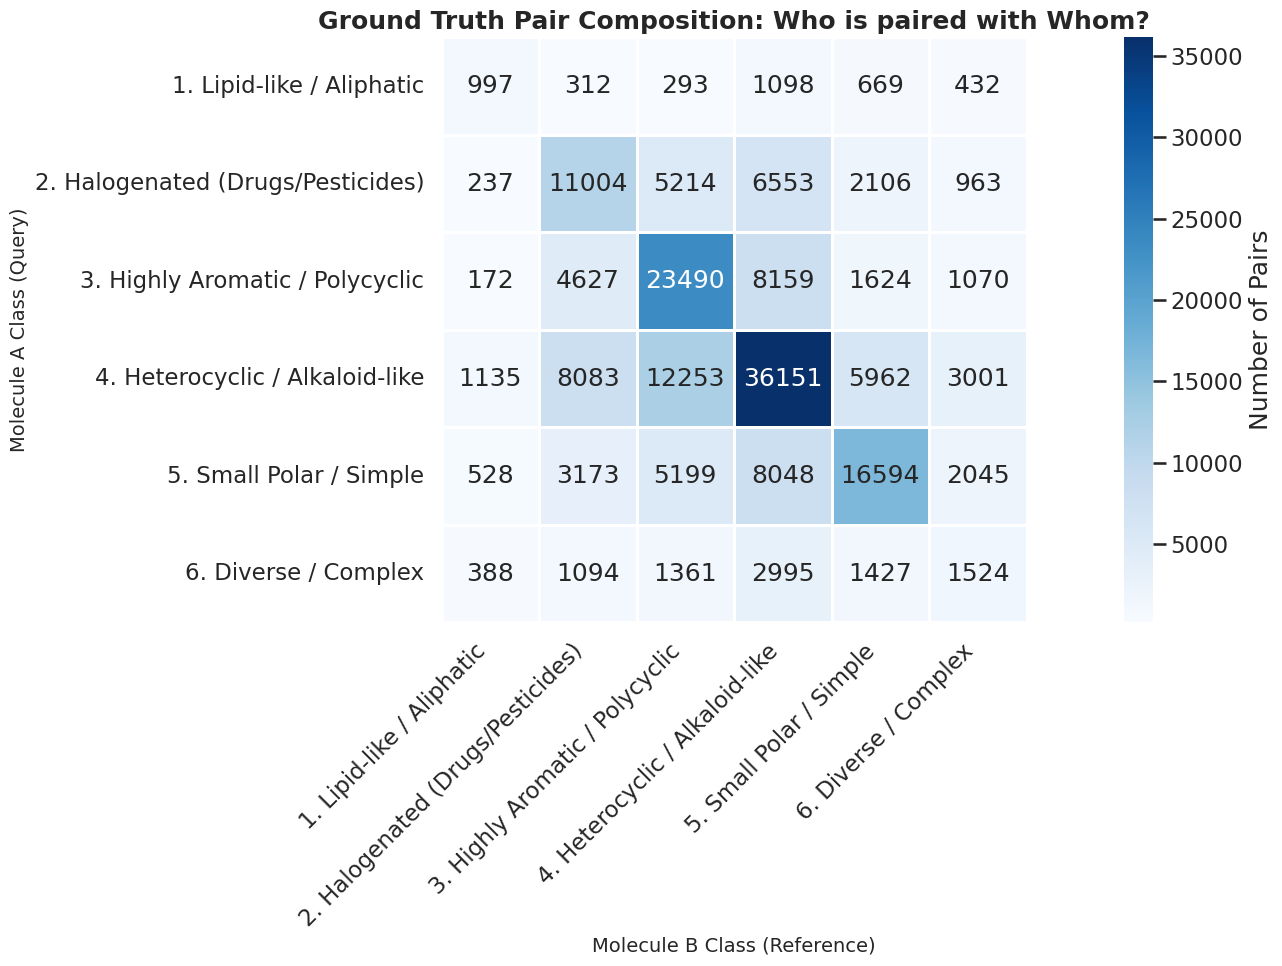

In [44]:
# 1. Create Contingency Table (Matrix)
# We exclude 'Unknown' to keep the plot clean
clean_df = df_analyzed.dropna(subset=['Class_Main', 'Class_Sub'])
clean_df = clean_df[
    (~clean_df['Class_Main'].astype(str).str.contains("Unknown")) & 
    (~clean_df['Class_Sub'].astype(str).str.contains("Unknown"))
]

matrix_counts = pd.crosstab(clean_df['Class_Main'], clean_df['Class_Sub'])

# 2. Plot Heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(
    matrix_counts, 
    annot=True, 
    fmt="d",      # Integer formatting
    cmap="Blues", # Darker blue = More pairs
    cbar_kws={'label': 'Number of Pairs'},
    square=True,
    linewidths=1,
    linecolor='white'
)

plt.title("Ground Truth Pair Composition: Who is paired with Whom?", fontsize=18, fontweight='bold')
plt.xlabel("Molecule B Class (Reference)", fontsize=14)
plt.ylabel("Molecule A Class (Query)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Loading Metadata...
Classifying molecules...
Classifying pairs (this may take a moment)...
Linking Side A...
Linking Side B...


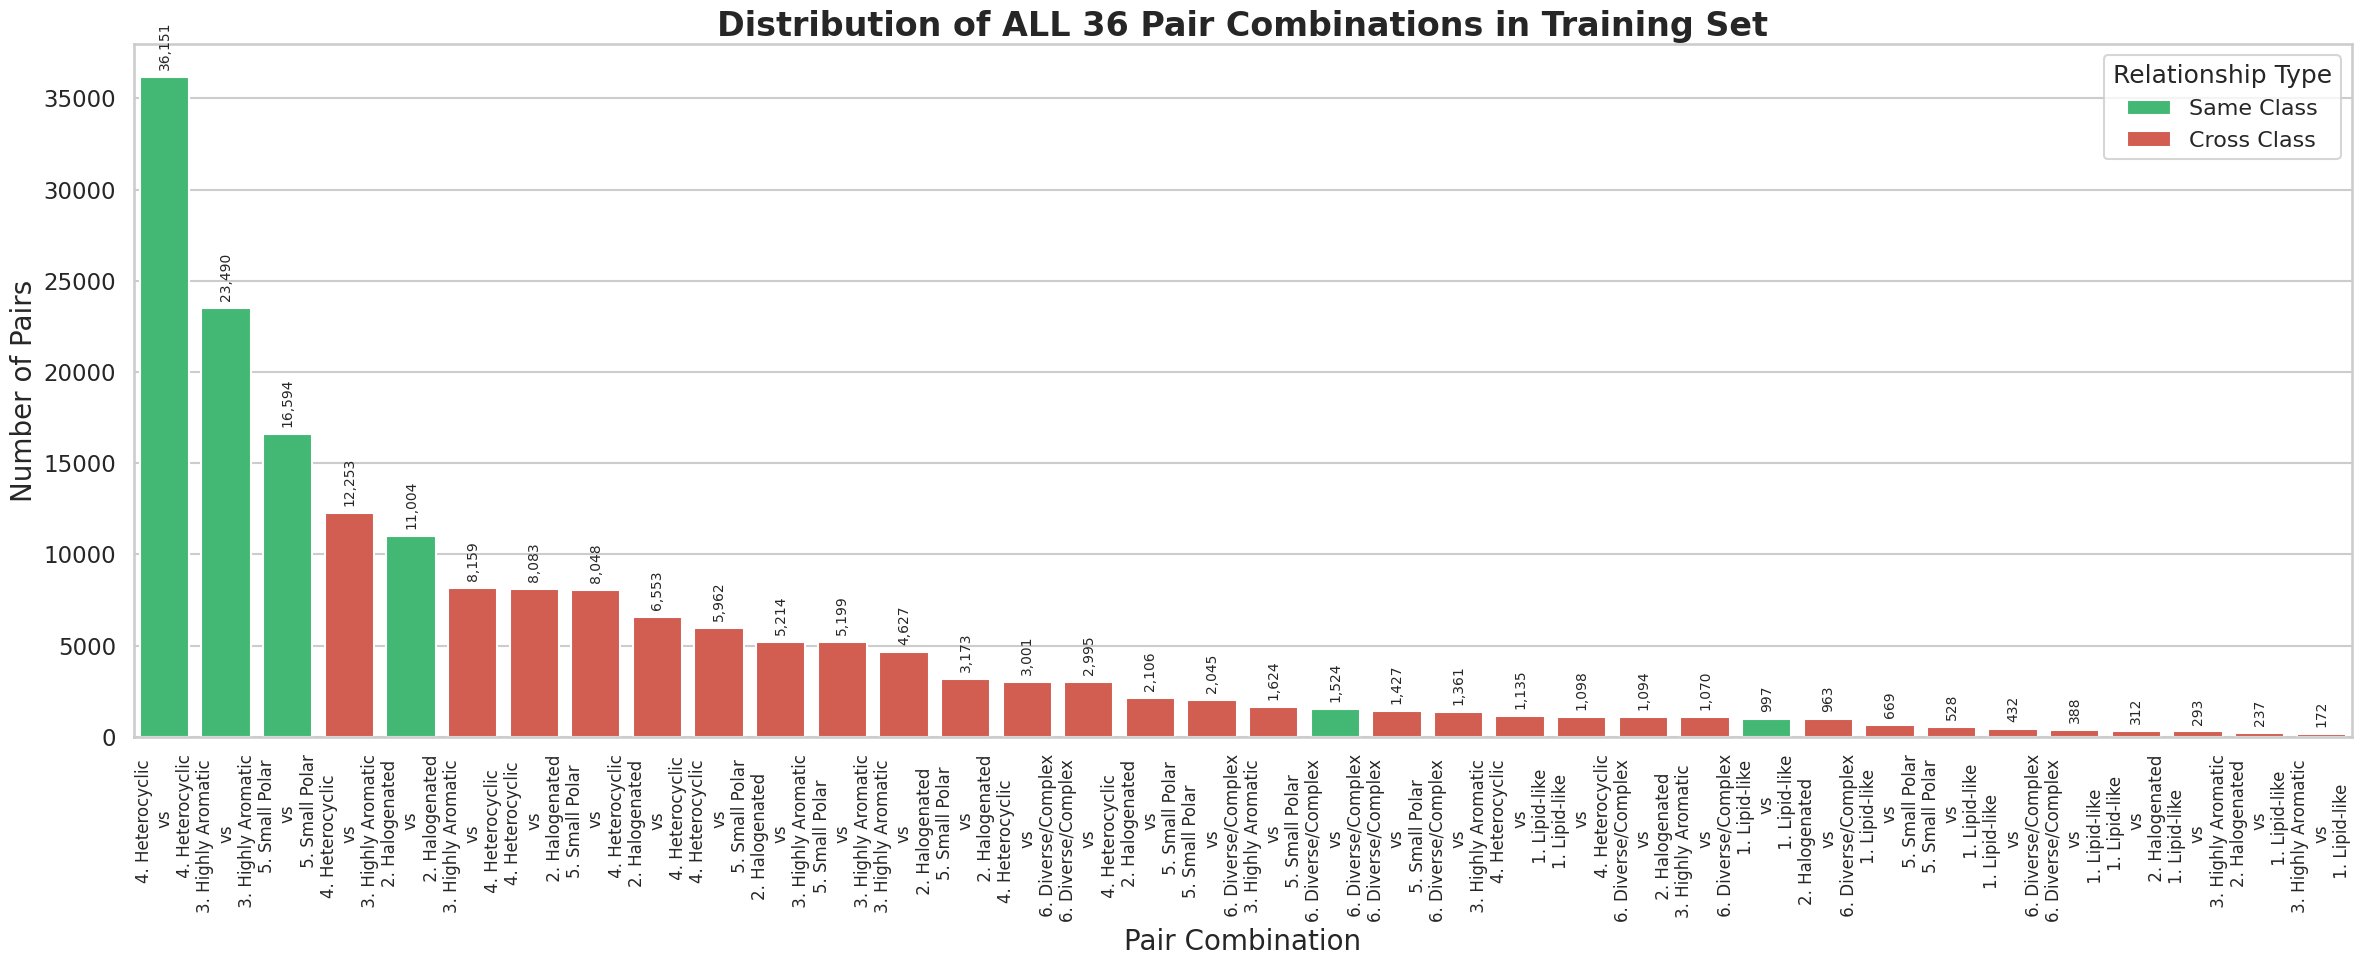

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_115497/2303019773.py:159: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(combo_order, rotation=90, ha='center', fontsize=12)


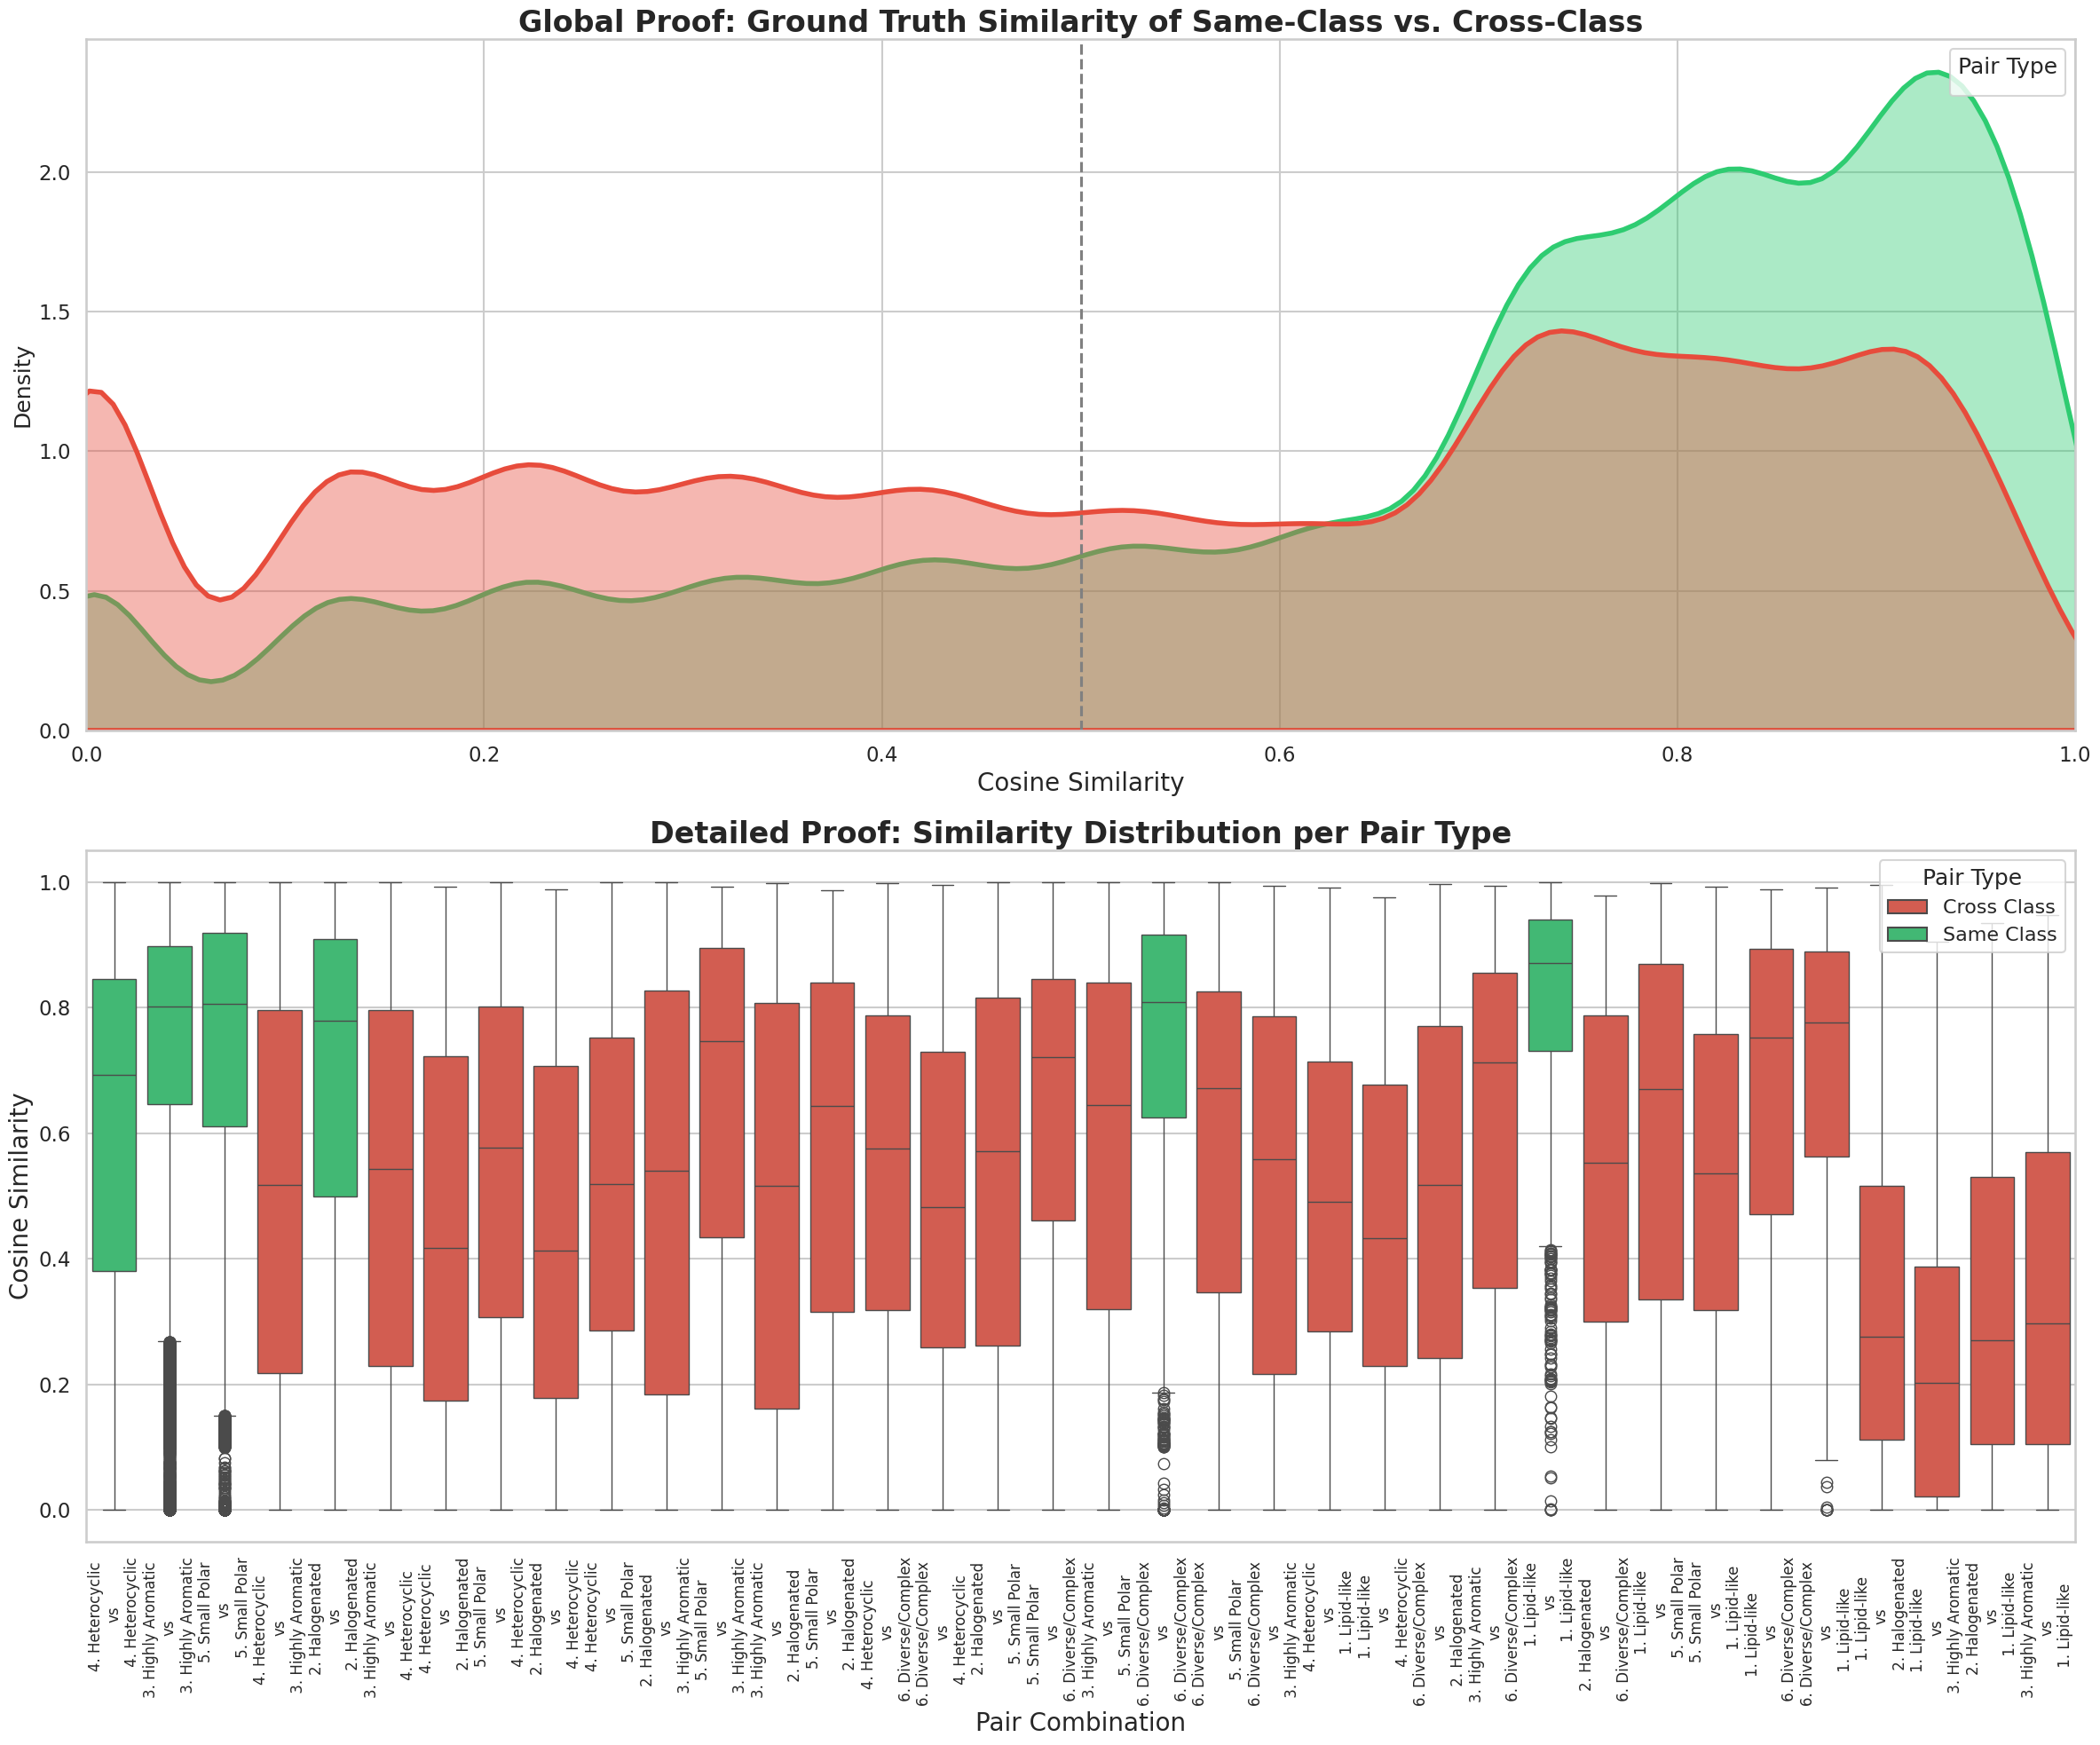

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# Styling for scientific publication quality
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (24, 12) # Wide figure for many bars

# --- 1. FILE PATHS ---
TRAIN_PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train.feather"
MOL_DF_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df.pkl"
SPEC_META_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

# --- 2. LOAD DATA ---
print("Loading Metadata...")
df_mols = pd.read_pickle(MOL_DF_PATH)
df_spec_bridge = pd.read_pickle(SPEC_META_PATH)
df_train = pd.read_feather(TRAIN_PAIRS_PATH)

# --- 3. DEFINE CHEMICAL CLASSIFIER ---
def get_chemical_class(mol):
    if not mol: return "Unknown"
    num_rings = rdMolDescriptors.CalcNumRings(mol)
    num_arom = rdMolDescriptors.CalcNumAromaticRings(mol)
    num_rotatable = rdMolDescriptors.CalcNumRotatableBonds(mol)
    has_halogen = any(atom.GetAtomicNum() in [9, 17, 35, 53] for atom in mol.GetAtoms())
    num_heteroatoms = rdMolDescriptors.CalcNumHeteroatoms(mol)
    mw = rdMolDescriptors.CalcExactMolWt(mol)
    
    if num_rotatable > 12 and num_arom <= 1: return "1. Lipid-like"
    elif has_halogen: return "2. Halogenated"
    elif num_arom >= 3: return "3. Highly Aromatic"
    elif num_rings >= 2 and num_heteroatoms >= 2: return "4. Heterocyclic"
    elif mw < 250: return "5. Small Polar"
    else: return "6. Diverse/Complex"

print("Classifying molecules...")
if 'Chemical_Class' not in df_mols.columns:
    df_mols['Chemical_Class'] = df_mols['mol'].apply(get_chemical_class)

# --- 4. CLASSIFY PAIRS ---
def classify_pairs(pairs_df, mol_df, spec_bridge):
    def merge_col(df, col_name, suffix):
        step1 = df.merge(
            spec_bridge[['spec_id', 'mol_id']], 
            left_on=col_name, right_on='spec_id', how='left'
        ).drop(columns=['spec_id'])
        step2 = step1.merge(
            mol_df[['mol_id', 'Chemical_Class']], 
            on='mol_id', how='left'
        ).rename(columns={'Chemical_Class': f'Class_{suffix}'}).drop(columns=['mol_id'])
        return step2

    print("Linking Side A...")
    df_A = merge_col(pairs_df, 'name_main', 'Main')
    print("Linking Side B...")
    df_final = merge_col(df_A, 'name_sub', 'Sub')
    
    df_final['Pair_Type'] = np.where(
        df_final['Class_Main'] == df_final['Class_Sub'], 
        "Same Class", 
        "Cross Class"
    )
    return df_final

print("Classifying pairs (this may take a moment)...")
df_analyzed = classify_pairs(df_train, df_mols, df_spec_bridge)

# Create Label
df_analyzed['Pair_Combo'] = df_analyzed.apply(
    lambda x: f"{x['Class_Main']} \nvs\n {x['Class_Sub']}", axis=1
)

# Filter
df_clean = df_analyzed.dropna(subset=['Class_Main', 'Class_Sub', 'cosine_similarity'])
df_clean = df_clean[
    (~df_clean['Class_Main'].astype(str).str.contains("Unknown")) & 
    (~df_clean['Class_Sub'].astype(str).str.contains("Unknown"))
]

# --- 5. PLOT A: HISTOGRAM OF *ALL* PAIR TYPES ---
# Get counts for ALL combinations
combo_counts = df_clean['Pair_Combo'].value_counts()
combo_order = combo_counts.index

# Define Colors
is_same_class = [
    "Same Class" if x.split(" \nvs\n ")[0] == x.split(" \nvs\n ")[1] else "Cross Class" 
    for x in combo_order
]
palette_map = {"Same Class": "#2ecc71", "Cross Class": "#e74c3c"}

plt.figure(figsize=(24, 10))
sns.barplot(
    x=combo_order, 
    y=combo_counts.values, 
    hue=is_same_class, 
    palette=palette_map,
    dodge=False
)

plt.title(f"Distribution of ALL {len(combo_order)} Pair Combinations in Training Set", fontsize=24, fontweight='bold')
plt.ylabel("Number of Pairs", fontsize=20)
plt.xlabel("Pair Combination", fontsize=20)
plt.xticks(rotation=90, ha='center', fontsize=12) # Vertical labels to fit everything
plt.legend(title="Relationship Type", fontsize=16)

# Add counts
ax = plt.gca()
for i, p in enumerate(ax.patches):
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, rotation=90, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


# --- 6. PLOT B: THE "PROOF" (Similarity Distributions) ---
fig, axes = plt.subplots(2, 1, figsize=(24, 20))

# Density Plot (The "Smoking Gun")
sns.kdeplot(
    data=df_clean, 
    x="cosine_similarity", 
    hue="Pair_Type", 
    fill=True, 
    common_norm=False, 
    palette={"Same Class": "#2ecc71", "Cross Class": "#e74c3c"},
    alpha=0.4, 
    linewidth=4,
    ax=axes[0]
)
axes[0].set_title("Global Proof: Ground Truth Similarity of Same-Class vs. Cross-Class", fontsize=24, fontweight='bold')
axes[0].set_xlabel("Cosine Similarity", fontsize=20)
axes[0].set_xlim(0, 1)
axes[0].axvline(0.5, color='gray', linestyle='--')
axes[0].legend(title="Pair Type", fontsize=16)

# Boxplot for ALL combinations (Detailed Proof)
sns.boxplot(
    data=df_clean,
    x='Pair_Combo',
    y='cosine_similarity',
    order=combo_order, # Maintain same sorted order as histogram
    hue='Pair_Type',
    palette=palette_map,
    dodge=False,
    ax=axes[1]
)
axes[1].set_title("Detailed Proof: Similarity Distribution per Pair Type", fontsize=24, fontweight='bold')
axes[1].set_xlabel("Pair Combination", fontsize=20)
axes[1].set_ylabel("Cosine Similarity", fontsize=20)
axes[1].set_xticklabels(combo_order, rotation=90, ha='center', fontsize=12)
axes[1].legend(loc='upper right', title="Pair Type", fontsize=16)

plt.tight_layout()
plt.show()

## Inspecting F1-AUC phalacies in mass difference regimes

Total Isomer Pairs in Test Set: 567


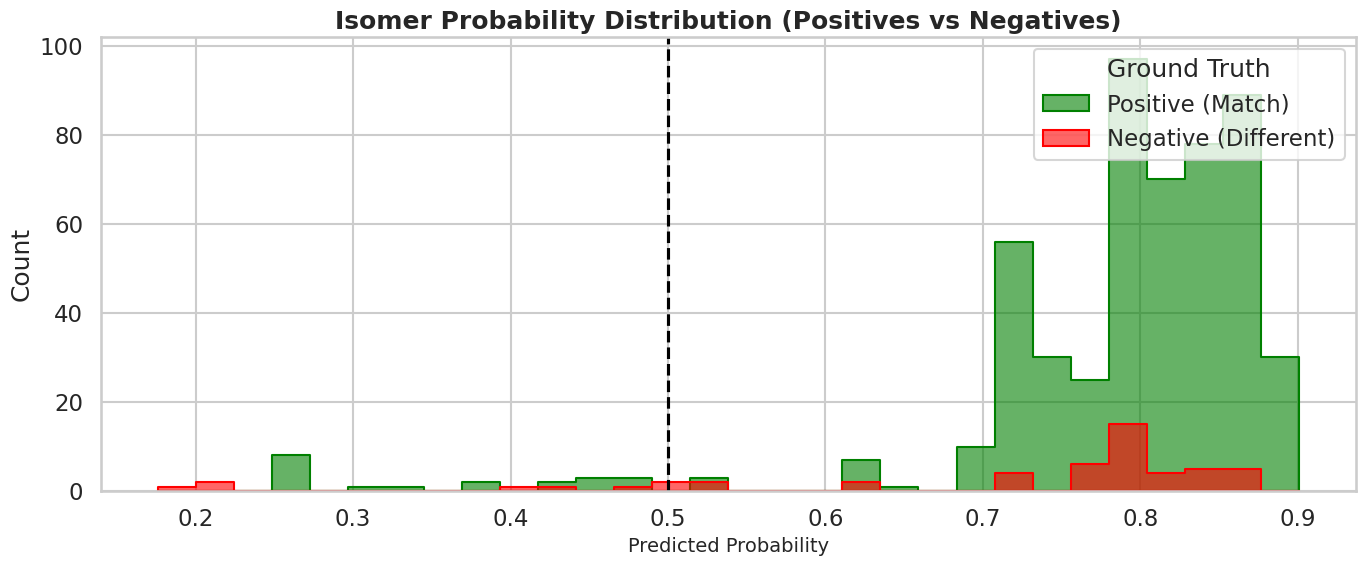

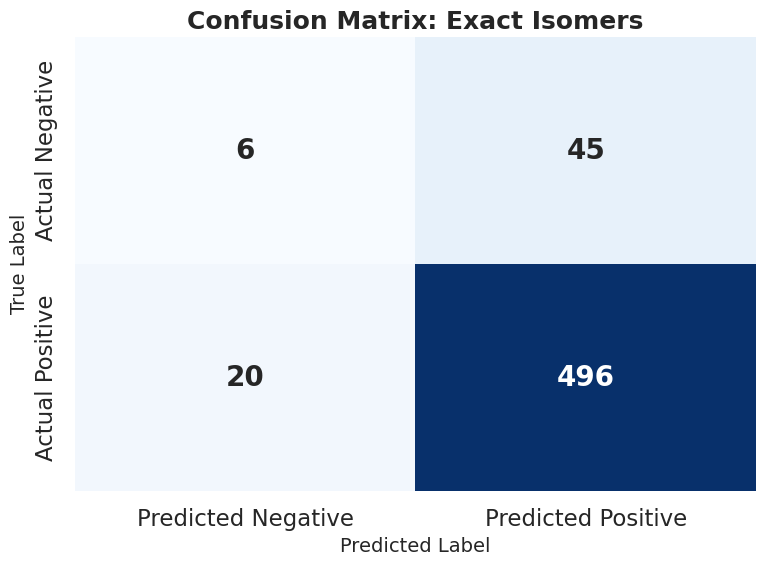


=== DIAGNOSTIC REPORT ===
Precision: 0.917
Recall:    0.961
Avg Prob (Matches):    0.7861
Avg Prob (Non-Matches):0.7140
Separation Gap:        0.0721

>> CRITICAL FINDING: The model has more False Positives than True Negatives.
>> It defaults to saying 'YES' for isomers, causing the low AUC.


In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

# Styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)

# --- 1. PREPARE THE DATA ---
# (Assuming df_test_final is already loaded)
# Define the Isomer Subset (Mass Difference ~ 0)
subset_iso = df_test_final[df_test_final['mass_difference'] < 0.01].copy()

print(f"Total Isomer Pairs in Test Set: {len(subset_iso)}")

# --- 2. PROBABILITY HISTOGRAM ---
plt.figure(figsize=(14, 6))
sns.histplot(
    data=subset_iso,
    x="prob_similarity",
    hue="label",
    element="step",
    bins=30,
    palette={0: "red", 1: "green"},
    alpha=0.6,
    common_norm=False
)
plt.title("Isomer Probability Distribution (Positives vs Negatives)", fontsize=18, fontweight='bold')
plt.xlabel("Predicted Probability", fontsize=14)
plt.axvline(0.5, color='black', linestyle='--', label="Threshold (0.5)")
plt.legend(title="Ground Truth", labels=["Positive (Match)", "Negative (Different)"])
plt.tight_layout()
plt.show()

# --- 3. CONFUSION MATRIX CALCULATION ---
y_true = subset_iso['label']
y_pred = subset_iso['predicted_label']
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# --- 3.5 PLOT CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    cbar=False,
    xticklabels=["Predicted Negative", "Predicted Positive"],
    yticklabels=["Actual Negative", "Actual Positive"],
    annot_kws={"size": 20, "weight": "bold"}
)
plt.title("Confusion Matrix: Exact Isomers", fontsize=18, fontweight='bold')
plt.ylabel("True Label", fontsize=14)
plt.xlabel("Predicted Label", fontsize=14)
plt.tight_layout()
plt.show()

# --- 4. NUMERICAL DIAGNOSIS ---
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

avg_prob_pos = subset_iso[subset_iso['label'] == 1]['prob_similarity'].mean()
avg_prob_neg = subset_iso[subset_iso['label'] == 0]['prob_similarity'].mean()

print("\n=== DIAGNOSTIC REPORT ===")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"Avg Prob (Matches):    {avg_prob_pos:.4f}")
print(f"Avg Prob (Non-Matches):{avg_prob_neg:.4f}")
print(f"Separation Gap:        {avg_prob_pos - avg_prob_neg:.4f}")

if fp > tn:
    print("\n>> CRITICAL FINDING: The model has more False Positives than True Negatives.")
    print(">> It defaults to saying 'YES' for isomers, causing the low AUC.")

Total Huge Diff Pairs in Test Set: 1119


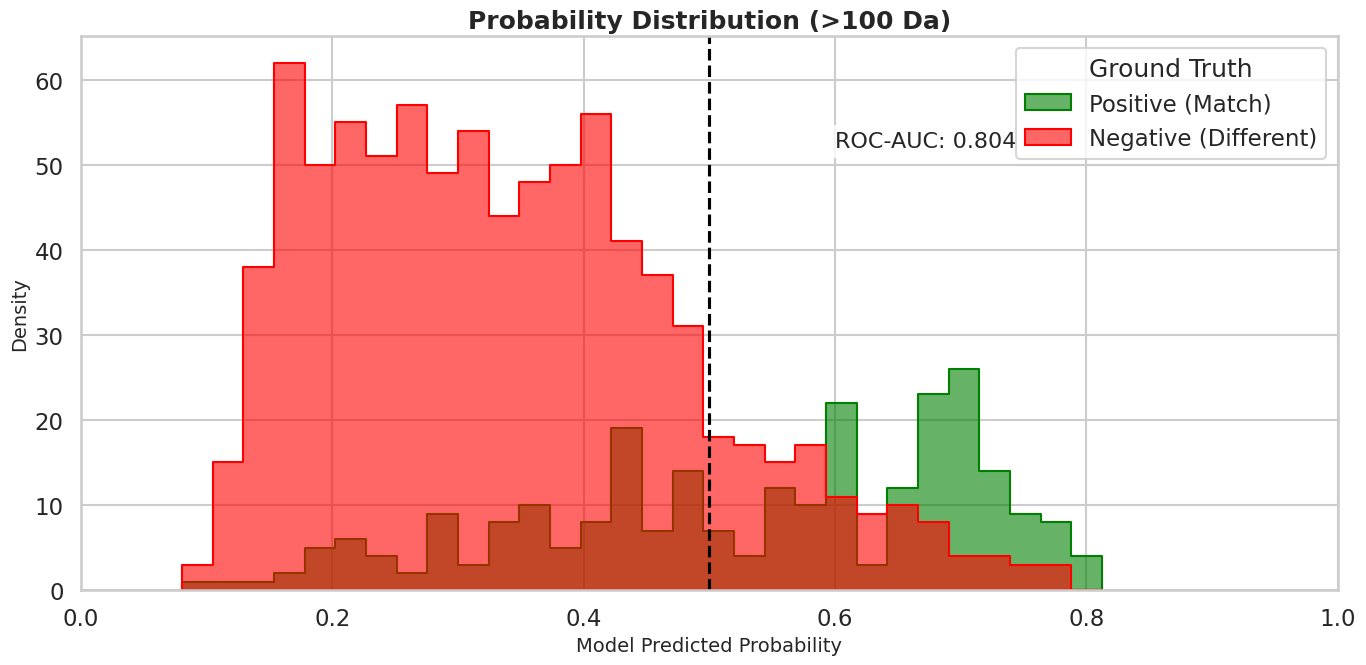

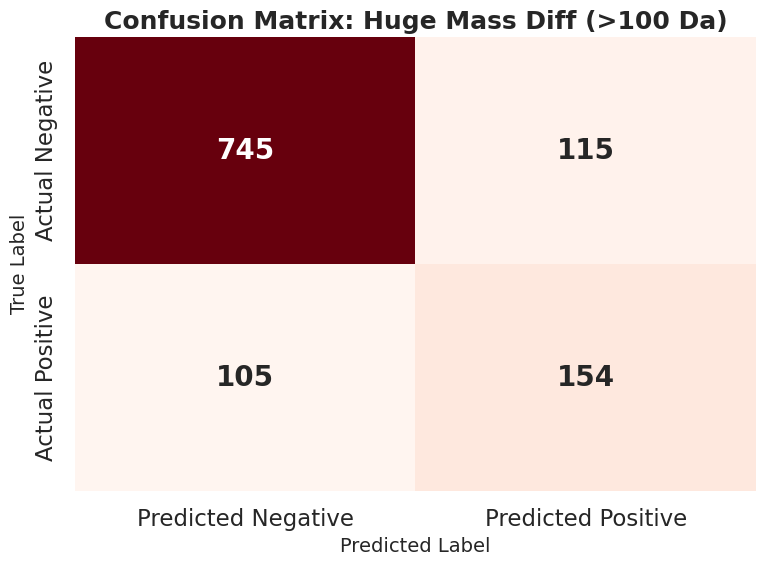


=== DIAGNOSTIC REPORT (HUGE MASS DIFF) ===
Precision: 0.572
Recall:    0.595  <-- This should be LOW (The culprit)
Avg Prob (Matches):    0.5367  <-- Is this < 0.5?
Avg Prob (Non-Matches):0.3399  <-- This should be ~0.0
Separation Gap:        0.1968

>> VERDICT: The model is 'Under-Confident'. True Matches have low scores.
>> Recommendation: Lower the decision threshold for this regime.

=== TOP 5 FALSE NEGATIVES (True Matches the model missed) ===


,name_main,name_sub,prob_similarity,mass_difference
2923,MassSpecGymID0194812,MassSpecGymID0219655,0.103090,184.86922
880,MassSpecGymID0154394,MassSpecGymID0219659,0.119712,142.85866
202,MassSpecGymID0122700,MassSpecGymID0219655,0.130861,216.85905
4666,MassSpecGymID0159109,MassSpecGymID0219655,0.155160,202.87979
2550,MassSpecGymID0222462,MassSpecGymID0229309,0.171831,152.98263


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

# Styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)

# --- 1. PREPARE THE DATA ---
# Define the Huge Mass Subset (> 100 Da)
subset_huge = df_test_final[df_test_final['mass_difference'] > 100.0].copy()

print(f"Total Huge Diff Pairs in Test Set: {len(subset_huge)}")

# --- 2. PROBABILITY HISTOGRAM (The Evidence) ---
plt.figure(figsize=(14, 7))

# Plot Histogram
sns.histplot(
    data=subset_huge,
    x="prob_similarity",
    hue="label",
    element="step",
    bins=30,
    palette={0: "red", 1: "green"},
    alpha=0.6,
    common_norm=False # Crucial to see the shape of the minority Positive class
)

plt.title("Probability Distribution (>100 Da)", fontsize=18, fontweight='bold')
plt.xlabel("Model Predicted Probability", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xlim(0, 1.0)
plt.axvline(0.5, color='black', linestyle='--', label="Decision Threshold (0.5)")
plt.legend(title="Ground Truth", labels=["Positive (Match)", "Negative (Different)"])

# Add Annotation
if len(subset_huge['label'].unique()) > 1:
    auc_score = roc_auc_score(subset_huge['label'], subset_huge['prob_similarity'])
    plt.text(0.6, plt.gca().get_ylim()[1]*0.8, f"ROC-AUC: {auc_score:.3f}", fontsize=16, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# --- 3. CONFUSION MATRIX ---
y_true = subset_huge['label']
y_pred = subset_huge['predicted_label']
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Reds", 
    cbar=False,
    xticklabels=["Predicted Negative", "Predicted Positive"],
    yticklabels=["Actual Negative", "Actual Positive"],
    annot_kws={"size": 20, "weight": "bold"}
)
plt.title("Confusion Matrix: Huge Mass Diff (>100 Da)", fontsize=18, fontweight='bold')
plt.ylabel("True Label", fontsize=14)
plt.xlabel("Predicted Label", fontsize=14)
plt.tight_layout()
plt.show()

# --- 4. NUMERICAL DIAGNOSIS ---
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

avg_prob_pos = subset_huge[subset_huge['label'] == 1]['prob_similarity'].mean()
avg_prob_neg = subset_huge[subset_huge['label'] == 0]['prob_similarity'].mean()

print("\n=== DIAGNOSTIC REPORT (HUGE MASS DIFF) ===")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}  <-- This should be LOW (The culprit)")
print(f"Avg Prob (Matches):    {avg_prob_pos:.4f}  <-- Is this < 0.5?")
print(f"Avg Prob (Non-Matches):{avg_prob_neg:.4f}  <-- This should be ~0.0")
print(f"Separation Gap:        {avg_prob_pos - avg_prob_neg:.4f}")

if avg_prob_pos < 0.6:
    print("\n>> VERDICT: The model is 'Under-Confident'. True Matches have low scores.")
    print(">> Recommendation: Lower the decision threshold for this regime.")

# --- 5. INSPECT THE "FALSE NEGATIVES" (Missed Opportunities) ---
print("\n=== TOP 5 FALSE NEGATIVES (True Matches the model missed) ===")
# These are pairs that ARE similar, but the model gave low scores
false_negatives = subset_huge[(subset_huge['label'] == 1) & (subset_huge['predicted_label'] == 0)]
cols_to_show = ['name_main', 'name_sub', 'prob_similarity', 'mass_difference']
if 'Chemical_Class' in subset_huge.columns: cols_to_show.append('Chemical_Class')

display(false_negatives.sort_values("prob_similarity", ascending=True)[cols_to_show].head(5))

Analyzing 259 True Matches with >100 Da Mass Difference.


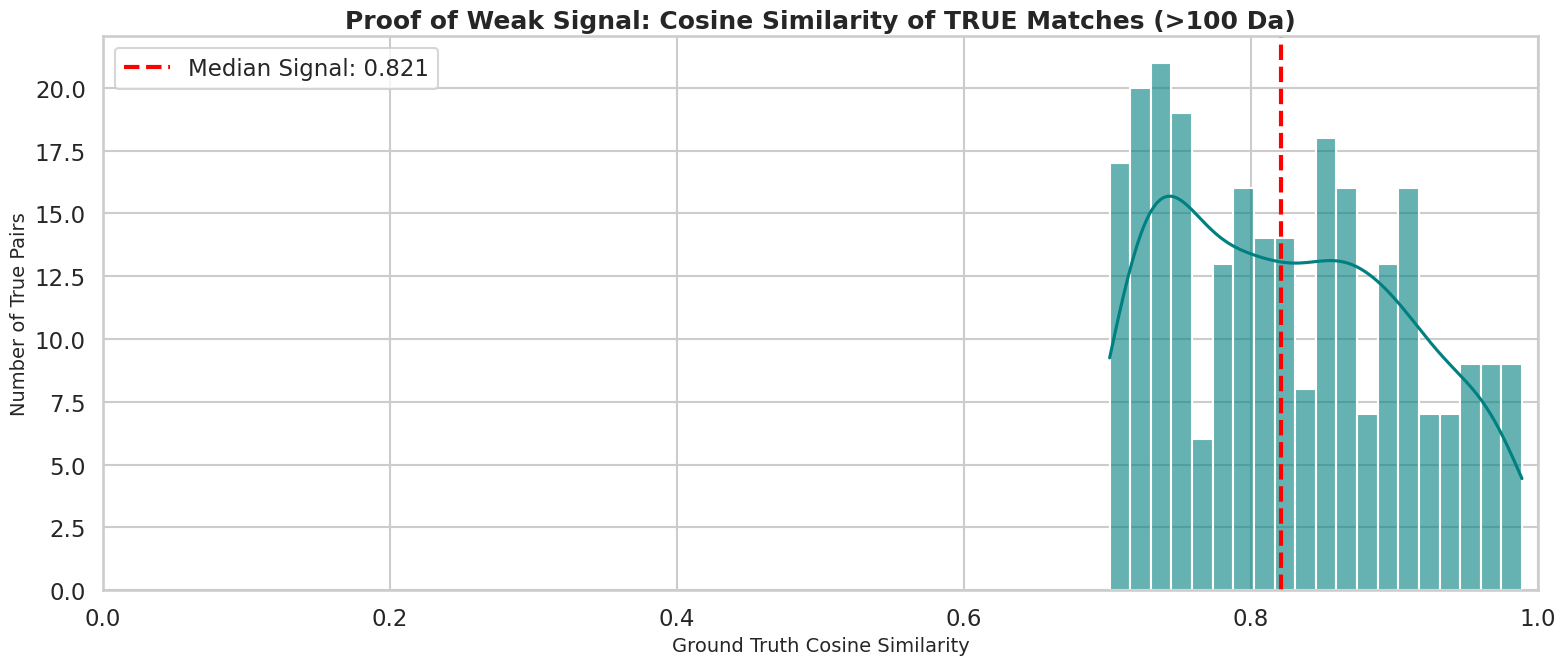

/tmp/ipykernel_2722976/389686513.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_counts.index, y=bin_counts.values, palette="viridis")


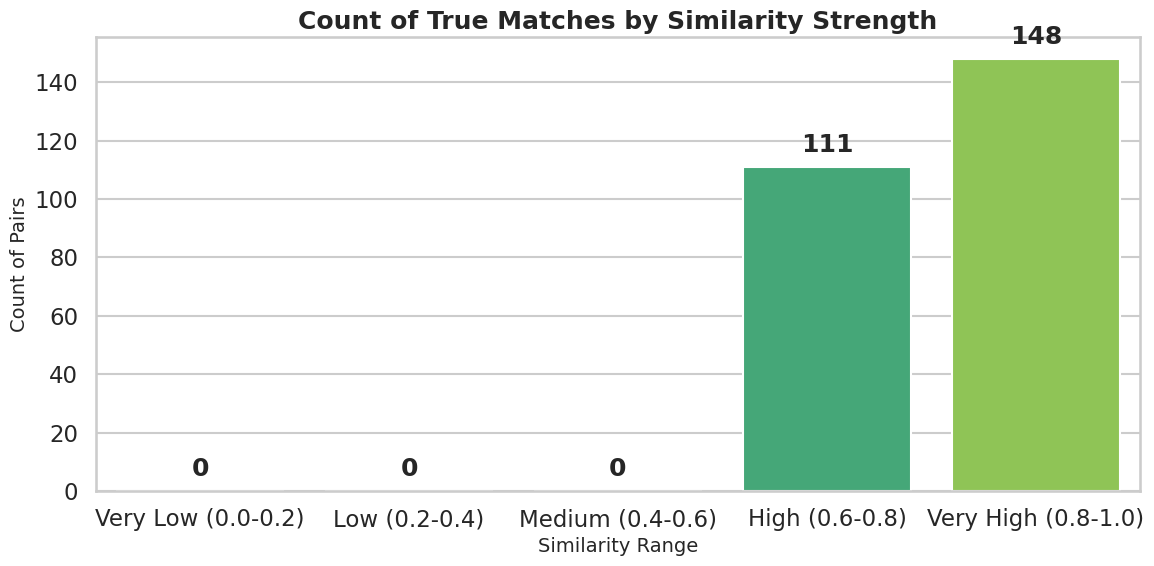


=== SIGNAL STRENGTH STATISTICS ===
Mean Similarity:   0.8263
Median Similarity: 0.8211
Max Similarity:    0.9890

Bin Counts:
Similarity_Bin
Very Low (0.0-0.2)       0
Low (0.2-0.4)            0
Medium (0.4-0.6)         0
High (0.6-0.8)         111
Very High (0.8-1.0)    148
Name: count, dtype: int64


In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)

# --- 1. PREPARE THE DATA ---
# Filter for:
# 1. Huge Mass Difference (> 100 Da)
# 2. True Positives Only (Label == 1)
subset_weak_signal = df_test_final[
    (df_test_final['mass_difference'] > 100.0) & 
    (df_test_final['label'] == 1)
].copy()

print(f"Analyzing {len(subset_weak_signal)} True Matches with >100 Da Mass Difference.")

# --- 2. CREATE BINS FOR DETAILED COUNTS ---
# We bin the similarities to see exactly where the data lies
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['Very Low (0.0-0.2)', 'Low (0.2-0.4)', 'Medium (0.4-0.6)', 'High (0.6-0.8)', 'Very High (0.8-1.0)']
subset_weak_signal['Similarity_Bin'] = pd.cut(subset_weak_signal['cosine_similarity'], bins=bins, labels=labels)

# Calculate counts per bin
bin_counts = subset_weak_signal['Similarity_Bin'].value_counts().sort_index()

# --- 3. PLOT A: THE DISTRIBUTION (HISTOGRAM) ---
plt.figure(figsize=(16, 7))

# Histogram with Kernel Density Estimate (KDE)
sns.histplot(
    data=subset_weak_signal,
    x="cosine_similarity",
    bins=20,
    kde=True,
    color="teal",
    alpha=0.6,
    edgecolor="white"
)

# Mark the median signal strength
median_sim = subset_weak_signal['cosine_similarity'].median()
plt.axvline(median_sim, color='red', linestyle='--', linewidth=3, label=f"Median Signal: {median_sim:.3f}")

plt.title("Proof of Weak Signal: Cosine Similarity of TRUE Matches (>100 Da)", fontsize=18, fontweight='bold')
plt.xlabel("Ground Truth Cosine Similarity", fontsize=14)
plt.ylabel("Number of True Pairs", fontsize=14)
plt.xlim(0, 1.0)
plt.legend()

plt.tight_layout()
plt.show()

# --- 4. PLOT B: BINNED COUNTS (Specific Bins) ---
plt.figure(figsize=(12, 6))
sns.barplot(x=bin_counts.index, y=bin_counts.values, palette="viridis")

plt.title("Count of True Matches by Similarity Strength", fontsize=18, fontweight='bold')
plt.ylabel("Count of Pairs", fontsize=14)
plt.xlabel("Similarity Range", fontsize=14)

# Add counts on top
for i, count in enumerate(bin_counts.values):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# --- 5. PRINT STATISTICS ---
print("\n=== SIGNAL STRENGTH STATISTICS ===")
print(f"Mean Similarity:   {subset_weak_signal['cosine_similarity'].mean():.4f}")
print(f"Median Similarity: {subset_weak_signal['cosine_similarity'].median():.4f}")
print(f"Max Similarity:    {subset_weak_signal['cosine_similarity'].max():.4f}")
print("\nBin Counts:")
print(bin_counts)

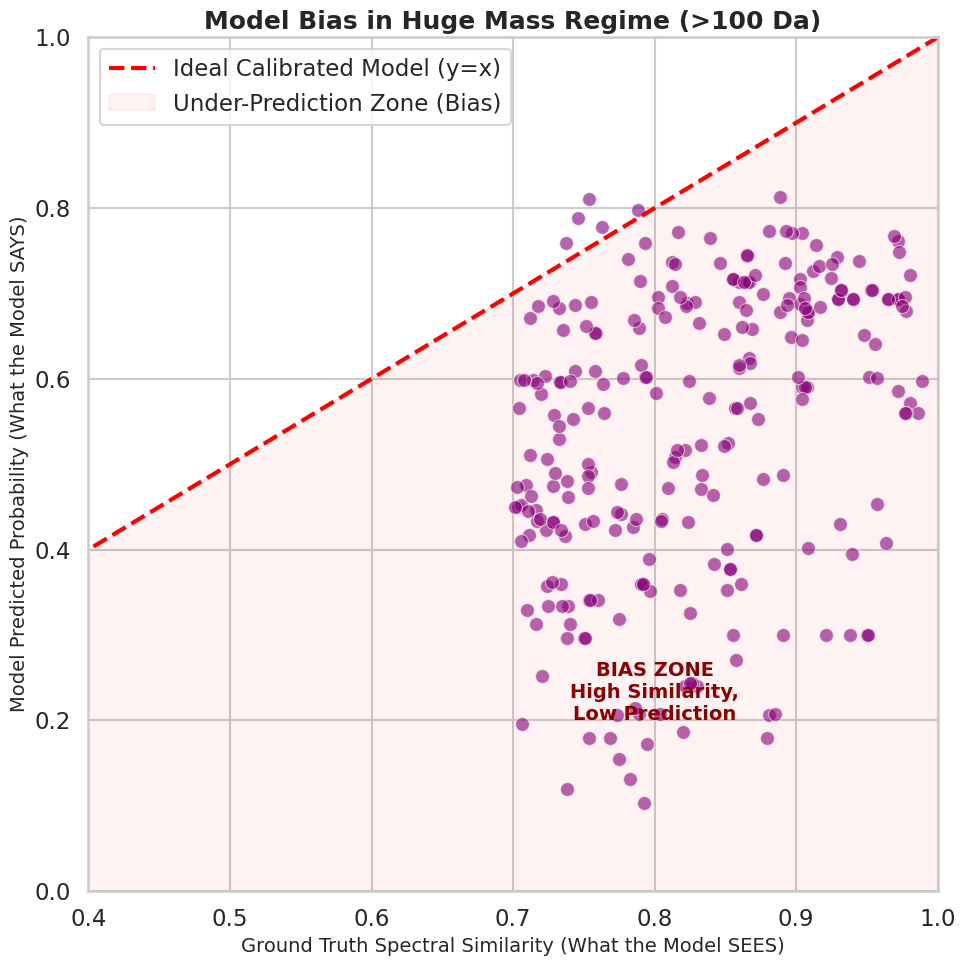


=== BIAS QUANTIFICATION ===
Average Under-Prediction: 0.2896
If this is positive (e.g., +0.3), the model is systematically penalizing these pairs.


In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

# --- 1. PREPARE DATA ---
# Filter for True Matches in the Huge Mass Regime
subset_bias = df_test_final[
    (df_test_final['mass_difference'] > 100.0) & 
    (df_test_final['label'] == 1)
].copy()

# --- 2. THE BIAS PLOT (Scatter) ---
plt.figure(figsize=(10, 10))

# Scatter Plot
sns.scatterplot(
    data=subset_bias,
    x="cosine_similarity",
    y="prob_similarity",
    color="purple",
    s=100,
    alpha=0.6,
    edgecolor="white"
)

# Reference Diagonal Line (Perfect Calibration)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=3, label="Ideal Calibrated Model (y=x)")

# The "Bias Zone"
plt.fill_between([0, 1], [0, 1], 0, color='red', alpha=0.05, label="Under-Prediction Zone (Bias)")

# Formatting
plt.title("Model Bias in Huge Mass Regime (>100 Da)", fontsize=18, fontweight='bold')
plt.xlabel("Ground Truth Spectral Similarity (What the Model SEES)", fontsize=14)
plt.ylabel("Model Predicted Probability (What the Model SAYS)", fontsize=14)
plt.xlim(0.4, 1.0) # Zoom in on the high similarity area
plt.ylim(0, 1.0)
plt.legend(loc='upper left')

# Add Annotations
plt.text(0.8, 0.2, "BIAS ZONE\nHigh Similarity,\nLow Prediction", 
         color='darkred', ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

# --- 3. QUANTIFY THE BIAS ---
subset_bias['Bias_Error'] = subset_bias['cosine_similarity'] - subset_bias['prob_similarity']
avg_bias = subset_bias['Bias_Error'].mean()

print("\n=== BIAS QUANTIFICATION ===")
print(f"Average Under-Prediction: {avg_bias:.4f}")
print("If this is positive (e.g., +0.3), the model is systematically penalizing these pairs.")

In [129]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, f1_score

# --- 1. SETUP ---
# (Assuming df_test_final is loaded and has 'Mass_Regime', 'label', 'prob_similarity')

regime_order = [
    "0. Exact Isomers (0 Da)", 
    "1. Isobaric (< 1 Da)", 
    "2. Tiny (1-10 Da)",
    "3. Medium (10-50 Da)",
    "4. Large (50-100 Da)",
    "5. Huge (>100 Da)"
]

optimization_results = []

print("Optimizing Thresholds (Finding the ROC Shoulder)...")

for regime in regime_order:
    subset = df_test_final[df_test_final['Mass_Regime'] == regime]
    
    if len(subset) > 0:
        y_true = subset['label']
        y_probs = subset['prob_similarity']
        
        # 1. Get ROC Curve Data
        fpr, tpr, thresholds = roc_curve(y_true, y_probs)
        
        # 2. Find the "Shoulder" (Youden's J Statistic)
        # J = Sensitivity (TPR) + Specificity (1-FPR) - 1
        # This maximizes the vertical distance from the random diagonal
        youden_j = tpr - fpr
        best_idx = np.argmax(youden_j)
        optimal_threshold = thresholds[best_idx]
        
        # 3. Calculate F1 at this Optimal Threshold
        y_pred_opt = (y_probs >= optimal_threshold).astype(int)
        f1_opt = f1_score(y_true, y_pred_opt)
        
        # 4. Compare with Default (0.5)
        y_pred_default = (y_probs >= 0.5).astype(int)
        f1_default = f1_score(y_true, y_pred_default)
        
        optimization_results.append({
            "Mass_Regime": regime,
            "Default_F1 (0.5)": f1_default,
            "Shoulder_F1 (Opt)": f1_opt,
            "Optimal_Threshold": optimal_threshold,
            "Improvement": f1_opt - f1_default
        })

# --- 2. DISPLAY RESULTS ---
df_opt = pd.DataFrame(optimization_results)

# Formatting for clarity
print("\n=== PERFORMANCE AT ROC SHOULDER (OPTIMIZED THRESHOLD) ===")
display(df_opt.style.format({
    'Default_F1 (0.5)': '{:.3f}', 
    'Shoulder_F1 (Opt)': '{:.3f}', 
    'Optimal_Threshold': '{:.3f}',
    'Improvement': '{:+.3f}'
}).background_gradient(cmap='Greens', subset=['Shoulder_F1 (Opt)', 'Improvement']))

Optimizing Thresholds (Finding the ROC Shoulder)...

=== PERFORMANCE AT ROC SHOULDER (OPTIMIZED THRESHOLD) ===


,Mass_Regime,Default_F1 (0.5),Shoulder_F1 (Opt),Optimal_Threshold,Improvement
0,0. Exact Isomers (0 Da),0.939,0.741,0.795,-0.197
1,1. Isobaric (< 1 Da),0.375,0.667,0.833,+0.292
2,2. Tiny (1-10 Da),0.789,0.801,0.532,+0.012
3,3. Medium (10-50 Da),0.820,0.779,0.671,-0.041
4,4. Large (50-100 Da),0.719,0.757,0.457,+0.038
5,5. Huge (>100 Da),0.583,0.570,0.423,-0.014


In [130]:
import pandas as pd

# Load your training data
# df_train = pd.read_feather("your_train_path.feather")

# 1. Define Hard Negatives (Isomer Mismatches)
# Criteria: Mass Diff < 0.01 Da AND Label == 0
hard_negatives = df_train_enriched[
    (df_train_enriched['mass_difference'] < 0.01) & 
    (df_train_enriched['label'] == 0)
]

# 2. Define "Easy" Isomers (True Matches) for comparison
true_isomers = df_train_enriched[
    (df_train_enriched['mass_difference'] < 0.01) & 
    (df_train_enriched['label'] == 1)
]

print(f"Total Training Pairs: {len(df_train_enriched)}")
print(f"--- Isomer Statistics ---")
print(f"Hard Negatives (Same Mass, Diff Struct): {len(hard_negatives)}")
print(f"True Matches   (Same Mass, Same Struct): {len(true_isomers)}")

ratio = len(true_isomers) / len(hard_negatives) if len(hard_negatives) > 0 else 0
print(f"Imbalance Ratio: 1 Hard Negative for every {ratio:.1f} True Matches")

Total Training Pairs: 179981
--- Isomer Statistics ---
Hard Negatives (Same Mass, Diff Struct): 1074
True Matches   (Same Mass, Same Struct): 9228
Imbalance Ratio: 1 Hard Negative for every 8.6 True Matches


In [131]:
import pandas as pd
import numpy as np
import os

# --- 1. DEFINE PATHS ---
PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_val.feather"
SPEC_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df.pkl"

# Define output path (automatically adds '_with_mass')
base, ext = os.path.splitext(PAIRS_PATH)
OUTPUT_PATH = f"{base}_with_mass{ext}"

print(f"Processing: {PAIRS_PATH}")
print(f"Output to:  {OUTPUT_PATH}")

# --- 2. LOAD DATA ---
print("Loading dataframes...")
df_pairs = pd.read_feather(PAIRS_PATH)
df_spec = pd.read_pickle(SPEC_PATH)

# --- 3. CREATE MASS LOOKUP ---
print("Creating precursor mass lookup map...")
# Ensure we map spec_id -> prec_mz
if 'spec_id' in df_spec.columns:
    mass_lookup = df_spec.set_index('spec_id')['prec_mz'].to_dict()
else:
    # Fallback if spec_id is already the index
    mass_lookup = df_spec['prec_mz'].to_dict()

# --- 4. MAP MASSES AND CALCULATE DIFFERENCE ---
print("Mapping masses to pairs...")

# Map Mass A
df_pairs['mass_main'] = df_pairs['name_main'].map(mass_lookup)
# Map Mass B
df_pairs['mass_sub'] = df_pairs['name_sub'].map(mass_lookup)

# Drop missing values (crucial validation)
initial_len = len(df_pairs)
df_pairs = df_pairs.dropna(subset=['mass_main', 'mass_sub'])
dropped = initial_len - len(df_pairs)
if dropped > 0:
    print(f"Warning: Dropped {dropped} pairs where spectra metadata was missing.")

# Calculate Absolute Difference
df_pairs['mass_difference'] = (df_pairs['mass_main'] - df_pairs['mass_sub']).abs()

# --- 5. VERIFICATION ---
print("\n--- Validation Sample ---")
# Show a few Isomers (diff < 0.01) to verify logic
isomers = df_pairs[df_pairs['mass_difference'] < 0.01]
print(f"Total Isomers identified: {len(isomers)}")
display(isomers[['name_main', 'name_sub', 'mass_difference', 'label']].head())

# --- 6. SAVE ---
print(f"\nSaving to {OUTPUT_PATH}...")
df_pairs.reset_index(drop=True).to_feather(OUTPUT_PATH)
print("Done! You can now point your DataLoader to this new file.")

Processing: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_val.feather
Output to:  /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_val_with_mass.feather
Loading dataframes...
Creating precursor mass lookup map...
Mapping masses to pairs...

--- Validation Sample ---
Total Isomers identified: 228


,name_main,name_sub,mass_difference,label
58,MassSpecGymID0118859,MassSpecGymID0169790,0.000000,1.0
73,MassSpecGymID0118859,MassSpecGymID0155011,0.002847,0.0
76,MassSpecGymID0021624,MassSpecGymID0206083,0.000000,1.0
77,MassSpecGymID0021621,MassSpecGymID0206083,0.000000,1.0
103,MassSpecGymID0102373,MassSpecGymID0186419,0.000000,1.0



Saving to /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_val_with_mass.feather...
Done! You can now point your DataLoader to this new file.


In [132]:
import pandas as pd

# Load your updated pairs file (ensure it has mass_difference!)
# df_train = pd.read_feather("stratified_binary_07_dataset_train_with_mass.feather")

# 1. Define the Targets
# Target A: Isomer Hard Negatives (The ones causing Low AUC)
target_isomers = df_train_enriched[
    (df_train_enriched['mass_difference'] < 0.01) & 
    (df_train_enriched['label'] == 0)
]

# Target B: Huge Mass Positives (The ones causing Low F1)
# These are the valid matches the model is "afraid" to predict
target_huge = df_train_enriched[
    (df_train_enriched['mass_difference'] > 100.0) & 
    (df_train_enriched['label'] == 1)
]

print(f"Total Training Pairs: {len(df_train_enriched)}")
print("-" * 30)
print(f"Target A (Isomer Negatives):   {len(target_isomers)}")
print(f"Target B (Huge Mass Matches):  {len(target_huge)}")
print("-" * 30)
print(f"Total Huge Mass Pairs: {len(df_train_enriched[df_train_enriched['mass_difference'] > 100.0])}")

Total Training Pairs: 179981
------------------------------
Target A (Isomer Negatives):   1074
Target B (Huge Mass Matches):  30486
------------------------------
Total Huge Mass Pairs: 70984


## Checking Validity of Isomers

In [30]:
# --- 1. LOAD DATA ---
# Load your training or test dataframe (whichever you are analyzing)
df = pd.read_feather(TRAIN_PAIRS_PATH) 
# You also need the molecule strings (SMILES) from your mol_df
mol_df = pd.read_pickle(MOL_META_PATH)
spec_df = pd.read_pickle(SPEC_META_PATH)

In [31]:
print("Checking Data Integrity for Isomer Mismatches...")

# Merge SMILES if not already in dataframe (assuming you have mol_id mapping)
# If your df already has 'smiles_main' and 'smiles_sub', skip this merge block.
if 'smiles_main' not in df.columns:
    # Minimal merge logic
    mol_map = mol_df.set_index('mol_id')['smiles'].to_dict()
    # (You might need to map spec_id -> mol_id first depending on your df structure)
    # For now, let's assume you can get the SMILES for Side A and Side B
    pass

Checking Data Integrity for Isomer Mismatches...


In [32]:
def get_key(mol_id):
    if mol_map[mol_id] is not None:
        return mol_map[mol_id]
    return None

In [33]:
def load_and_enrich_data(df_pairs, spec_meta_df):
    """
    Loads pairs, merges with metadata to get precursor masses, 
    and calculates mass difference.
    """
    
    # Merge to get mol_id for Molecule A (name_main)
    # We only bring in 'spec_id' and 'mol_id' to keep it fast
    print("Merging metadata for Molecule A...")
    df_enriched = df_pairs.merge(
        spec_meta_df[['spec_id', 'mol_id']], 
        left_on='name_main', 
        right_on='spec_id', 
        how='left'
    ).rename(columns={'mol_id': 'mol_id_main'}).drop(columns=['spec_id'])

    df_enriched.dropna(axis=0, subset=(["mol_id_main"]), inplace=True)

    df_enriched['mol_id_main'] = df_enriched['mol_id_main'].astype(int)
    
    # Merge to get mol_id for Molecule B (name_sub)
    print("Merging metadata for Molecule B...")
    df_enriched = df_enriched.merge(
        spec_meta_df[['spec_id', 'mol_id']], 
        left_on='name_sub', 
        right_on='spec_id', 
        how='left'
    ).rename(columns={'mol_id': 'mol_id_sub'}).drop(columns=['spec_id'])

    df_enriched.dropna(axis=0, subset=(["mol_id_sub"]), inplace=True)

    df_enriched['mol_id_sub'] = df_enriched['mol_id_sub'].astype(int)
    
    # # Calculate Smiles string main
    df_enriched['smiles_main'] = df_enriched['mol_id_main'].apply(get_key)

    # # Calculate Smiles string sub
    df_enriched["smiles_sub"] =df_enriched["mol_id_sub"].apply(get_key)
    
    # # # Safety Check for missing masses
    # missing = df_enriched['mass_difference'].isna().sum()
    # if missing > 0:
    #     print(f"WARNING: {missing} records are missing precursor mass info.")
        
    return df_enriched

In [34]:
df_train_smiles_enriched = load_and_enrich_data(df_train_enriched, spec_df)

Merging metadata for Molecule A...
Merging metadata for Molecule B...


In [35]:
df_train_smiles_enriched.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,mass_difference,Mass_Regime,Regime_Norm,prec_mz_main,prec_mz_sub,mol_id_main,mol_id_sub,smiles_main,smiles_sub
0,MassSpecGymID0044900,MassSpecGymID0045779,0.600000,1.000000,1,0.00000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),285.02080,285.02080,23783,23779,Nc1ccc(S(=O)(=O)Nc2cncc(Cl)n2)cc1,Nc1ccc(S(=O)(=O)Nc2ccc(Cl)nn2)cc1
1,MassSpecGymID0211156,MassSpecGymID0227499,0.144737,0.617272,0,99.13311,4. Large (50-100 Da),4. Large (50-100 Da),330.08416,429.21727,19529,24532,CSc1nc(C)cc(-n2cnc(SCc3ccccc3)n2)n1,O=C(COc1ccc(C(=O)c2ccccc2)cc1)NC1CCN(Cc2ccccc2...
2,MassSpecGymID0054792,MassSpecGymID0213492,0.103896,0.124546,0,156.97780,5. Huge (>100 Da),5. Huge (>100 Da),268.16959,425.14739,27323,11835,OC(c1ccccc1)(c1ccccc1)C1CCNCC1,CCOc1cc(C2NC(=O)N(C)C(C)=C2C(=O)OCC2CCCO2)cc(C...
3,MassSpecGymID0047622,MassSpecGymID0051408,0.022727,0.591389,0,86.90360,4. Large (50-100 Da),4. Large (50-100 Da),229.06260,142.15900,20390,4926,Cc1cc(Cl)ccc1OCCCC(=O)O,CC1(C)CCCC(C)(C)N1
4,MassSpecGymID0191021,MassSpecGymID0229058,0.078431,0.201028,0,17.02924,3. Medium (10-50 Da),3. Medium (10-50 Da),418.25880,401.22956,5402,18043,CC1=CC2C=C(C)C(C)C3C(CC(C)C)NC(=O)C23C(=O)C2OC...,COc1ccc(CNc2nc(N(CCO)CCO)nc3c2ncn3C(C)C)cc1


In [36]:
# --- 2. ISOLATE THE SUSPECTS ---
# We want: Mass Diff ~ 0 AND Label = 0 (The pairs the model struggles with)
suspects = df_train_smiles_enriched[
    (df_train_enriched['mass_difference'] < 0.01)
].copy()
print(f"Analyzing {len(suspects)} Isomer Mismatch Pairs...")

Analyzing 10302 Isomer Mismatch Pairs...


In [37]:
suspects.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,mass_difference,Mass_Regime,Regime_Norm,prec_mz_main,prec_mz_sub,mol_id_main,mol_id_sub,smiles_main,smiles_sub
0,MassSpecGymID0044900,MassSpecGymID0045779,0.600000,1.000000,1,0.000000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),285.020800,285.020800,23783,23779,Nc1ccc(S(=O)(=O)Nc2cncc(Cl)n2)cc1,Nc1ccc(S(=O)(=O)Nc2ccc(Cl)nn2)cc1
12,MassSpecGymID0058884,MassSpecGymID0092666,0.194444,0.813732,1,0.000038,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),138.055000,138.054962,23236,19622,NC(=O)c1ccccc1O,C[n+]1cccc(C(=O)[O-])c1
62,MassSpecGymID0129823,MassSpecGymID0179033,0.200000,0.863279,1,0.000000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),138.054962,138.054962,23748,14484,Nc1ccc(C(=O)O)cc1,COC(=O)c1cccnc1
67,MassSpecGymID0052694,MassSpecGymID0069523,0.516129,0.990260,1,0.000000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),230.116700,230.116700,3691,11221,CC(C)Nc1nc(Cl)nc(NC(C)C)n1,CCNc1nc(Cl)nc(NC(C)CC)n1
86,MassSpecGymID0217584,MassSpecGymID0217946,0.729730,0.912654,1,0.000000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),475.186360,475.186360,19981,20594,Cc1c(OCC(=O)NC(Cc2c[nH]c3ccccc23)C(=O)O)ccc2c3...,Cc1cc(OCC(=O)NC(Cc2c[nH]c3ccccc23)C(=O)O)c2c3c...


In [38]:
# --- 3. CHECK STRUCTURAL IDENTITY ---
def check_identity(row):
    # Get SMILES (adjust column names as needed)
    smi_a = row['smiles_main'] 
    smi_b = row['smiles_sub']
    
    # 1. Canonicalize SMILES to ensure fair string comparison
    mol_a = Chem.MolFromSmiles(smi_a)
    mol_b = Chem.MolFromSmiles(smi_b)
    
    if mol_a is None or mol_b is None: return "Invalid_SMILES"
    
    can_a = Chem.MolToSmiles(mol_a, isomericSmiles=True) # Check full stereochemistry
    can_b = Chem.MolToSmiles(mol_b, isomericSmiles=True)
    
    # 2. Check InChIKey (The Gold Standard)
    # The first 14 chars (the "Skeleton") must be different for structural isomers
    key_a = Chem.MolToInchiKey(mol_a)
    key_b = Chem.MolToInchiKey(mol_b)
    
    if key_a == key_b:
        return "Identical (Duplicate)"
    elif key_a.split('-')[0] == key_b.split('-')[0]:
        return "Stereoisomers (Same Skeleton)"
    else:
        return "True Structural Isomers"

In [39]:
suspects["identity_check"] = suspects.apply(check_identity, axis=1)

In [40]:
suspects.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,mass_difference,Mass_Regime,Regime_Norm,prec_mz_main,prec_mz_sub,mol_id_main,mol_id_sub,smiles_main,smiles_sub,identity_check
0,MassSpecGymID0044900,MassSpecGymID0045779,0.600000,1.000000,1,0.000000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),285.020800,285.020800,23783,23779,Nc1ccc(S(=O)(=O)Nc2cncc(Cl)n2)cc1,Nc1ccc(S(=O)(=O)Nc2ccc(Cl)nn2)cc1,True Structural Isomers
12,MassSpecGymID0058884,MassSpecGymID0092666,0.194444,0.813732,1,0.000038,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),138.055000,138.054962,23236,19622,NC(=O)c1ccccc1O,C[n+]1cccc(C(=O)[O-])c1,True Structural Isomers
62,MassSpecGymID0129823,MassSpecGymID0179033,0.200000,0.863279,1,0.000000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),138.054962,138.054962,23748,14484,Nc1ccc(C(=O)O)cc1,COC(=O)c1cccnc1,True Structural Isomers
67,MassSpecGymID0052694,MassSpecGymID0069523,0.516129,0.990260,1,0.000000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),230.116700,230.116700,3691,11221,CC(C)Nc1nc(Cl)nc(NC(C)C)n1,CCNc1nc(Cl)nc(NC(C)CC)n1,True Structural Isomers
86,MassSpecGymID0217584,MassSpecGymID0217946,0.729730,0.912654,1,0.000000,0. Exact Isomers (0 Da),0. Exact Isomers (0 Da),475.186360,475.186360,19981,20594,Cc1c(OCC(=O)NC(Cc2c[nH]c3ccccc23)C(=O)O)ccc2c3...,Cc1cc(OCC(=O)NC(Cc2c[nH]c3ccccc23)C(=O)O)c2c3c...,True Structural Isomers


In [41]:
# --- 4. REPORT RESULTS ---
print("\n=== DATA INTEGRITY REPORT ===")
print(suspects['identity_check'].value_counts())


=== DATA INTEGRITY REPORT ===
identity_check
True Structural Isomers    10280
Identical (Duplicate)         22
Name: count, dtype: int64


## Clean duplicate pairs

In [37]:
import pandas as pd
from rdkit import Chem
from tqdm import tqdm

In [40]:
# --- CONFIGURATION ---
# 1. Input: Your current "best" training set
INPUT_TRAIN = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/mass_gate_2_percent/temp_subset_0.02_stratified_binary_07_spec_sim_dataset_train.feather"
# 2. Output: The clean version
OUTPUT_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/mass_gate_2_percent/temp_subset_0.02_stratified_binary_07_spec_sim_dataset_train_NO_DUPLICATES.feather"

# Metadata Paths
MOL_META_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/mol_df_spec_sim.pkl"
SPEC_META_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl"

In [41]:
# --- 1. LOAD DATA ---
print(f"Loading Dataset: {INPUT_TRAIN}...")
df = pd.read_feather(INPUT_TRAIN)
initial_len = len(df)
print(f"Initial Size: {initial_len}")

print("Loading Metadata...")
mol_df = pd.read_pickle(MOL_META_PATH)
spec_df = pd.read_pickle(SPEC_META_PATH)

Loading Dataset: /data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/mass_gate_2_percent/temp_subset_0.02_stratified_binary_07_spec_sim_dataset_train.feather...
Initial Size: 2621400
Loading Metadata...


In [42]:
# Create Fast Lookups
print("Building Lookups...")
# Map spec_id -> mol_id
spec2mol = dict(zip(spec_df['spec_id'], spec_df['mol_id']))
# Map mol_id -> SMILES
mol2smiles = dict(zip(mol_df['mol_id'], mol_df['smiles']))

Building Lookups...


In [43]:
# --- 2. IDENTIFY DUPLICATES ---
print("\n--- Scanning Isomer Bin for Duplicates ---")

# Helper function to get InChIKey
def get_inchikey(smiles):
    if not smiles: return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToInchiKey(mol)
    except:
        return None
    return None

indices_to_drop = []


--- Scanning Isomer Bin for Duplicates ---


In [44]:
# We only strictly check pairs with very small mass differences (Isomers)
# Checking the whole dataset is safer but slower; let's target the problem area first.
# If you want to check EVERYTHING, remove the 'mask' filter.
mask = df['mass_difference'] < 0.01 if 'mass_difference' in df.columns else [True] * len(df)
subset_to_check = df[mask]

print(f"Checking {len(subset_to_check)} candidate pairs...")

for idx, row in tqdm(subset_to_check.iterrows(), total=len(subset_to_check)):
    # 1. Get Spec IDs
    id_a = row['name_main']
    id_b = row['name_sub']
    
    # 2. Get Mol IDs
    mol_a = spec2mol.get(id_a)
    mol_b = spec2mol.get(id_b)
    
    # 3. Get SMILES
    smi_a = mol2smiles.get(mol_a)
    smi_b = mol2smiles.get(mol_b)
    
    # 4. Compare Identity
    # Fast string check first (if SMILES strings are exact match, it's a duplicate)
    if smi_a == smi_b:
        indices_to_drop.append(idx)
        continue
        
    # Rigorous InChIKey check (catches different SMILES strings for same molecule)
    key_a = get_inchikey(smi_a)
    key_b = get_inchikey(smi_b)
    
    if key_a and key_b and key_a == key_b:
        indices_to_drop.append(idx)

Checking 2621400 candidate pairs...


100%|██████████| 2621400/2621400 [44:07<00:00, 990.10it/s] 


In [33]:
identical_mols = suspects[suspects["identity_check"] == "Identical (Duplicate)"]

In [34]:
print(f"---Identical Molecules Report--")
print(f"The average cosine similarity for identical molecules: ")
print(identical_mols["cosine_similarity"].mean())
print()
print(f"Distribution of labels for identical molecules:")
identical_mols["label"].value_counts()

---Identical Molecules Report--
The average cosine similarity for identical molecules: 
0.435733372278204

Distribution of labels for identical molecules:


label
8.315280e-07    15
9.975274e-01     3
9.975172e-01     2
3.706936e-04     1
1.062457e-02     1
                ..
2.162810e-02     1
1.024496e-02     1
1.519813e-04     1
1.712417e-02     1
4.719329e-02     1
Name: count, Length: 1205, dtype: int64

In [35]:
true_structural_isomers = suspects[suspects["identity_check"] == "True Structural Isomers"]

In [36]:
print(f"---True Structural Report--")
print(f"The average cosine similarity for true structural isomers: ")
print(true_structural_isomers["cosine_similarity"].mean())
print()
print(f"Distribution of labels for true structural isomers:")
true_structural_isomers["label"].value_counts()

---True Structural Report--
The average cosine similarity for true structural isomers: 
0.7199666133548714

Distribution of labels for true structural isomers:


label
9.975274e-01    121
8.315280e-07     27
9.648857e-01      3
9.972541e-01      3
9.953688e-01      2
               ... 
9.905115e-01      1
2.915878e-02      1
5.731744e-03      1
1.072435e-02      1
1.803917e-04      1
Name: count, Length: 5111, dtype: int64

In [52]:
df_test_final.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,prec_mz_main,prec_mz_sub,mass_difference,predicted_label,prob_similarity,Mass_Regime
0,MassSpecGymID0003031,MassSpecGymID0049401,0.432432,0.706041,1.0,495.26590,411.17200,84.09390,1.0,0.594271,4. Large (50-100 Da)
1,MassSpecGymID0223776,MassSpecGymID0237961,0.175676,0.648690,0.0,534.08809,280.14444,253.94365,0.0,0.314636,5. Huge (>100 Da)
2,MassSpecGymID0224062,MassSpecGymID0234208,0.089109,0.122628,0.0,412.21185,483.20134,70.98949,0.0,0.318980,4. Large (50-100 Da)
3,MassSpecGymID0003081,MassSpecGymID0060725,0.439024,0.773729,1.0,363.17200,293.09370,70.07830,1.0,0.716457,4. Large (50-100 Da)
4,MassSpecGymID0148794,MassSpecGymID0159098,0.403846,0.449861,0.0,245.11720,259.09650,13.97930,1.0,0.510835,3. Medium (10-50 Da)


In [53]:
df_test_final[(df_test_final["label"] == 0) & (df_test_final["Mass_Regime"] == "0. Exact Isomers (0 Da)")]["label"].count()

51

## Analyze Performance of model in the grey zone

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
LOWER_BOUND = 0.5
UPPER_BOUND = 0.8
REGIME_ORDER = ["0. Exact Isomers", "1. Isobaric", "2. Tiny", "3. Medium", "4. Large", "5. Huge"]

In [135]:
TRAIN_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_train.feather"

In [136]:
# --- 2. LOAD & FILTER ---
print("Loading Training Data...")
df_train = pd.read_feather(TRAIN_PATH)

# Filter for Grey Zone
train_grey = df_train[
    (df_train['cosine_similarity'] >= LOWER_BOUND) & 
    (df_train['cosine_similarity'] <= UPPER_BOUND)
].copy()
train_grey['Dataset'] = 'Training Set'

test_grey = df_test_final[
    (df_test_final['cosine_similarity'] >= LOWER_BOUND) & 
    (df_test_final['cosine_similarity'] <= UPPER_BOUND)
].copy()
test_grey['Dataset'] = 'Test Set'

Loading Training Data...


In [137]:
# Combine for easier plotting
combined_df = pd.concat([train_grey, test_grey], axis=0)

In [138]:
def get_stats(df, name):
    return {
        "Dataset": name,
        "Count": len(df),
        "Mean Similarity": df['cosine_similarity'].mean(),
        "Median Similarity": df['cosine_similarity'].median(),
        "Std Dev": df['cosine_similarity'].std(),
        "Skewness": df['cosine_similarity'].skew()
    }

stats_df = pd.DataFrame([
    get_stats(train_grey, "Training Set"),
    get_stats(test_grey, "Test Set")
])

In [139]:
print("\n=== GREY ZONE STATISTICS ({LOWER_BOUND} - {UPPER_BOUND}) ===")
display(stats_df.style.format({
    "Mean Similarity": "{:.4f}", 
    "Median Similarity": "{:.4f}", 
    "Std Dev": "{:.4f}",
    "Skewness": "{:.3f}"
}))


=== GREY ZONE STATISTICS ({LOWER_BOUND} - {UPPER_BOUND}) ===


,Dataset,Count,Mean Similarity,Median Similarity,Std Dev,Skewness
0,Training Set,55166,0.6762,0.7049,0.0873,-0.505
1,Test Set,1383,0.6709,0.6987,0.0892,-0.416


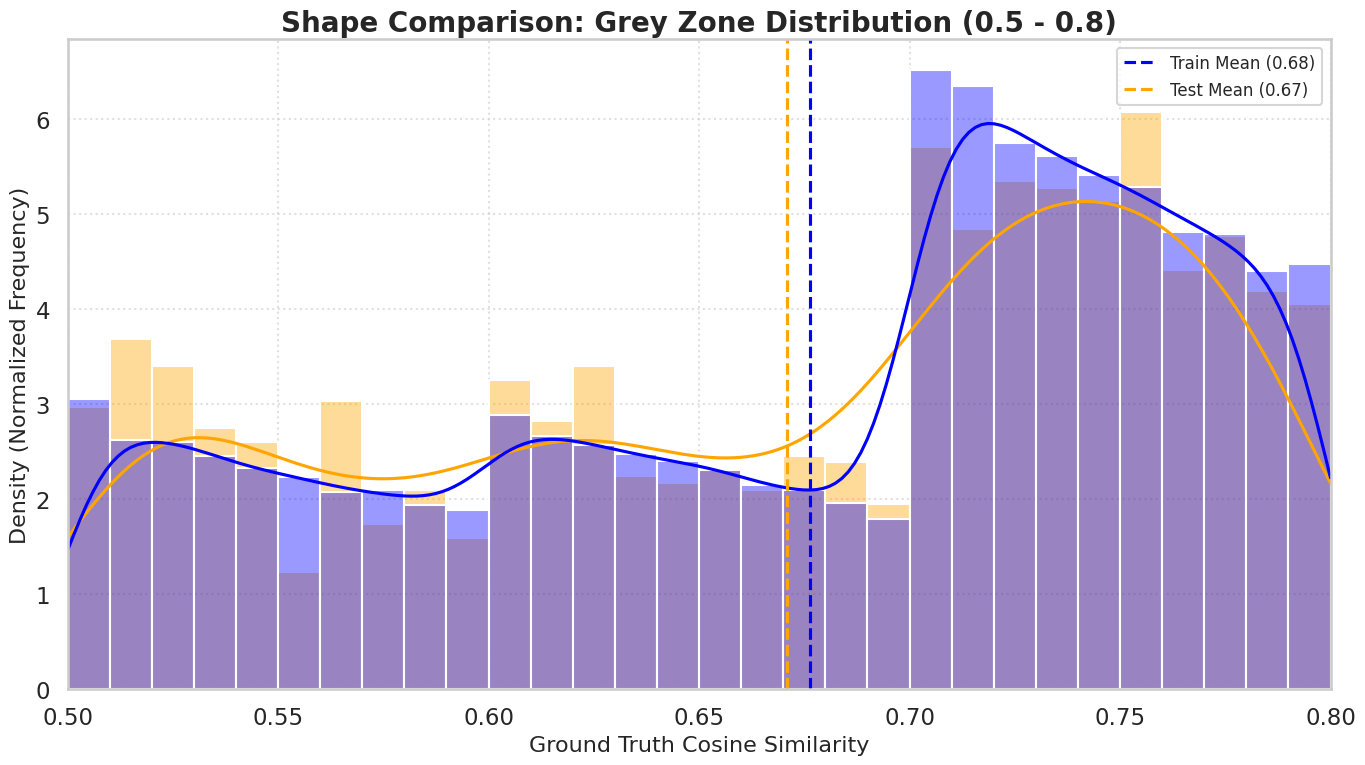

In [140]:
# --- 4. VISUALIZATION ---
plt.figure(figsize=(14, 8))

# Overlay Histograms (Normalized)
# We use stat="density" because Train is much bigger than Test.
# This makes the curves comparable.
sns.histplot(
    data=combined_df, 
    x='cosine_similarity', 
    hue='Dataset',
    stat="density",       # Normalize to compare shapes
    common_norm=False,    # Calculate density independently for each
    kde=True,             # Show the smooth curve
    bins=30,
    palette={'Training Set': 'blue', 'Test Set': 'orange'},
    alpha=0.4
)

plt.title(f"Shape Comparison: Grey Zone Distribution (0.5 - 0.8)", fontsize=20, fontweight='bold')
plt.xlabel("Ground Truth Cosine Similarity", fontsize=16)
plt.ylabel("Density (Normalized Frequency)", fontsize=16)
plt.xlim(LOWER_BOUND, UPPER_BOUND)
plt.grid(True, linestyle=':', alpha=0.6)

plt.axvline(train_grey['cosine_similarity'].mean(), color='blue', linestyle='--', label=f"Train Mean ({train_grey['cosine_similarity'].mean():.2f})")
plt.axvline(test_grey['cosine_similarity'].mean(), color='orange', linestyle='--', label=f"Test Mean ({test_grey['cosine_similarity'].mean():.2f})")
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

In [142]:
# --- 1. CONFIGURATION ---
# Define the "Grey Zone" (Hard Cases)
LOWER_BOUND = 0.5
UPPER_BOUND = 0.8

# Load Data (Assuming df_test_final is already loaded in your notebook)
# If not, uncomment:
# df_test_final = pd.read_feather("your_results_file.feather")

print(f"=== ANALYZING PERFORMANCE IN THE GREY ZONE ({LOWER_BOUND} <= Similarity <= {UPPER_BOUND}) ===")

=== ANALYZING PERFORMANCE IN THE GREY ZONE (0.5 <= Similarity <= 0.8) ===


In [143]:
# --- 2. FILTER DATA ---
# Select pairs where the GROUND TRUTH similarity is in the boundary zone
mask_grey = (df_test_final['cosine_similarity'] >= LOWER_BOUND) & \
            (df_test_final['cosine_similarity'] <= UPPER_BOUND)

df_grey = df_test_final[mask_grey].copy()

print(f"Total Test Pairs: {len(df_test_final)}")
print(f"Grey Zone Pairs:  {len(df_grey)} ({len(df_grey)/len(df_test_final)*100:.1f}%)")

Total Test Pairs: 4858
Grey Zone Pairs:  1383 (28.5%)


In [144]:
# --- 3. METRICS ---
def get_metrics(df, name):
    if len(df) == 0: return {}
    y_true = df['label']
    y_pred = df['predicted_label']
    y_prob = df['prob_similarity']
    
    return {
        "Regime": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_prob) if len(y_true.unique()) > 1 else np.nan
    }

In [145]:
metrics = get_metrics(df_grey, "Grey Zone (0.5-0.8)")
res_df = pd.DataFrame([metrics])

In [146]:
print("\n--- Performance Metrics ---")
display(res_df.style.background_gradient(cmap='Blues', axis=1))


--- Performance Metrics ---


,Regime,Accuracy,F1 Score,Precision,Recall,AUC
0,Grey Zone (0.5-0.8),0.592914,0.652684,0.567597,0.767779,0.638333


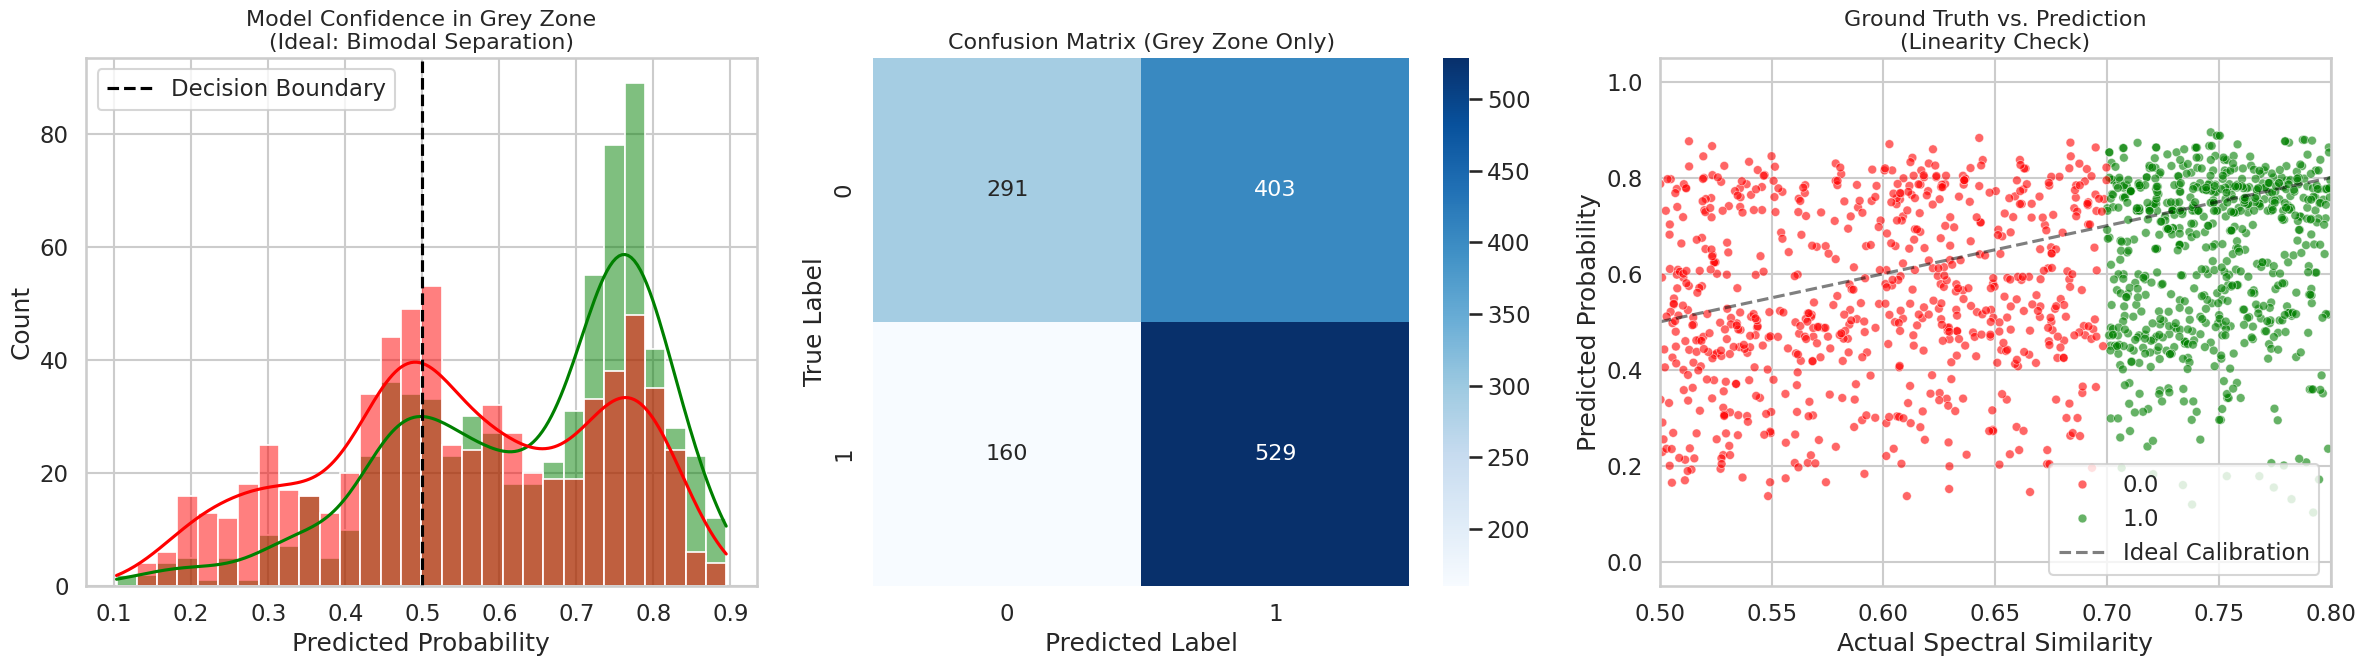

In [147]:
# --- 4. VISUALIZATION ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
# Plot A: Probability Distribution (Are we confident or confused?)
# We want to see if the model can separate Red (0) and Green (1) even in this hard zone.
sns.histplot(
    data=df_grey, 
    x='prob_similarity', 
    hue='label', 
    bins=30, 
    kde=True, 
    ax=axes[0], 
    palette={0:'red', 1:'green'}, 
    alpha=0.5,
    common_norm=False
)
axes[0].set_title(f"Model Confidence in Grey Zone\n(Ideal: Bimodal Separation)", fontsize=16)
axes[0].set_xlabel("Predicted Probability")
axes[0].axvline(0.5, color='black', linestyle='--', label="Decision Boundary")
axes[0].legend()

# Plot B: The Confusion Matrix
cm = confusion_matrix(df_grey['label'], df_grey['predicted_label'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], annot_kws={"size": 16})
axes[1].set_title("Confusion Matrix (Grey Zone Only)", fontsize=16)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

# Plot C: Correlation Plot (Prediction vs Reality)
# We sample 2000 points to avoid overcrowding if the dataset is huge
sample_n = min(2000, len(df_grey))
subset = df_grey.sample(n=sample_n, random_state=42)

sns.scatterplot(
    data=subset, 
    x='cosine_similarity', 
    y='prob_similarity', 
    hue='label', 
    ax=axes[2], 
    palette={0:'red', 1:'green'}, 
    alpha=0.6,
    s=40
)
# Add identity line
axes[2].plot([LOWER_BOUND, UPPER_BOUND], [LOWER_BOUND, UPPER_BOUND], 'k--', alpha=0.5, label="Ideal Calibration")
axes[2].set_title(f"Ground Truth vs. Prediction\n(Linearity Check)", fontsize=16)
axes[2].set_xlabel("Actual Spectral Similarity")
axes[2].set_ylabel("Predicted Probability")
axes[2].set_xlim(LOWER_BOUND, UPPER_BOUND)
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [148]:
# --- 5. FAILURE ANALYSIS: WORST OFFENDERS ---
print("\n--- FAILURE ANALYSIS: WORST OFFENDERS IN GREY ZONE ---")

# Worst False Positives (Label 0, but Predicted > 0.9)
# These are pairs the model was SUPER sure were matches, but weren't.
fps = df_grey[(df_grey['label'] == 0) & (df_grey['prob_similarity'] > 0.9)].sort_values('prob_similarity', ascending=False).head(5)

print(f"Top 5 'Overconfident' False Positives (Ghost Matches):")
if len(fps) > 0:
    cols = ['name_main', 'name_sub', 'mass_difference', 'cosine_similarity', 'prob_similarity']
    display(fps[cols])
else:
    print("None found! (Model is conservative)")

# Worst False Negatives (Label 1, but Predicted < 0.1)
# These are pairs the model was SUPER sure were NOT matches, but were.
fns = df_grey[(df_grey['label'] == 1) & (df_grey['prob_similarity'] < 0.1)].sort_values('prob_similarity', ascending=True).head(5)

print(f"\nTop 5 'Blind' False Negatives (Missed Matches):")
if len(fns) > 0:
    cols = ['name_main', 'name_sub', 'mass_difference', 'cosine_similarity', 'prob_similarity']
    display(fns[cols])
else:
    print("None found! (Model is sensitive)")


--- FAILURE ANALYSIS: WORST OFFENDERS IN GREY ZONE ---
Top 5 'Overconfident' False Positives (Ghost Matches):
None found! (Model is conservative)

Top 5 'Blind' False Negatives (Missed Matches):
None found! (Model is sensitive)


=== ROC ANALYSIS: GREY ZONE (0.5 <= Sim <= 0.8) ===


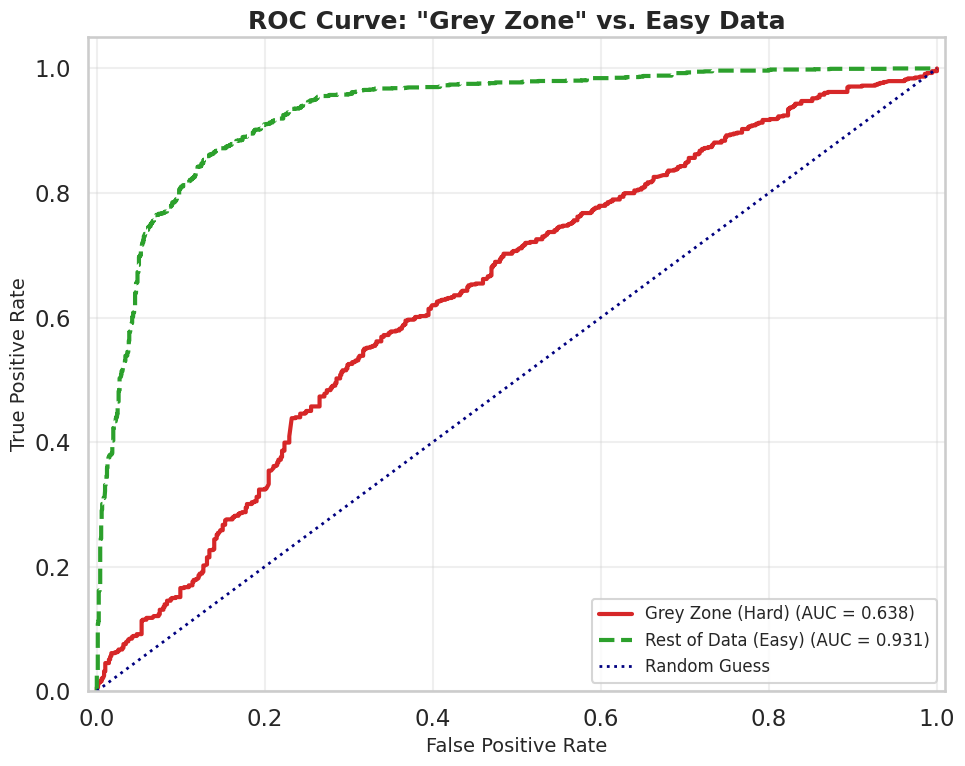

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

# --- 1. CONFIGURATION ---
LOWER_BOUND = 0.5
UPPER_BOUND = 0.8

# Ensure data is loaded
# df_test_final = pd.read_feather("your_results.feather")

print(f"=== ROC ANALYSIS: GREY ZONE ({LOWER_BOUND} <= Sim <= {UPPER_BOUND}) ===")

# --- 2. PREPARE SUBSETS ---
mask_grey = (df_test_final['cosine_similarity'] >= LOWER_BOUND) & \
            (df_test_final['cosine_similarity'] <= UPPER_BOUND)

df_grey = df_test_final[mask_grey]
df_easy = df_test_final[~mask_grey]

# --- 3. CALCULATE ROC ---
def get_roc_data(df, name):
    if len(df['label'].unique()) < 2:
        print(f"Skipping {name}: Only one class present.")
        return None
    
    fpr, tpr, _ = roc_curve(df['label'], df['prob_similarity'])
    auc_val = roc_auc_score(df['label'], df['prob_similarity'])
    return {"name": name, "fpr": fpr, "tpr": tpr, "auc": auc_val}

roc_grey = get_roc_data(df_grey, "Grey Zone (Hard)")
roc_easy = get_roc_data(df_easy, "Rest of Data (Easy)")

# --- 4. PLOT ---
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Plot Grey Zone
if roc_grey:
    plt.plot(roc_grey['fpr'], roc_grey['tpr'], 
             color='#d62728', lw=3, 
             label=f"{roc_grey['name']} (AUC = {roc_grey['auc']:.3f})")

# Plot Easy Zone
if roc_easy:
    plt.plot(roc_easy['fpr'], roc_easy['tpr'], 
             color='#2ca02c', lw=3, linestyle='--',
             label=f"{roc_easy['name']} (AUC = {roc_easy['auc']:.3f})")

# Reference Line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle=':', label='Random Guess')

plt.xlim([-0.01, 1.01])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve: "Grey Zone" vs. Easy Data', fontsize=18, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualize how experimental parameter variance affects cosine similarity

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [61]:
# --- CONFIGURATION ---
# Paths (Update these!)
PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
SPEC_META_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl"

# --- 1. LOAD & MERGE DATA ---
print("Loading Data...")
df_pairs = pd.read_feather(PAIRS_PATH)
df_spec = pd.read_pickle(SPEC_META_PATH)

print(f"Pairs: {len(df_pairs)}")
print(f"Spectra: {len(df_spec)}")

Loading Data...
Pairs: 4858
Spectra: 260706


In [62]:
# Helper: Merge metadata for Side A only (since Side B is identical)
def enrich_shared_metadata(pairs, specs):
    meta_cols = ['spec_id', 'nce', 'inst_type', 'prec_type']
    specs_lite = specs[meta_cols].copy()
    
    # We assume A and B have same metadata, so we just grab A's metadata
    # to represent the pair.
    merged = pairs.merge(specs_lite, left_on='name_main', right_on='spec_id', how='left')
    merged = merged.rename(columns={'nce': 'shared_nce', 'inst_type': 'shared_inst', 'prec_type': 'shared_adduct'})
    return merged.drop(columns=['spec_id'])

In [63]:
df = enrich_shared_metadata(df_pairs, df_spec)

In [64]:
df.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,shared_nce,shared_inst,shared_adduct
0,MassSpecGymID0003031,MassSpecGymID0049401,0.432432,0.706041,1.0,40.382348,QTOF,[M+H]+
1,MassSpecGymID0223776,MassSpecGymID0237961,0.175676,0.648690,0.0,56.170509,FT,[M+H]+
2,MassSpecGymID0224062,MassSpecGymID0234208,0.089109,0.122628,0.0,72.778112,FT,[M+H]+
3,MassSpecGymID0003081,MassSpecGymID0060725,0.439024,0.773729,1.0,123.908231,QTOF,[M+H]+
4,MassSpecGymID0148794,MassSpecGymID0159098,0.403846,0.449861,0.0,81.593621,QTOF,[M+H]+


In [65]:
# --- 2. VERIFY THE CONSTRAINT (Sanity Check) ---
print("Verifying 'Identical Parameters' Constraint...")
# We merge Side B just to check, then drop it
B_check = df_pairs[['name_sub']].merge(df_spec[['spec_id', 'inst_type']], left_on='name_sub', right_on='spec_id', how='left')
mismatches = (df['shared_inst'] != B_check['inst_type']).sum()
if mismatches == 0:
    print("✅ SUCCESS: All pairs share the same Instrument type.")
else:
    print(f"⚠️ WARNING: Found {mismatches} pairs with mismatched instruments!")

Verifying 'Identical Parameters' Constraint...
✅ SUCCESS: All pairs share the same Instrument type.


In [66]:
# --- 3. CLEANING ---
def clean_nce(val):
    try:
        if pd.isna(val): return np.nan
        val = str(val).replace('%', '')
        return float(val)
    except: return np.nan

df['nce_clean'] = df['shared_nce'].apply(clean_nce)

In [67]:
df.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,shared_nce,shared_inst,shared_adduct,nce_clean
0,MassSpecGymID0003031,MassSpecGymID0049401,0.432432,0.706041,1.0,40.382348,QTOF,[M+H]+,40.382348
1,MassSpecGymID0223776,MassSpecGymID0237961,0.175676,0.648690,0.0,56.170509,FT,[M+H]+,56.170509
2,MassSpecGymID0224062,MassSpecGymID0234208,0.089109,0.122628,0.0,72.778112,FT,[M+H]+,72.778112
3,MassSpecGymID0003081,MassSpecGymID0060725,0.439024,0.773729,1.0,123.908231,QTOF,[M+H]+,123.908231
4,MassSpecGymID0148794,MassSpecGymID0159098,0.403846,0.449861,0.0,81.593621,QTOF,[M+H]+,81.593621


In [68]:
# Bin NCE for clearer plotting
# <15 (Low), 15-30 (Med), 30-45 (High), >45 (Very High)
df['nce_bin'] = pd.cut(df['nce_clean'], bins=[0, 15, 30, 45, 200], labels=["Low (<15)", "Med (15-30)", "High (30-45)", "Extreme (>45)"])

# Clean Instruments (Top 5)
top_inst = df['shared_inst'].value_counts().nlargest(5).index
df['inst_clean'] = df['shared_inst'].apply(lambda x: x if x in top_inst else "Other")

# Clean Adducts (Top 6)
top_adducts = ["[M+H]+", "[M+Na]+", "[M-H]-", "[M+NH4]+", "[M+K]+", "[M+H-H2O]+"]
df['adduct_clean'] = df['shared_adduct'].apply(lambda x: x if x in top_adducts else "Other")

In [69]:
df.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,shared_nce,shared_inst,shared_adduct,nce_clean,nce_bin,inst_clean,adduct_clean
0,MassSpecGymID0003031,MassSpecGymID0049401,0.432432,0.706041,1.0,40.382348,QTOF,[M+H]+,40.382348,High (30-45),QTOF,[M+H]+
1,MassSpecGymID0223776,MassSpecGymID0237961,0.175676,0.648690,0.0,56.170509,FT,[M+H]+,56.170509,Extreme (>45),FT,[M+H]+
2,MassSpecGymID0224062,MassSpecGymID0234208,0.089109,0.122628,0.0,72.778112,FT,[M+H]+,72.778112,Extreme (>45),FT,[M+H]+
3,MassSpecGymID0003081,MassSpecGymID0060725,0.439024,0.773729,1.0,123.908231,QTOF,[M+H]+,123.908231,Extreme (>45),QTOF,[M+H]+
4,MassSpecGymID0148794,MassSpecGymID0159098,0.403846,0.449861,0.0,81.593621,QTOF,[M+H]+,81.593621,Extreme (>45),QTOF,[M+H]+



--- Visualizing Collision Energy Bias ---


/tmp/ipykernel_180067/1660538857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='nce_bin', y='cosine_similarity', data=df, palette="viridis", inner="quartile")


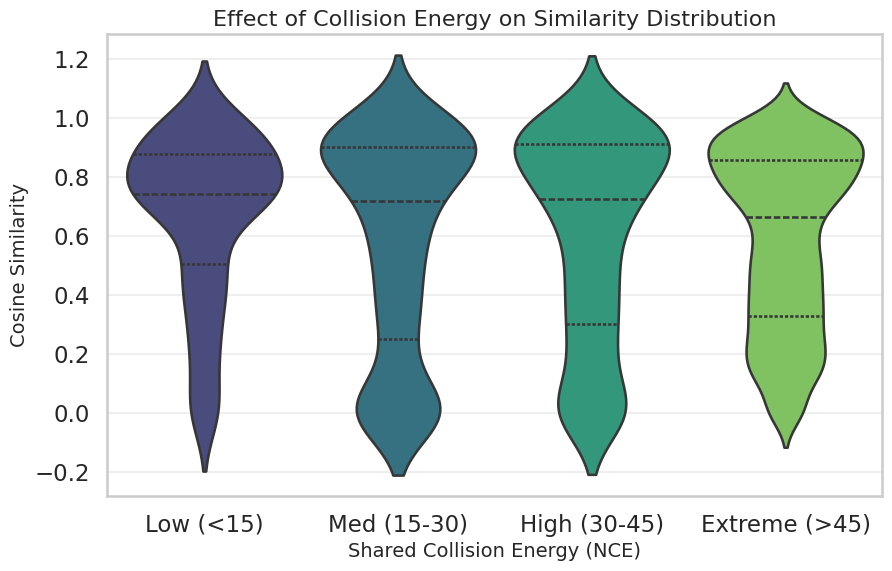

INTERPRETATION:
- If 'Extreme' NCE has a wider/lower bulge, high energy fragmentation is creating noise.
- Your model might need to learn to 'trust' High NCE matches less.


In [70]:
# --- 4. PLOT 1: Does High Energy Destroy Similarity? ---
print("\n--- Visualizing Collision Energy Bias ---")
plt.figure(figsize=(10, 6))
sns.violinplot(x='nce_bin', y='cosine_similarity', data=df, palette="viridis", inner="quartile")
plt.title("Effect of Collision Energy on Similarity Distribution", fontsize=16)
plt.xlabel("Shared Collision Energy (NCE)", fontsize=14)
plt.ylabel("Cosine Similarity", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("INTERPRETATION:")
print("- If 'Extreme' NCE has a wider/lower bulge, high energy fragmentation is creating noise.")
print("- Your model might need to learn to 'trust' High NCE matches less.")


--- Visualizing Instrument Bias ---


/tmp/ipykernel_180067/3983341136.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='inst_clean', y='cosine_similarity', data=df, order=order, palette="coolwarm")


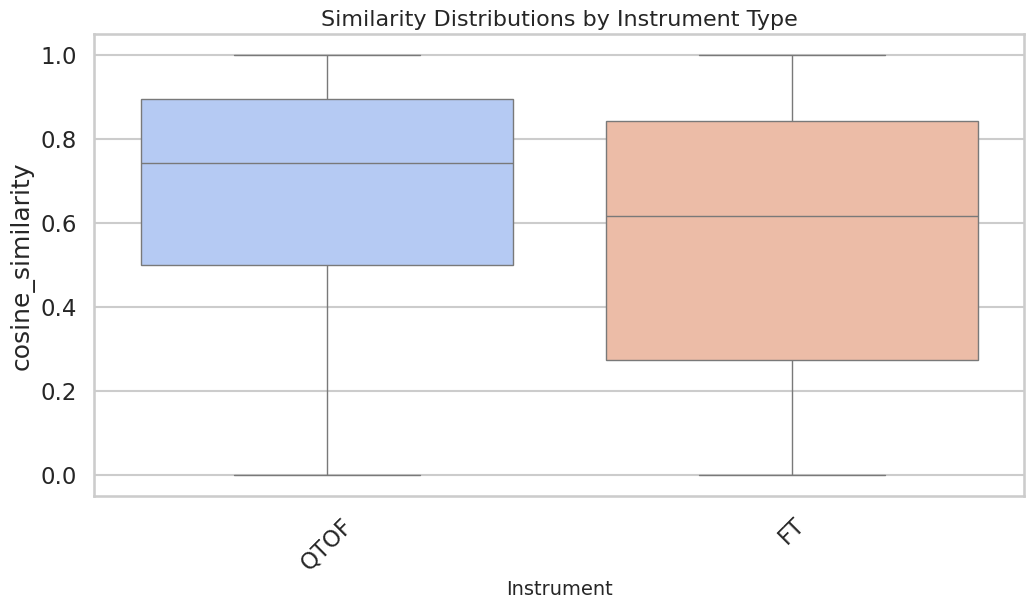

INTERPRETATION:
- Instruments like 'Orbitrap' often produce cleaner spectra (higher median similarity).
- 'Ion Traps' might be lower resolution/noisier. The model uses the metadata vector to adjust for this resolution difference.


In [71]:
# --- 5. PLOT 2: Are Some Instruments "Better" at Matching? ---
print("\n--- Visualizing Instrument Bias ---")
plt.figure(figsize=(12, 6))
order = df.groupby('inst_clean')['cosine_similarity'].median().sort_values(ascending=False).index
sns.boxplot(x='inst_clean', y='cosine_similarity', data=df, order=order, palette="coolwarm")
plt.title("Similarity Distributions by Instrument Type", fontsize=16)
plt.xlabel("Instrument", fontsize=14)
plt.xticks(rotation=45)
plt.show()

print("INTERPRETATION:")
print("- Instruments like 'Orbitrap' often produce cleaner spectra (higher median similarity).")
print("- 'Ion Traps' might be lower resolution/noisier. The model uses the metadata vector to adjust for this resolution difference.")


--- Visualizing Adduct Bias ---


/tmp/ipykernel_4065174/3309957442.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='adduct_clean', y='cosine_similarity', data=df, order=order, palette="magma")


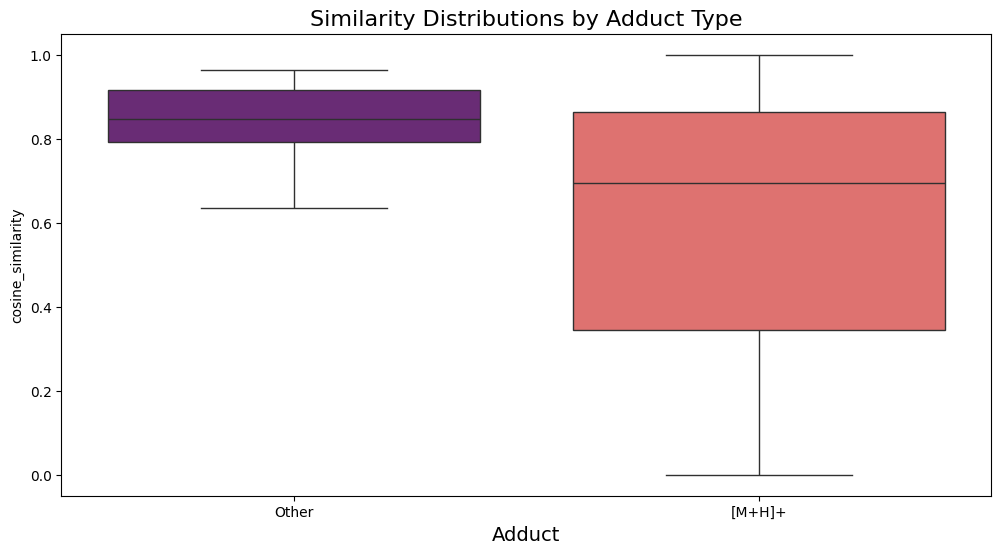

INTERPRETATION:
- Look at [M+Na]+ vs [M+H]+.
- Sodium adducts often fragment poorly, leading to sparse spectra and lower cosine scores.
- If [M+Na]+ is significantly lower, the model MUST see 'Adduct Type' in the metadata to normalize its score.


In [37]:
# --- 6. PLOT 3: The "Sodium Effect" (Adducts) ---
print("\n--- Visualizing Adduct Bias ---")
plt.figure(figsize=(12, 6))
order = df.groupby('adduct_clean')['cosine_similarity'].median().sort_values(ascending=False).index
sns.boxplot(x='adduct_clean', y='cosine_similarity', data=df, order=order, palette="magma")
plt.title("Similarity Distributions by Adduct Type", fontsize=16)
plt.xlabel("Adduct", fontsize=14)
plt.show()

print("INTERPRETATION:")
print("- Look at [M+Na]+ vs [M+H]+.")
print("- Sodium adducts often fragment poorly, leading to sparse spectra and lower cosine scores.")
print("- If [M+Na]+ is significantly lower, the model MUST see 'Adduct Type' in the metadata to normalize its score.")

In [39]:
# We need MOL_IDs to identify "Same Pair"
# (Since spec_ids change with experimental conditions)
print("Linking Spec IDs to Mol IDs...")
spec2mol = dict(zip(df_spec['spec_id'], df_spec['mol_id']))
spec2nce = dict(zip(df_spec['spec_id'], df_spec['nce']))
spec2inst = dict(zip(df_spec['spec_id'], df_spec['inst_type']))
spec2adduct = dict(zip(df_spec['spec_id'], df_spec['prec_type']))

Linking Spec IDs to Mol IDs...


In [40]:
df_pairs['mol_a'] = df_pairs['name_main'].map(spec2mol)
df_pairs['mol_b'] = df_pairs['name_sub'].map(spec2mol)

In [41]:
# Create a unique signature for the CHEMISTRY
df_pairs['pair_signature'] = df_pairs.apply(lambda x: tuple(sorted((x['mol_a'], x['mol_b']))), axis=1)

In [42]:
# Add the METADATA (Physics)
# Assuming identical params for A and B, we grab A's params
def clean_nce(val):
    try: return float(str(val).replace('%', ''))
    except: return np.nan

df_pairs['nce'] = df_pairs['name_main'].map(spec2nce).apply(clean_nce)
df_pairs['adduct'] = df_pairs['name_main'].map(spec2adduct)

Scanning for pairs with multiple experimental conditions...
Total Unique Molecule Pairs: 2664
Pairs with Multiple Conditions: 498

--- Plotting NCE Stability for Top Case Studies ---


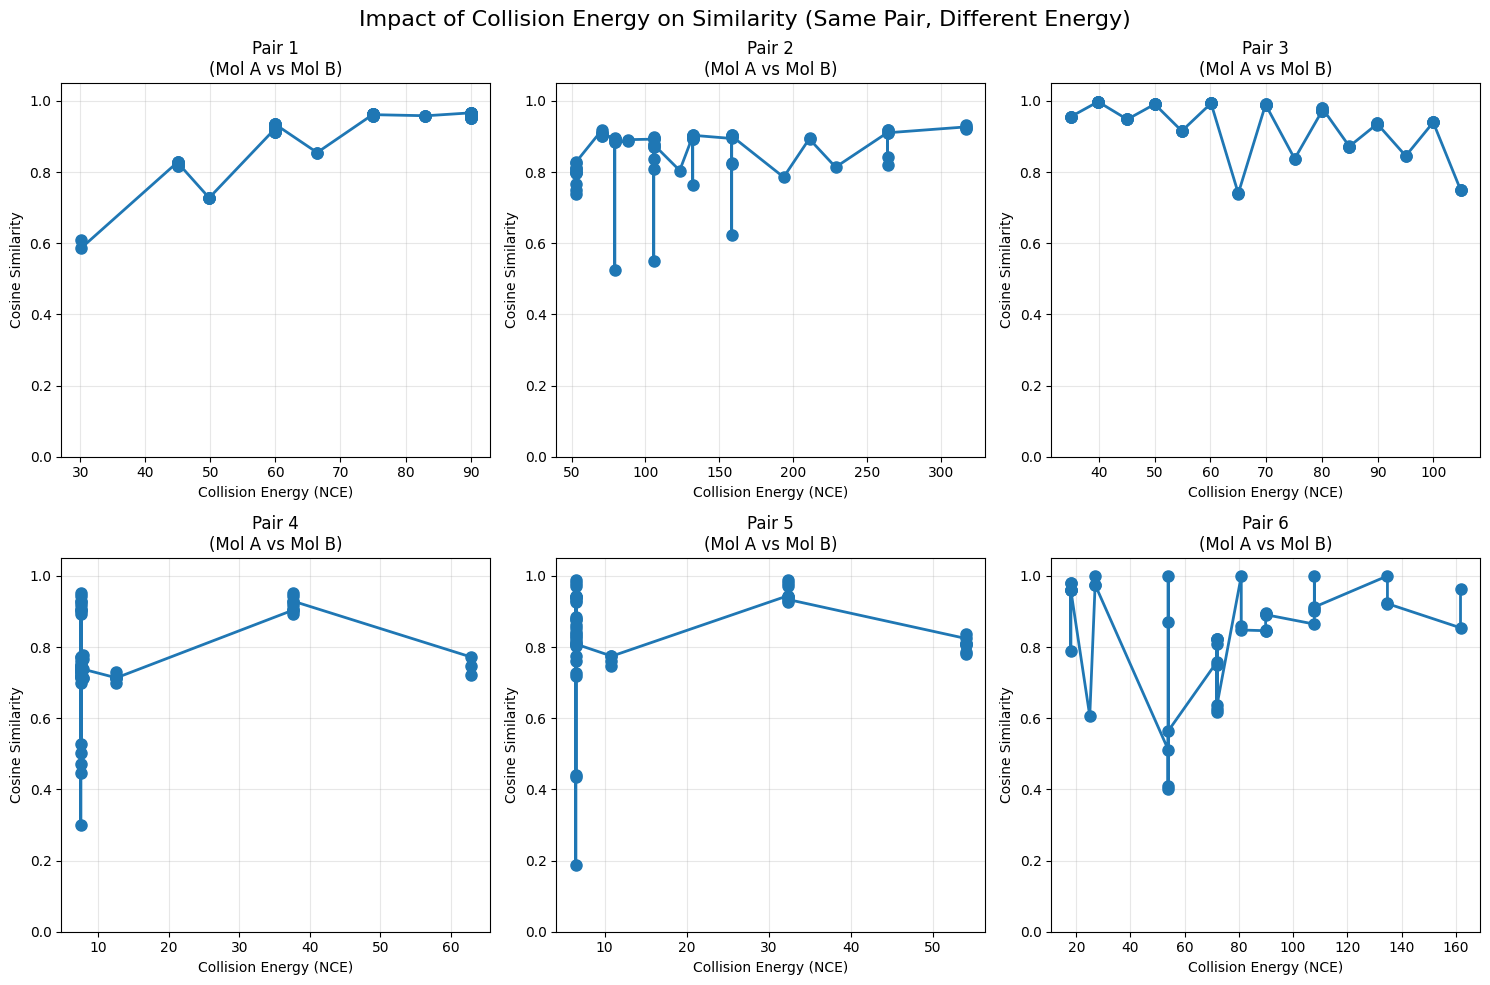

INTERPRETATION:
- Flat Line: The pair is 'Energy Invariant' (Good/Robust).
- Downward Slope: High energy destroys the spectral features (Common).
- jagged/Random: The matching is unstable/noisy.


In [45]:
# --- 2. FIND "MULTI-CONDITION" PAIRS ---
print("Scanning for pairs with multiple experimental conditions...")
pair_counts = df_pairs['pair_signature'].value_counts()
multi_condition_pairs = pair_counts[pair_counts > 1]

print(f"Total Unique Molecule Pairs: {len(pair_counts)}")
print(f"Pairs with Multiple Conditions: {len(multi_condition_pairs)}")

if len(multi_condition_pairs) == 0:
    print("\n⚠️ STOP: Your dataset appears to be de-duplicated (only 1 row per molecule pair).")
    print("This analysis requires a dataset where the same molecule pair appears multiple times with different NCEs/Instruments.")
else:
    # --- 3. VISUALIZATION: NCE STABILITY ---
    print("\n--- Plotting NCE Stability for Top Case Studies ---")
    
    # Select top 6 pairs that have the most variations in NCE
    # We want pairs that vary in NCE, not just duplicates of NCE 30
    candidates = []
    for sig in multi_condition_pairs.index:
        subset = df_pairs[df_pairs['pair_signature'] == sig]
        unique_nces = subset['nce'].nunique()
        if unique_nces >= 3: # At least 3 different energy levels
            candidates.append(sig)
        if len(candidates) >= 6: break
    
    if len(candidates) > 0:
        plt.figure(figsize=(15, 10))
        
        for i, sig in enumerate(candidates):
            subset = df_pairs[df_pairs['pair_signature'] == sig].sort_values('nce')
            
            plt.subplot(2, 3, i+1)
            plt.plot(subset['nce'], subset['cosine_similarity'], marker='o', linestyle='-', linewidth=2, markersize=8)
            
            # Aesthetics
            plt.title(f"Pair {i+1}\n(Mol A vs Mol B)", fontsize=12)
            plt.xlabel("Collision Energy (NCE)")
            plt.ylabel("Cosine Similarity")
            plt.ylim(0, 1.05)
            plt.grid(True, alpha=0.3)
            
        plt.suptitle(f"Impact of Collision Energy on Similarity (Same Pair, Different Energy)", fontsize=16)
        plt.tight_layout()
        plt.show()
        
        print("INTERPRETATION:")
        print("- Flat Line: The pair is 'Energy Invariant' (Good/Robust).")
        print("- Downward Slope: High energy destroys the spectral features (Common).")
        print("- jagged/Random: The matching is unstable/noisy.")
    else:
        print("Found multi-condition pairs, but none had >= 3 distinct NCE values to plot a trend.")


--- Adduct Impact Analysis ---


/tmp/ipykernel_4065174/4158581889.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='adduct', y='cosine_similarity', data=big_df, palette="Set2")


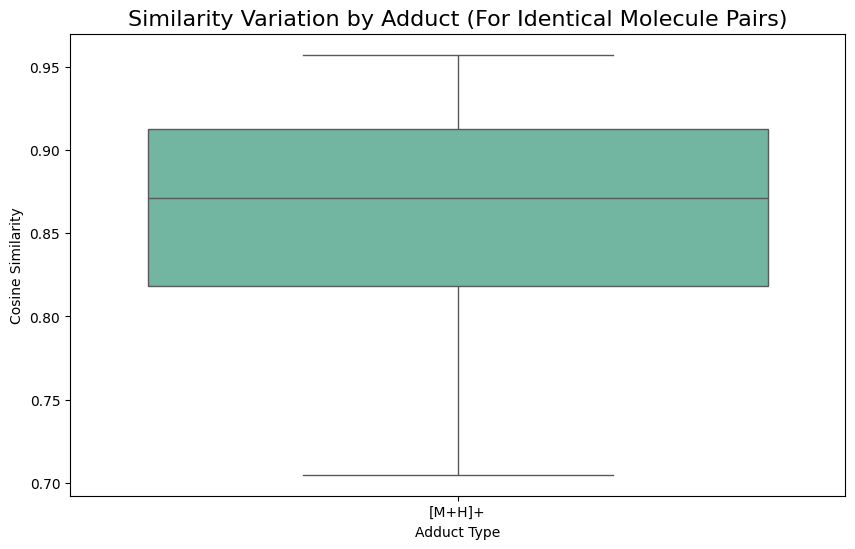

INTERPRETATION:
- This plot isolates the 'Adduct Penalty'.
- If [M+Na]+ is lower than [M+H]+ here, it proves Sodium adducts are inherently harder to match, even for the same molecules.


In [46]:
# --- 4. VISUALIZATION: ADDUCT VARIANCE ---
# Does changing the adduct change the similarity?
print("\n--- Adduct Impact Analysis ---")

# Filter for pairs that have at least 2 different adducts
adduct_candidates = []
for sig in multi_condition_pairs.index:
    subset = df_pairs[df_pairs['pair_signature'] == sig]
    if subset['adduct'].nunique() >= 2:
        adduct_candidates.append(subset)

if len(adduct_candidates) > 0:
    big_df = pd.concat(adduct_candidates)
    
    # Keep only common adducts for clean plotting
    common_adducts = ["[M+H]+", "[M+Na]+", "[M-H]-", "[M+NH4]+"]
    big_df = big_df[big_df['adduct'].isin(common_adducts)]
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='adduct', y='cosine_similarity', data=big_df, palette="Set2")
    plt.title("Similarity Variation by Adduct (For Identical Molecule Pairs)", fontsize=16)
    plt.xlabel("Adduct Type")
    plt.ylabel("Cosine Similarity")
    plt.show()
    
    print("INTERPRETATION:")
    print("- This plot isolates the 'Adduct Penalty'.")
    print("- If [M+Na]+ is lower than [M+H]+ here, it proves Sodium adducts are inherently harder to match, even for the same molecules.")

## Effects of metadata on higher and lower ends of the cosine similarity spectrum

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
PAIRS_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/data_splits/stratified_binary_07_dataset_test.feather"
SPEC_META_PATH = "/data/nas-gpu/wang/tmach007/SpectralSimilarityPredictor/mass_spec_gym_data/spec_df_spec_sim.pkl"

# --- 1. LOAD & PREPARE ---
print("Loading Data...")
df_pairs = pd.read_feather(PAIRS_PATH)
df_spec = pd.read_pickle(SPEC_META_PATH)

Loading Data...


In [50]:
print("Enriching with Shared Metadata...")
# Helper to merge metadata (Assuming shared experimental parameters for A and B)
meta_cols = ['spec_id', 'nce', 'prec_type']
specs_lite = df_spec[meta_cols].copy()
df = df_pairs.merge(specs_lite, left_on='name_main', right_on='spec_id', how='left')
df = df.rename(columns={'nce': 'shared_nce', 'prec_type': 'shared_adduct'})

Enriching with Shared Metadata...


In [51]:
df.head()

,name_main,name_sub,tanimoto,cosine_similarity,label,spec_id,shared_nce,shared_adduct
0,MassSpecGymID0003031,MassSpecGymID0049401,0.432432,0.706041,1.0,MassSpecGymID0003031,40.382348,[M+H]+
1,MassSpecGymID0223776,MassSpecGymID0237961,0.175676,0.648690,0.0,MassSpecGymID0223776,56.170509,[M+H]+
2,MassSpecGymID0224062,MassSpecGymID0234208,0.089109,0.122628,0.0,MassSpecGymID0224062,72.778112,[M+H]+
3,MassSpecGymID0003081,MassSpecGymID0060725,0.439024,0.773729,1.0,MassSpecGymID0003081,123.908231,[M+H]+
4,MassSpecGymID0148794,MassSpecGymID0159098,0.403846,0.449861,0.0,MassSpecGymID0148794,81.593621,[M+H]+


In [52]:
# --- 2. CLEANING ---
def clean_nce(val):
    try: return float(str(val).replace('%', ''))
    except: return np.nan

df['nce'] = df['shared_nce'].apply(clean_nce)
# Filter out outliers/NaN
df = df[(df['nce'] > 0) & (df['nce'] < 100)].copy()

In [53]:
# Label Formatting for Plotting
df['Pair Type'] = df['label'].map({0: 'Non-Match (Noise)', 1: 'True Match (Signal)'})


--- Generating NCE Trend Analysis ---


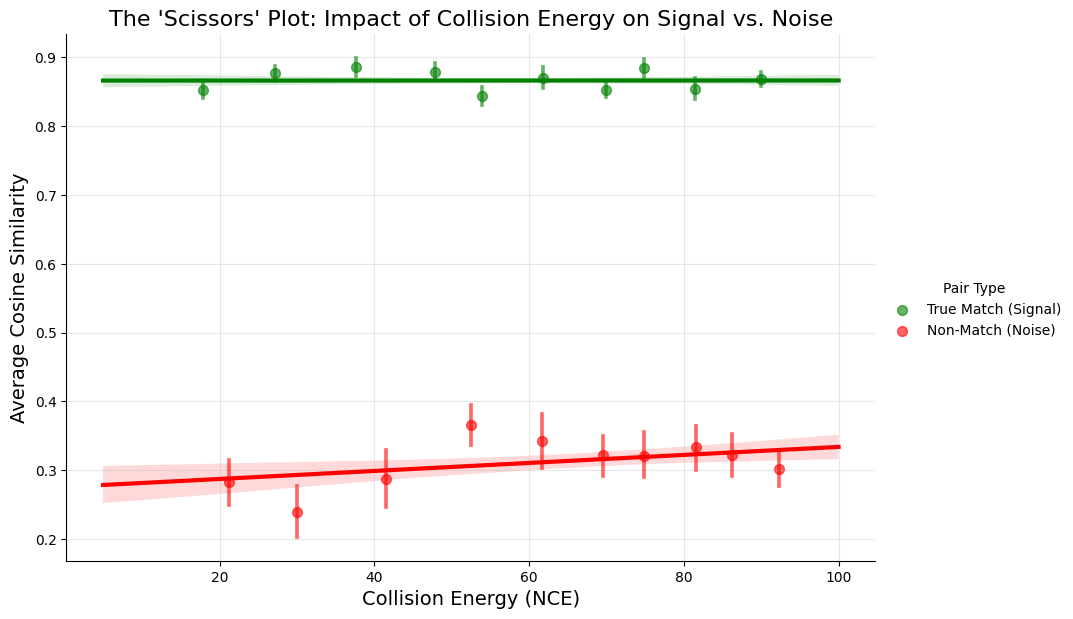

INTERPRETATION (Scissors Plot):
1. Look at the GREEN line (High End). If it slopes DOWN, high energy destroys signal.
2. Look at the RED line (Low End). If it stays FLAT or goes UP, high energy creates confusion.
   - If Green drops and Red rises, the 'Scissors' close -> Model becomes blind.


In [55]:
# --- 3. PLOT A: THE "SCISSORS" PLOT (Trend Analysis) ---
print("\n--- Generating NCE Trend Analysis ---")
# This plot calculates the Mean Similarity across NCE bins for both Signal and Noise
# We use x_bins=10 to group the NCE values into 10 buckets for cleaner trends

sns.lmplot(
    data=df, 
    x="nce", 
    y="cosine_similarity", 
    hue="Pair Type",
    palette={"Non-Match (Noise)": "red", "True Match (Signal)": "green"},
    x_bins=10,  # Bins the x-axis to calculate mean/CI
    height=6, 
    aspect=1.5,
    line_kws={'linewidth': 3},
    scatter_kws={'s': 50, 'alpha': 0.6}
)

plt.title("The 'Scissors' Plot: Impact of Collision Energy on Signal vs. Noise", fontsize=16)
plt.xlabel("Collision Energy (NCE)", fontsize=14)
plt.ylabel("Average Cosine Similarity", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("INTERPRETATION (Scissors Plot):")
print("1. Look at the GREEN line (High End). If it slopes DOWN, high energy destroys signal.")
print("2. Look at the RED line (Low End). If it stays FLAT or goes UP, high energy creates confusion.")
print("   - If Green drops and Red rises, the 'Scissors' close -> Model becomes blind.")


--- Generating Distribution Shift Analysis ---


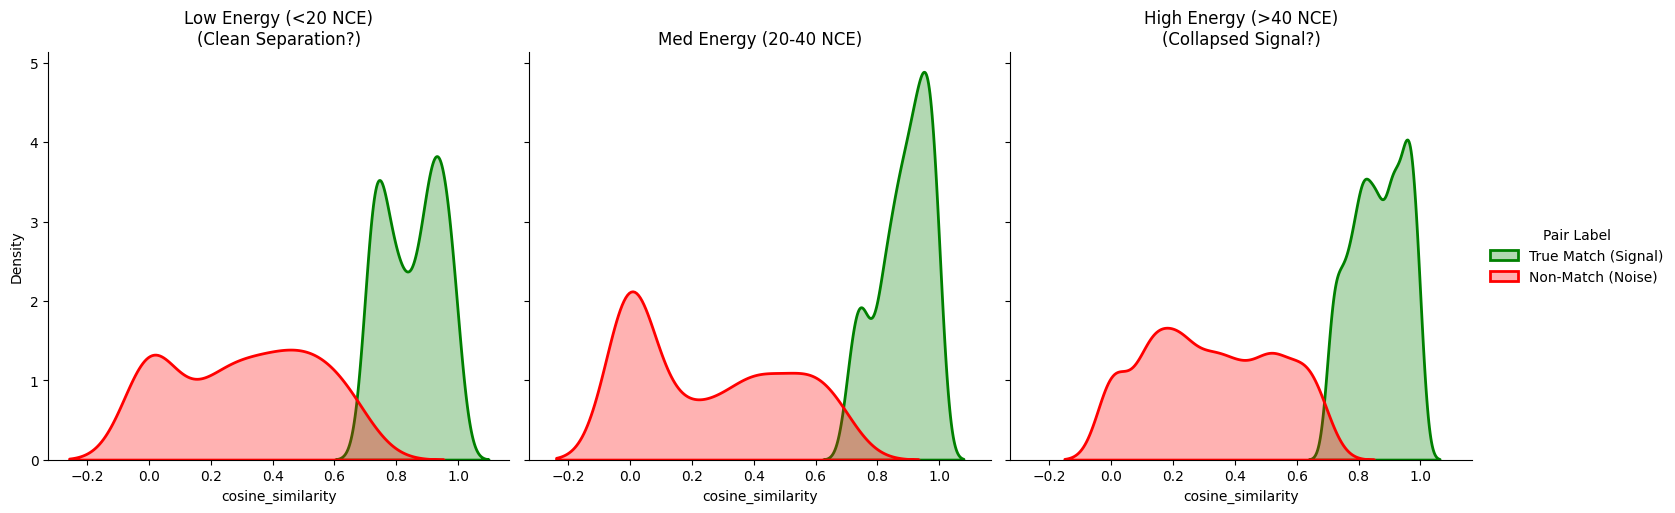

INTERPRETATION (Shift Plot):
- Watch the GREEN peak (Signal). Does it shift Left (towards 0) as energy increases?
- Watch the RED peak (Noise). Does it shift Right (towards 1) or spread out?


In [56]:
# --- 4. PLOT B: THE "SHIFT" PLOT (Distribution Shape) ---
print("\n--- Generating Distribution Shift Analysis ---")

# Define NCE Regimes
df['Energy Regime'] = pd.cut(df['nce'], bins=[0, 20, 40, 100], labels=["Low Energy (<20)", "Med Energy (20-40)", "High Energy (>40)"])

g = sns.FacetGrid(df, col="Energy Regime", hue="Pair Type", palette={"Non-Match (Noise)": "red", "True Match (Signal)": "green"}, height=5, aspect=1)
g.map(sns.kdeplot, "cosine_similarity", fill=True, alpha=0.3, linewidth=2)
g.add_legend(title="Pair Label")

# Add Titles manually
axes = g.axes.flatten()
axes[0].set_title("Low Energy (<20 NCE)\n(Clean Separation?)")
axes[1].set_title("Med Energy (20-40 NCE)")
axes[2].set_title("High Energy (>40 NCE)\n(Collapsed Signal?)")

plt.show()

print("INTERPRETATION (Shift Plot):")
print("- Watch the GREEN peak (Signal). Does it shift Left (towards 0) as energy increases?")
print("- Watch the RED peak (Noise). Does it shift Right (towards 1) or spread out?")


--- Generating Adduct Spectrum Analysis ---


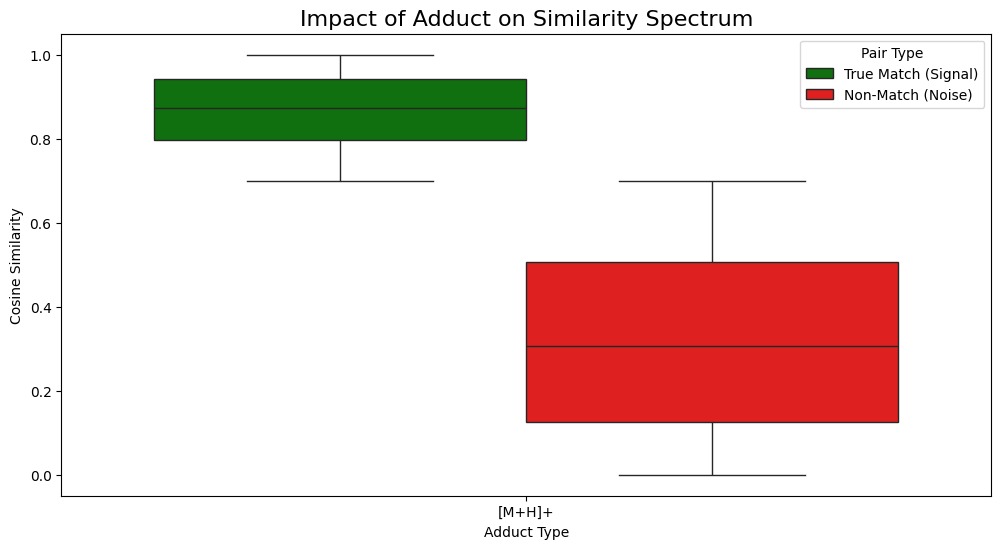

INTERPRETATION (Adduct Plot):
- Compare the gap between the Green and Red box for each Adduct.
- Smaller Gap = Harder Classification problem for that adduct.


In [57]:
# --- 5. PLOT C: ADDUCT IMPACT ON SPECTRUM ---
print("\n--- Generating Adduct Spectrum Analysis ---")
common_adducts = ["[M+H]+", "[M+Na]+", "[M-H]-"]
df_adduct = df[df['shared_adduct'].isin(common_adducts)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_adduct, 
    x="shared_adduct", 
    y="cosine_similarity", 
    hue="Pair Type",
    palette={"Non-Match (Noise)": "red", "True Match (Signal)": "green"}
)
plt.title("Impact of Adduct on Similarity Spectrum", fontsize=16)
plt.xlabel("Adduct Type")
plt.ylabel("Cosine Similarity")
plt.show()

print("INTERPRETATION (Adduct Plot):")
print("- Compare the gap between the Green and Red box for each Adduct.")
print("- Smaller Gap = Harder Classification problem for that adduct.")